## PLUTO – Analysis

Quantitative analysis of the radiative accretion disk run in `BH_VISC_RAD_HD_TRC_COMP/`: a $10^8\,M_\odot$ black hole in a
Paczyński–Wiita potential, viscous disk plus corona, grey M1 radiative transfer with Kramers, Thomson and effective Compton
opacities.

The notebook reads every `.dbl` output once, reduces each frame to radial profiles and global scalars, and caches the result in
`Analysis_cache.npz` inside the run directory. All time series analyses then work on that cache, so the frames never have to be kept
in memory at the same time. Snapshots and the steady state structure reload only the frames they need.

0. Definitions: units, model equations, characteristic scales, helpers
1. Snapshots: initial and final state of the full domain, early instabilities, evolution
2. Relaxation: when and where the disk reaches a quasi-steady state
3. Accretion: mass flux, steady disk comparison, inner boundary variability, mass budget
4. Density waves: space–time diagram, power spectra, phase speed, wave character
5. Steady state structure: luminosity, mean state, vertical structure, thermal balance
6. Resolution comparison: prepared for a second run, not called yet
7. Summary

### 0. Definitions

#### 0.1. Preamble

In [1]:
%%capture

%config InlineBackend.figure_formats = ['retina']

import os
import re
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

import pyPLUTO as pp

from matplotlib.colors import LogNorm, SymLogNorm, TwoSlopeNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable

from scipy import signal

from statsmodels.tsa.stattools import kpss, adfuller
from statsmodels.tools.sm_exceptions import InterpolationWarning
warnings.filterwarnings("ignore", category=InterpolationWarning)
warnings.filterwarnings("ignore", message=".*returns a plain tuple.*")

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=["steelblue", "olivedrab", "goldenrod", "firebrick", "rebeccapurple"])
plt.rcParams['figure.figsize'] = [8,5]
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['legend.frameon'] = False
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["ytick.minor.visible"] = True

plt.plot()
plt.close()

#### 0.2. Configuration

All tunable choices of the analysis are collected here. Times are in code units $t_g = R_g/c$.

- `W_WINDOW`: length of the sliding windows used for time averages, chosen much longer than the wave period of about $250$
- `BLOCK`: block length for error estimates, chosen longer than the correlation time of the fluctuations
- `REF_FRAC`: fraction of the run at the end that serves as the steady reference state
- `Z_CRIT`: number of standard errors within which two averages count as consistent
- `T_STEADY_OVERRIDE`: set a number to impose the start of the steady window, `None` uses the value measured in Section 2
- `PROFILE_STRIDE`: only every n-th frame of the steady window is reloaded for the structure analysis of Section 5

In [2]:
PATH = 'BH_VISC_RAD_HD_TRC_COMP/'
CACHE = os.path.join(PATH, 'Analysis_cache.npz')
FORCE_REDUCE = False                      # True recomputes the cache from all .dbl files

T_FULL = [0.0, None]                      # full domain snapshots, None means the last output
T_EARLY = [50, 100, 150, 250, 400, 600]   # early instabilities and surface layer
T_EVOLUTION = [100, 1000, 10000, None]    # evolution towards the quasi-steady state

W_WINDOW = 2500.0
BLOCK = 500.0
REF_FRAC = 0.2
Z_CRIT = 2.0
T_STEADY_OVERRIDE = None

R_WAVE = (4.0, 25.0)                      # radial range of the wave analysis
WAVE_STEP = 2                             # radial cell separation for the cross spectra
COH_MIN = 0.5                             # minimum coherence for a trusted phase speed

R_PROFILES = [8.0, 12.0, 16.0]            # cylindrical radii of the vertical structure profiles
PROFILE_STRIDE = 4

HEMI = 2.0                                # only theta in [0, pi/2] is simulated, equatorial symmetry

#### 0.3. Units and Constants

The code uses $G M = c = 1$. With $M = 10^8\,M_\odot$ the units are

$$
R_g = \frac{G M}{c^2}, \qquad v_0 = \sqrt{\frac{G M}{R_g}} = c, \qquad t_g = \frac{R_g}{c}, \qquad \rho_0 = 5.8 \times 10^{-10}\ \mathrm{g\,cm^{-3}},
$$

from which pressure and energy density, mass flux and luminosity follow as

$$
p_0 = \rho_0 c^2, \qquad \dot M_0 = \rho_0\, c\, R_g^2, \qquad L_0 = \rho_0\, c^3 R_g^2 .
$$

The gas temperature follows from the ideal gas law with the mean molecular weight of a fully ionized gas,

$$
T_g = \frac{\mu\, m_u\, c^2}{k_B}\, \frac{p}{\rho}, \qquad \mu = \left(2X + \tfrac{3}{4}Y + \tfrac{1}{2}Z\right)^{-1}, \qquad X = 0.70,\ Z = 0.02,\ Y = 1 - X - Z ,
$$

and the radiation temperature from the radiation energy density with the radiation constant in code units,

$$
T_r = \left(\frac{E_r}{a}\right)^{1/4}, \qquad a = \frac{4\sigma_\mathrm{SB}}{c}\,\frac{1}{\rho_0 c^2} .
$$

Radiation pressure is $p_r = E_r/3$ in the optically thick limit. PLUTO stores the flux $F$ in units of energy density, so the
physical flux is $c\,F$ and in code units simply $F$. The Eddington luminosity and accretion rate use the electron scattering
opacity of the model,

$$
L_\mathrm{Edd} = \frac{4\pi G M c}{\kappa_\mathrm{es}}, \qquad \kappa_\mathrm{es} = 0.2\,(1+X)\ \mathrm{cm^2\,g^{-1}}, \qquad
\dot M_\mathrm{Edd} = \frac{L_\mathrm{Edd}}{\eta\, c^2}, \qquad \eta = \frac{1}{16} ,
$$

where $\eta = 1/16$ is the binding energy at the innermost stable orbit of the Paczyński–Wiita potential.

In [3]:
CONST_G     = 6.6726e-8          # same constants as PLUTO's pluto.h
CONST_c     = 2.99792458e10
CONST_amu   = 1.66053886e-24
CONST_kB    = 1.3806505e-16
CONST_sigma = 5.67051e-5
CONST_Msun  = 1.989e33
YEAR        = 3.15576e7
DAY         = 86400.0

def read_definitions(path):
    # UNIT_DENSITY and BH mass from definitions.h, with the values of this run as fallback
    txt = open(os.path.join(path, 'definitions.h')).read()
    rho0 = re.search(r'#define\s+UNIT_DENSITY\s+([0-9.eE+-]+)', txt)
    mbh = re.search(r'#define\s+BH_MASS\s+\(\s*([0-9.eE+-]+)\s*\*\s*([0-9.eE+-]+)\s*\)', txt)
    rho0 = float(rho0.group(1)) if rho0 else 5.8e-10
    mbh = float(mbh.group(1)) * float(mbh.group(2)) if mbh else 1.0e8 * CONST_Msun
    return rho0, mbh

def read_parameters(path):
    # user parameters from the [Parameters] block of pluto.ini
    params, inside = {}, False
    for line in open(os.path.join(path, 'pluto.ini')):
        s = line.strip()
        if s.startswith('['):
            inside = (s == '[Parameters]')
            continue
        if inside and s and not s.startswith('#'):
            key, val = s.split()[:2]
            params[key] = float(val)
    return params

RHO0, M_BH = read_definitions(PATH)
PAR = read_parameters(PATH)

GAMMA = 5.0 / 3.0
X_H, Z_M = 0.70, 0.02
Y_HE = 1.0 - X_H - Z_M
MU = 1.0 / (2.0 * X_H + 0.75 * Y_HE + 0.5 * Z_M)

ALPHA = PAR['BETAV']             # the viscosity parameter is called BETAV in the code
EPS = PAR['EPS']
RHOC = PAR['RHOC']
RD = PAR['RD']
DFLOOR = PAR['DFLOOR']

R_G = CONST_G * M_BH / CONST_c**2
T_G = R_G / CONST_c
P0 = RHO0 * CONST_c**2
MDOT0 = RHO0 * CONST_c * R_G**2
L0 = RHO0 * CONST_c**3 * R_G**2

K_T = MU * CONST_amu * CONST_c**2 / CONST_kB        # Kelvin per code unit of p/rho
A_RAD = 4.0 * CONST_sigma / CONST_c / P0            # radiation constant in code units

KAPPA_ES = 0.2 * (1.0 + X_H)
ETA = 1.0 / 16.0
L_EDD = 4.0 * np.pi * CONST_G * M_BH * CONST_c / KAPPA_ES
MDOT_EDD = L_EDD / (ETA * CONST_c**2)

print(f"R_g = {R_G:.4e} cm,   t_g = {T_G:.1f} s,   rho_0 = {RHO0:.2e} g/cm^3,   p_0 = {P0:.3e} erg/cm^3")
print(f"Mdot_0 = {MDOT0:.3e} g/s = {MDOT0 * YEAR / CONST_Msun:.3e} Msun/yr,   L_0 = {L0:.3e} erg/s")
print(f"L_Edd = {L_EDD:.3e} erg/s = {L_EDD / L0:.3e} L_0,   Mdot_Edd = {MDOT_EDD * YEAR / CONST_Msun:.3f} Msun/yr = {MDOT_EDD / MDOT0:.3e} Mdot_0")
print(f"mu = {MU:.4f},   K_T = {K_T:.4e} K,   a = {A_RAD:.4e} (code)")
print(f"alpha = {ALPHA},   eps = {EPS},   rho_c = {RHOC},   R_d = {RD},   floor = {DFLOOR}")

R_g = 1.4767e+13 cm,   t_g = 492.6 s,   rho_0 = 5.80e-10 g/cm^3,   p_0 = 5.213e+11 erg/cm^3
Mdot_0 = 3.792e+27 g/s = 6.016e+01 Msun/yr,   L_0 = 3.408e+48 erg/s
L_Edd = 1.471e+46 erg/s = 4.315e-03 L_0,   Mdot_Edd = 4.154 Msun/yr = 6.905e-02 Mdot_0
mu = 0.6173,   K_T = 6.6725e+12 K,   a = 1.4514e-26 (code)
alpha = 0.5,   eps = 0.1,   rho_c = 0.01,   R_d = 6.0,   floor = 5e-07


#### 0.4. Model Equations

These are the equations implemented in `init.c`, `visc_nu.c` and `pluto.ini`, written in code units with spherical $(r,\theta)$,
cylindrical radius $R = r\sin\theta$ and height $z = r\cos\theta$. The simulation is axisymmetric and covers only the upper
hemisphere $\theta \in [0, \pi/2]$.

**Gravity.** The Paczyński–Wiita potential mimics the innermost stable circular orbit of a Schwarzschild black hole,

$$
\Phi(r) = -\frac{1}{r - 2} .
$$

Circular orbits in the midplane have angular velocity, specific angular momentum and epicyclic frequency

$$
\Omega^2 = \frac{1}{R}\frac{\mathrm{d}\Phi}{\mathrm{d}R} = \frac{1}{R\,(R-2)^2}, \qquad
\ell = R^2\,\Omega, \qquad
\kappa^2 = \frac{1}{R^3}\frac{\mathrm{d}\left(R^4\Omega^2\right)}{\mathrm{d}R} = \Omega^2\,\frac{R - 6}{R - 2},
$$

so the innermost stable orbit, where $\kappa^2 = 0$, sits at $R_\mathrm{isco} = 6$. The Newtonian Keplerian angular velocity
$\Omega_N = R^{-3/2}$ is still used by the initial disk and by the rotation criterion of DiskFraction.

**Corona.** A static adiabatic atmosphere in hydrostatic equilibrium with the Newtonian potential $-1/r$ and $\gamma = 5/3$,

$$
\rho_c(r) = \rho_{c,0}\, r^{-3/2}, \qquad p_c(r) = \frac{2}{5}\,\rho_{c,0}\, r^{-5/2}, \qquad \frac{p_c}{\rho_c} = \frac{\gamma-1}{\gamma}\,\frac{1}{r} .
$$

**Disk.** The Kluźniak & Kita polytropic disk with aspect ratio $\epsilon = H/R$ follows from

$$
C(r,\theta) = \frac{2}{5\epsilon^2}\left[\frac{1}{r} - \left(1 - \frac{5}{2}\epsilon^2\right)\frac{1}{R}\right], \qquad
\rho_d = C^{3/2}, \qquad p_d = \epsilon^2\, C^{5/2},
$$

and occupies all cells with $p_d \geq p_c$ and $R > R_d$. Its velocities include the viscous inflow of the $\alpha$-disk,

$$
v_\phi = \frac{1}{\sqrt{R}}\left[\sqrt{1 - \frac{5}{2}\epsilon^2} + \frac{2}{3}\epsilon^2\alpha^2\lambda\left(1 - \frac{6}{5\,\epsilon^2\tan^2\theta}\right)\right], \qquad
v_r = -\frac{\alpha\,\epsilon^2}{\sin\theta\,\sqrt{R}}\left[10 - \frac{32}{3}\lambda\alpha^2 - \lambda\left(5 - \frac{1}{\epsilon^2\tan^2\theta}\right)\right],
$$

with $\lambda = \dfrac{11}{5}\left(1 + \dfrac{64}{25}\alpha^2\right)^{-1}$ and $v_\theta = 0$. In the corona all velocities vanish.

**Radiation at $t = 0$.** The analytic disk pressure is shared between gas and radiation at a common temperature $T$, the root of

$$
\frac{\rho\,T}{K_T} + \frac{a\,T^4}{3} = p_d, \qquad p_\mathrm{gas} = \frac{\rho\,T}{K_T}, \qquad E_r = a\,T^4, \qquad \boldsymbol{F} = 0,
$$

with $K_T = \mu m_u c^2/k_B$. The corona starts with the minimum radiation energy $E_r = 10^{-16}$.

**Viscosity.** Only the shear viscosity of an $\alpha$-prescription with the *initial* analytic sound speed acts,

$$
\nu_1 = \frac{2}{3}\,\rho\,\alpha\, c_{s,0}^2\, R^{3/2}\, f, \qquad c_{s,0}^2 = \epsilon^2 \max(C, 0), \qquad \nu_2 = 0,
$$

where $f$ is the DiskFraction. In the midplane $C = 1/R$, so the kinematic viscosity is

$$
\nu(R) = \frac{\nu_1}{\rho} = \frac{2}{3}\,\alpha\,\epsilon^2\, R^{1/2} .
$$

The viscous heating rate per volume of the dominant $r\phi$ stress is $q^+ = \nu_1 \left(R\,\partial\Omega/\partial R\right)^2$.

**DiskFraction.** A continuous classifier $f \in [0,1]$ multiplies a density and a rotation criterion,

$$
f = \sigma\!\left(\frac{s - \left(1 - 1/1.2\right)}{0.3}\right)\,\sigma\!\left(\frac{|v_\phi|\sqrt{R} - 0.5}{0.1}\right), \qquad
s = \frac{\log\rho - \log\bar\rho_c(r)}{\log\bar\rho_d(r) - \log\bar\rho_c(r)}, \qquad \sigma(x) = \frac{1}{1 + e^{-x}},
$$

with reference profiles $\bar\rho_{c,d}(r)$ of the corona and the disk that are $f$-weighted volume averages in $90$ logarithmic
radial bins, smoothed in time by an exponential moving average with weight $0.05$ per update.

**Opacities.** With $\rho$ and $T$ in cgs and the gas temperature clamped to $T \geq 10^4$ K,

$$
\kappa_\mathrm{ff+bf} = \left(K_\mathrm{ff} + K_\mathrm{bf}\right) \rho\, T^{-7/2}, \qquad
K_\mathrm{ff} = 3.68 \times 10^{22}\,(1-Z)(1+X), \qquad K_\mathrm{bf} = 4.34 \times 10^{25}\, \frac{Z(1+X)}{t}, \quad t = 10 .
$$

Compton energy exchange enters as an effective absorption opacity that reproduces the nonrelativistic rate
$\rho\,\kappa_\mathrm{es} c\, E_r\, 4k_B (T_g - T_r)/(m_e c^2)$ exactly,

$$
\kappa_C = \kappa_\mathrm{es}\, \frac{4 k_B T_r^4}{m_e c^2\,(T_g + T_r)(T_g^2 + T_r^2)} \quad (T_g \leq T_\mathrm{max}), \qquad
\kappa_C = \kappa_\mathrm{es}\, \frac{4 k_B T_r^4\,(T_\mathrm{max} - T_r)}{m_e c^2\,(T_g^4 - T_r^4)} \quad (T_g > T_\mathrm{max}),
$$

with $T_\mathrm{max} = 10^9$ K. Absorption and Compton act only in the disk, Thomson scattering everywhere,

$$
\kappa_a = g_v\, f_d \left(\kappa_\mathrm{ff+bf} + \kappa_C\right), \qquad
\kappa_s = g_v \left(\kappa_\mathrm{es} - f_d\, \kappa_C\right), \qquad
f_d = \max\!\left(0, \frac{f - 0.05}{0.95}\right), \qquad
g_v = \sigma\!\left(-\frac{|\boldsymbol{v}|/c - 0.9}{0.03}\right),
$$

where $g_v$ decouples matter and radiation in the plunging region, where the gas moves faster than the nonrelativistic radiation
module can handle. Opacities are per unit mass and converted to code units with $\rho_0 R_g$.

**Boundaries.**

- Inner, $r = 2.1$: all variables copied from the first active cell, a diode $v_r \leq 0$, floors $\rho \geq \rho_\mathrm{fl}$ and
  $p \geq 10^{-3}\rho_\mathrm{fl}$, radiation $E_r$ copied and $F_r \leq 0$.
- Outer, $r = 30$: density extrapolated as $\rho_i = \rho_{i-1}\,(r_i/r_{i-1})^{a}$ with a van Leer limited, non-positive slope
  $a$, pressure adiabatic $p = p_N\,(\rho/\rho_N)^\gamma$, $v_r$ and $v_\theta$ copied, $v_\phi$ minmod extrapolated. Within
  $|\theta - \pi/2| \leq \arctan(1.25\,\epsilon)$ the analytic disk $\rho$, $v_r$, $v_\phi$ is reinjected. Within
  $|\theta - \pi/2| \geq \arctan(3\,\epsilon)$ coronal inflow is blocked, $v_r, v_\theta \to 0$ where $v_r < 0$. Radiation $E_r$
  copied and $F_r \geq 0$.
- $\theta = 0$ axisymmetric, $\theta = \pi/2$ equatorial symmetry.
- In the domain: $\rho \geq \rho_\mathrm{fl} = 5\times10^{-7}$, raising $\rho$ at fixed sound speed and momentum, and
  $T_g \geq 10^4$ K. Both floors add mass or energy, which Section 3.4 quantifies.

In [4]:
def omega_pw(R):
    return 1.0 / ((R - 2.0) * np.sqrt(R))

def omega_newton(R):
    return R**-1.5

def kappa_epi(R):
    return omega_pw(R) * np.sqrt(np.clip((R - 6.0) / (R - 2.0), 0.0, None))

def nu_kin(R):
    return 2.0 / 3.0 * ALPHA * EPS**2 * np.sqrt(R)

def cs0(R):
    return EPS / np.sqrt(R)                          # analytic midplane sound speed, c_s0^2 = eps^2 / R

def t_orbit(R):    return 2.0 * np.pi / omega_pw(R)
def t_thermal(R):  return 1.0 / (ALPHA * omega_newton(R))
def t_viscous(R):  return R**2 / nu_kin(R)
def t_sound(R):    return R / cs0(R)

def r_viscous(t):
    # radius whose viscous time equals t, inverting t_nu = 3 R^1.5 / (2 alpha eps^2)
    return (2.0 * ALPHA * EPS**2 * np.asarray(t, dtype=float) / 3.0)**(2.0 / 3.0)

#### 0.5. Characteristic Scales

For the thin disk with $H = \epsilon R$ and midplane sound speed $c_{s,0} = \epsilon\,R^{-1/2}$, the relevant timescales are

$$
t_\mathrm{orb} = \frac{2\pi}{\Omega}, \qquad
t_\mathrm{th} = \frac{1}{\alpha\,\Omega_N}, \qquad
t_\nu = \frac{R^2}{\nu} = \frac{3}{2}\,\frac{R^{3/2}}{\alpha\,\epsilon^2}, \qquad
t_{c_s} = \frac{R}{c_{s,0}}, \qquad
t_\mathrm{diff} \simeq \frac{\tau\, H}{c}, \quad \tau = \frac{\kappa\,\Sigma}{2} .
$$

The viscous time sets how far out the disk can reach inflow equilibrium within a given run time, $R_\nu(t)$ with $t_\nu(R_\nu) = t$.
The diffusion time needs the measured surface density and is evaluated in Section 5.5.

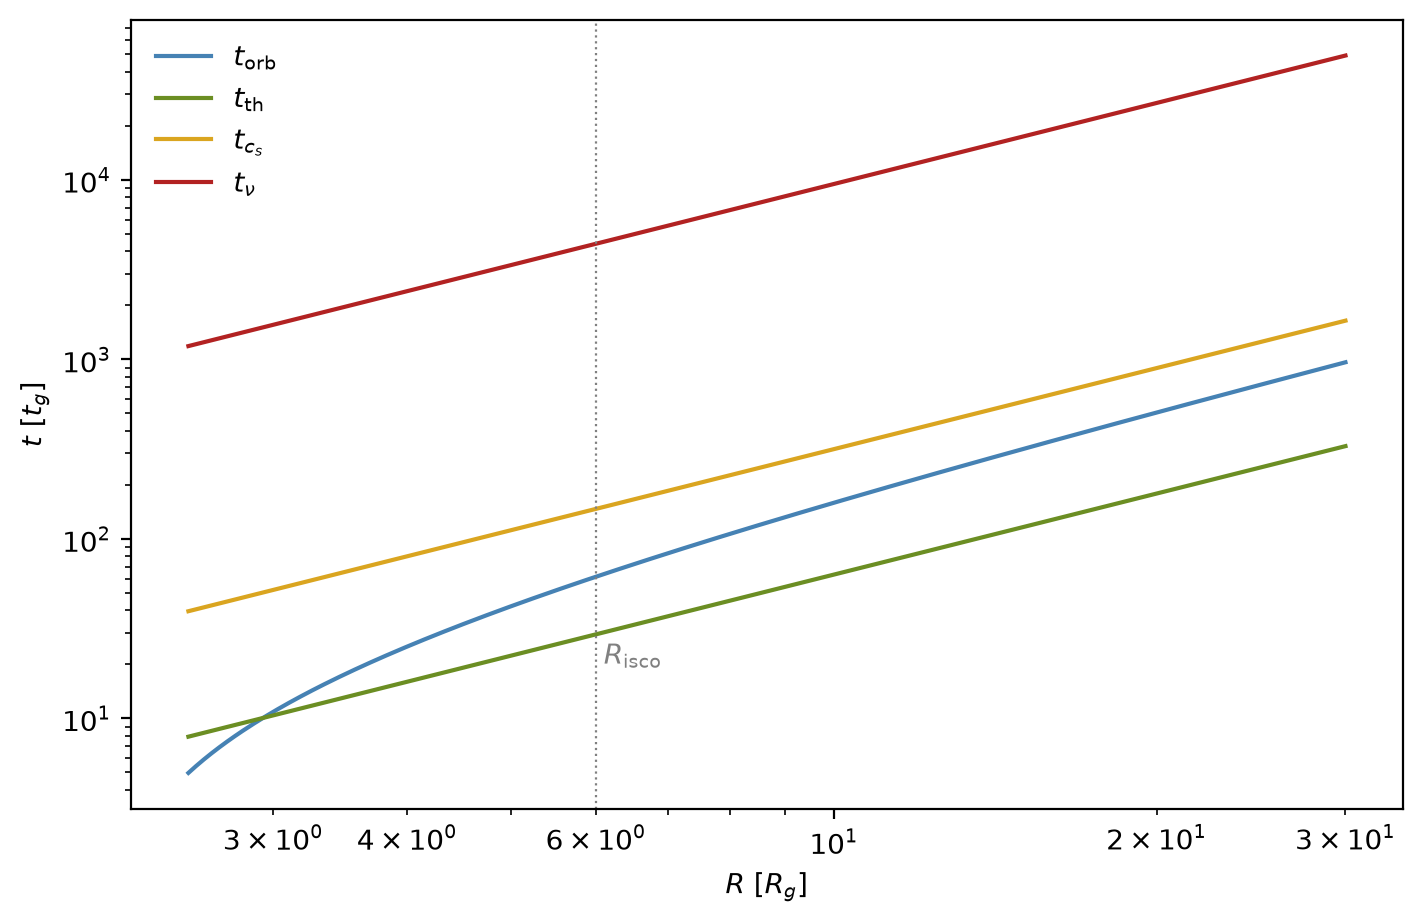

R =  6:  t_orb =     61.6   t_th =    29.4   t_cs =   147.0   t_nu =    4409.1   [t_g]
R = 10:  t_orb =    159.0   t_th =    63.2   t_cs =   316.2   t_nu =    9486.8   [t_g]
R = 15:  t_orb =    316.4   t_th =   116.2   t_cs =   580.9   t_nu =   17428.4   [t_g]
R = 20:  t_orb =    505.8   t_th =   178.9   t_cs =   894.4   t_nu =   26832.8   [t_g]
R = 30:  t_orb =    963.6   t_th =   328.6   t_cs =  1643.2   t_nu =   49295.0   [t_g]


In [5]:
R_plot = np.geomspace(2.5, 30, 300)
fig, ax = plt.subplots(figsize=[7, 4.5])
ax.plot(R_plot, t_orbit(R_plot), label=r'$t_\mathrm{orb}$')
ax.plot(R_plot, t_thermal(R_plot), label=r'$t_\mathrm{th}$')
ax.plot(R_plot, t_sound(R_plot), label=r'$t_{c_s}$')
ax.plot(R_plot, t_viscous(R_plot), label=r'$t_\nu$')
ax.axvline(6.0, color='gray', lw=0.8, ls=':')
ax.text(6.1, 2e1, r'$R_\mathrm{isco}$', color='gray')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$R\ [R_g]$'); ax.set_ylabel(r'$t\ [t_g]$')
ax.legend()
plt.show()

for R in [6, 10, 15, 20, 30]:
    print(f"R = {R:2d}:  t_orb = {t_orbit(R):8.1f}   t_th = {t_thermal(R):7.1f}   t_cs = {t_sound(R):7.1f}   t_nu = {t_viscous(R):9.1f}   [t_g]")

#### 0.6. Helpers

**Geometry.** Cell edges come from `grid.out`, so all integrals use the exact cell volumes and solid angles,

$$
\Delta\Omega_j = 2\pi\left(\cos\theta_{j-1/2} - \cos\theta_{j+1/2}\right), \qquad
\Delta V_{ij} = \frac{r_{i+1/2}^3 - r_{i-1/2}^3}{3}\,\Delta\Omega_j .
$$

**Reduction.** Every frame is reduced to radial profiles and global scalars. Sums run over the simulated hemisphere and are
multiplied by $2$ for the full sphere, $f$ is the DiskFraction:

$$
\Sigma(r) = 2\sum_j \rho_{ij}\, r_i\, \Delta\theta_j, \qquad
\dot M(r) = 2\, r^2 \sum_j \rho_{ij}\, v_{r,ij}\, \Delta\Omega_j, \qquad
\dot M_\mathrm{acc} = -\dot M ,
$$

with disk and corona parts weighted by $f$ and $1 - f$, and inflow and outflow parts split by the sign of $v_r$. $\Sigma$ is the
column along $\theta$ at fixed $r$, which equals the vertical column $\int\rho\,\mathrm{d}z$ of a thin disk. The disk aspect ratio
is the $f\rho$-weighted rms height,

$$
\frac{H}{R}(r) = \left[\frac{\sum_j f\rho\, \cot^2\theta_j\, \Delta\theta_j}{\sum_j f\rho\, \Delta\theta_j}\right]^{1/2},
$$

and the global scalars are

$$
M = 2\sum \rho\,\Delta V, \quad M_d = 2\sum f\rho\,\Delta V, \quad E_\mathrm{rad} = 2\sum E_r\,\Delta V, \quad
E_\mathrm{th} = 2\sum \frac{p}{\gamma - 1}\,\Delta V, \quad E_\mathrm{kin} = 2\sum \tfrac{1}{2}\rho v^2\,\Delta V, \quad
L(r) = 2\, r^2 \sum_j F_{r,ij}\, \Delta\Omega_j ,
$$

with $M_\mathrm{mid}$ the mass between the first and the last cell centre, the control volume of the mass budget in Section 3.4.

**Photosphere.** The optical depth from the pole along $\theta$ at fixed $r$ is $\tau(r,\theta) = \int_0^\theta \rho\,(\kappa_a +
\kappa_s)\, r\, \mathrm{d}\theta'$, and $\tau = 1$ marks the photosphere seen from above.

In [6]:
def read_grid(path):
    # cell edges of each direction from grid.out
    lines = [l for l in open(os.path.join(path, 'grid.out')) if not l.startswith('#')]
    edges, k = [], 0
    while k < len(lines) and lines[k].strip():
        n = int(lines[k].split()[0]); k += 1
        block = np.array([[float(v) for v in lines[k + m].split()[1:3]] for m in range(n)])
        edges.append(np.append(block[:, 0], block[-1, 1]))
        k += n
    return edges

def read_outputs(path):
    # output numbers and times from dbl.out
    outs, times = [], []
    for line in open(os.path.join(path, 'dbl.out')):
        s = line.split()
        if len(s) > 1:
            outs.append(int(s[0])); times.append(float(s[1]))
    return np.array(outs), np.array(times)

R_E, TH_E = read_grid(PATH)[:2]
R_C = 0.5 * (R_E[1:] + R_E[:-1])
TH_C = 0.5 * (TH_E[1:] + TH_E[:-1])
NR, NTH = R_C.size, TH_C.size
DR = np.diff(R_E)
DTH = np.diff(TH_E)
DOM = 2.0 * np.pi * (np.cos(TH_E[:-1]) - np.cos(TH_E[1:]))
DV = ((R_E[1:]**3 - R_E[:-1]**3) / 3.0)[:, None] * DOM[None, :]
COT = np.cos(TH_C) / np.sin(TH_C)
R_MID_E = np.concatenate([[R_C[0]], R_E[1:-1], [R_C[-1]]])       # shells between the first and last cell centre
DV_MID = ((R_MID_E[1:]**3 - R_MID_E[:-1]**3) / 3.0)[:, None] * DOM[None, :]

OUTS, TIMES = read_outputs(PATH)
DT_OUT = np.median(np.diff(TIMES))

print(f"grid {NR} x {NTH},  r in [{R_E[0]}, {R_E[-1]}],  theta in [{TH_E[0]:.4f}, {TH_E[-1]:.4f}]")
print(f"{OUTS.size} outputs,  t in [{TIMES[0]:.1f}, {TIMES[-1]:.1f}],  cadence {DT_OUT:.2f}")

VARS = ['rho', 'vx1', 'vx2', 'vx3', 'prs', 'enr', 'fr1', 'fr2', 'diskfrac', 'nu', 'kappa_abs', 'kappa_scat']

def load(n):
    # one output as a dict of (NR, NTH) arrays
    D = pp.Load(nout=int(n), path=PATH)
    out = {}
    for v in VARS:
        a = np.asarray(getattr(D, v), dtype=float)
        assert a.shape == (NR, NTH), f"{v} has shape {a.shape}, expected {(NR, NTH)}"
        out[v] = a
    return out

def nearest_out(t):
    # output number closest to time t, None means the last one
    k = OUTS.size - 1 if t is None else int(np.argmin(np.abs(TIMES - t)))
    return OUTS[k], TIMES[k]

def gas_temperature(F):
    return K_T * F['prs'] / F['rho']

def rad_temperature(F):
    return (np.clip(F['enr'], 0.0, None) / A_RAD)**0.25

def optical_depth_from_pole(F):
    dtau = F['rho'] * (F['kappa_abs'] + F['kappa_scat']) * R_C[:, None] * DTH[None, :]
    return np.cumsum(dtau, axis=1)

grid 90 x 45,  r in [2.1, 30.0],  theta in [0.0000, 1.5708]
1001 outputs,  t in [0.0, 50000.0],  cadence 50.00


In [7]:
def reduce_frame(F):
    rho, vr, f = F['rho'], F['vx1'], F['diskfrac']
    col = R_C[:, None] * DTH[None, :]
    flux = rho * vr * R_C[:, None]**2 * DOM[None, :]
    w = f * rho * DTH[None, :]
    v2 = F['vx1']**2 + F['vx2']**2 + F['vx3']**2
    i20 = int(np.argmin(np.abs(R_C - 20.0)))
    return dict(
        sigma      = HEMI * np.sum(rho * col, axis=1),
        sigma_d    = HEMI * np.sum(f * rho * col, axis=1),
        mdot       = HEMI * np.sum(flux, axis=1),
        mdot_d     = HEMI * np.sum(f * flux, axis=1),
        mdot_c     = HEMI * np.sum((1.0 - f) * flux, axis=1),
        mdot_out   = HEMI * np.sum(np.where(vr > 0, flux, 0.0), axis=1),
        mdot_in    = HEMI * np.sum(np.where(vr < 0, flux, 0.0), axis=1),
        hr         = np.sqrt(np.sum(w * COT[None, :]**2, axis=1) / np.maximum(np.sum(w, axis=1), 1e-300)),
        rho_mid    = rho[:, -1],
        prs_mid    = F['prs'][:, -1],
        enr_mid    = F['enr'][:, -1],
        vr_mid     = vr[:, -1],
        vphi_mid   = F['vx3'][:, -1],
        M          = HEMI * np.sum(rho * DV),
        M_mid      = HEMI * np.sum(rho * DV_MID),
        M_d        = HEMI * np.sum(f * rho * DV),
        M_c        = HEMI * np.sum((1.0 - f) * rho * DV),
        E_rad      = HEMI * np.sum(F['enr'] * DV),
        E_th       = HEMI * np.sum(F['prs'] / (GAMMA - 1.0) * DV),
        E_kin      = HEMI * np.sum(0.5 * rho * v2 * DV),
        L_out      = HEMI * R_C[-1]**2 * np.sum(F['fr1'][-1, :] * DOM),
        L_20       = HEMI * R_C[i20]**2 * np.sum(F['fr1'][i20, :] * DOM),
    )

def build_cache():
    rows = []
    for k, n in enumerate(OUTS):
        rows.append(reduce_frame(load(n)))
        if k % 100 == 0:
            print(f"reduced output {n} / {OUTS[-1]}  (t = {TIMES[k]:.0f})")
    C = {key: np.array([row[key] for row in rows]) for key in rows[0]}
    C['t'], C['outs'], C['r'] = TIMES, OUTS, R_C
    np.savez_compressed(CACHE, **C)
    return C

def cache_is_current():
    if FORCE_REDUCE or not os.path.exists(CACHE):
        return False
    with np.load(CACHE) as Z:
        return (Z['outs'].size == OUTS.size and np.isclose(Z['t'][-1], TIMES[-1]) and Z['r'].size == NR
                and {'M_mid', 'L_20', 'hr', 'mdot_in'} <= set(Z.files))

if cache_is_current():
    with np.load(CACHE) as Z:
        C = {key: Z[key] for key in Z.files}
    print(f"loaded cache {CACHE}")
else:
    C = build_cache()

T = C['t']
print(f"{T.size} frames,  profiles of shape {C['sigma'].shape}")

loaded cache BH_VISC_RAD_HD_TRC_COMP/Analysis_cache.npz
1001 frames,  profiles of shape (1001, 90)


### 1. Snapshots

All maps show the density in code units on a common logarithmic scale. The white contour marks the disk surface $f = 0.5$, the
dashed cyan contour the photosphere $\tau = 1$ seen from the pole. Snapshots use the output closest to the requested time and are
labeled with its actual time.

In [8]:
SNAP_NORM = LogNorm(vmin=DFLOOR, vmax=0.2)

def edges_mesh():
    return (R_E[:, None] * np.sin(TH_E)[None, :], R_E[:, None] * np.cos(TH_E)[None, :])

def centers_mesh():
    return (R_C[:, None] * np.sin(TH_C)[None, :], R_C[:, None] * np.cos(TH_C)[None, :])

def draw_map(ax, F, field, norm, cmap='magma', xlim=(0, 20), ylim=(0, 10), contours=True):
    Xe, Ze = edges_mesh()
    im = ax.pcolormesh(Xe, Ze, field, norm=norm, cmap=cmap, shading='flat', rasterized=True)
    if contours:
        Xc, Zc = centers_mesh()
        ax.contour(Xc, Zc, F['diskfrac'], levels=[0.5], colors='w', linewidths=0.8)
        tau = optical_depth_from_pole(F)
        if np.nanmax(tau) > 1.0:
            ax.contour(Xc, Zc, tau, levels=[1.0], colors='c', linewidths=0.8, linestyles='--')
    ax.add_patch(plt.Circle((0, 0), R_E[0], color='k', zorder=3))
    ax.set_facecolor('k' if xlim[1] <= R_E[-1] else '0.85')   # grey outside the grid in the full domain view
    ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.set_aspect('equal')
    ax.set_xlabel(r'$R\ [R_g]$'); ax.set_ylabel(r'$z\ [R_g]$')
    return im

def snapshot_row(times, field='rho', norm=SNAP_NORM, cmap='magma', label=r'$\rho$', xlim=(0, 20), ylim=(0, 10), ncol=3):
    nrow = int(np.ceil(len(times) / ncol))
    width = 5.2 * ncol
    height = width / ncol * (ylim[1] - ylim[0]) / (xlim[1] - xlim[0]) * nrow + 0.6 * nrow
    fig, axs = plt.subplots(nrow, ncol, figsize=[width, height], squeeze=False)
    for ax, t_req in zip(axs.flat, times):
        n, t = nearest_out(t_req)
        F = load(n)
        data = {'rho': F['rho'], 'Tg': gas_temperature(F), 'ratio': gas_temperature(F) / np.maximum(rad_temperature(F), 1.0)}[field]
        im = draw_map(ax, F, data, norm, cmap=cmap, xlim=xlim, ylim=ylim)
        ax.text(0.97, 0.93, f"t = {t:.0f}", color='w', ha='right', va='top', transform=ax.transAxes)
    for ax in axs.flat[len(times):]:
        ax.axis('off')
    fig.colorbar(im, ax=axs, label=label, shrink=0.9)
    plt.show()

#### 1.1. Full Domain: Initial Setup and Final State

The full computational domain, $r \in [2.1, 30]$ and $\theta \in [0, \pi/2]$. At $t = 0$ the analytic disk is truncated at $R_d = 6$
and embedded in the hydrostatic corona.

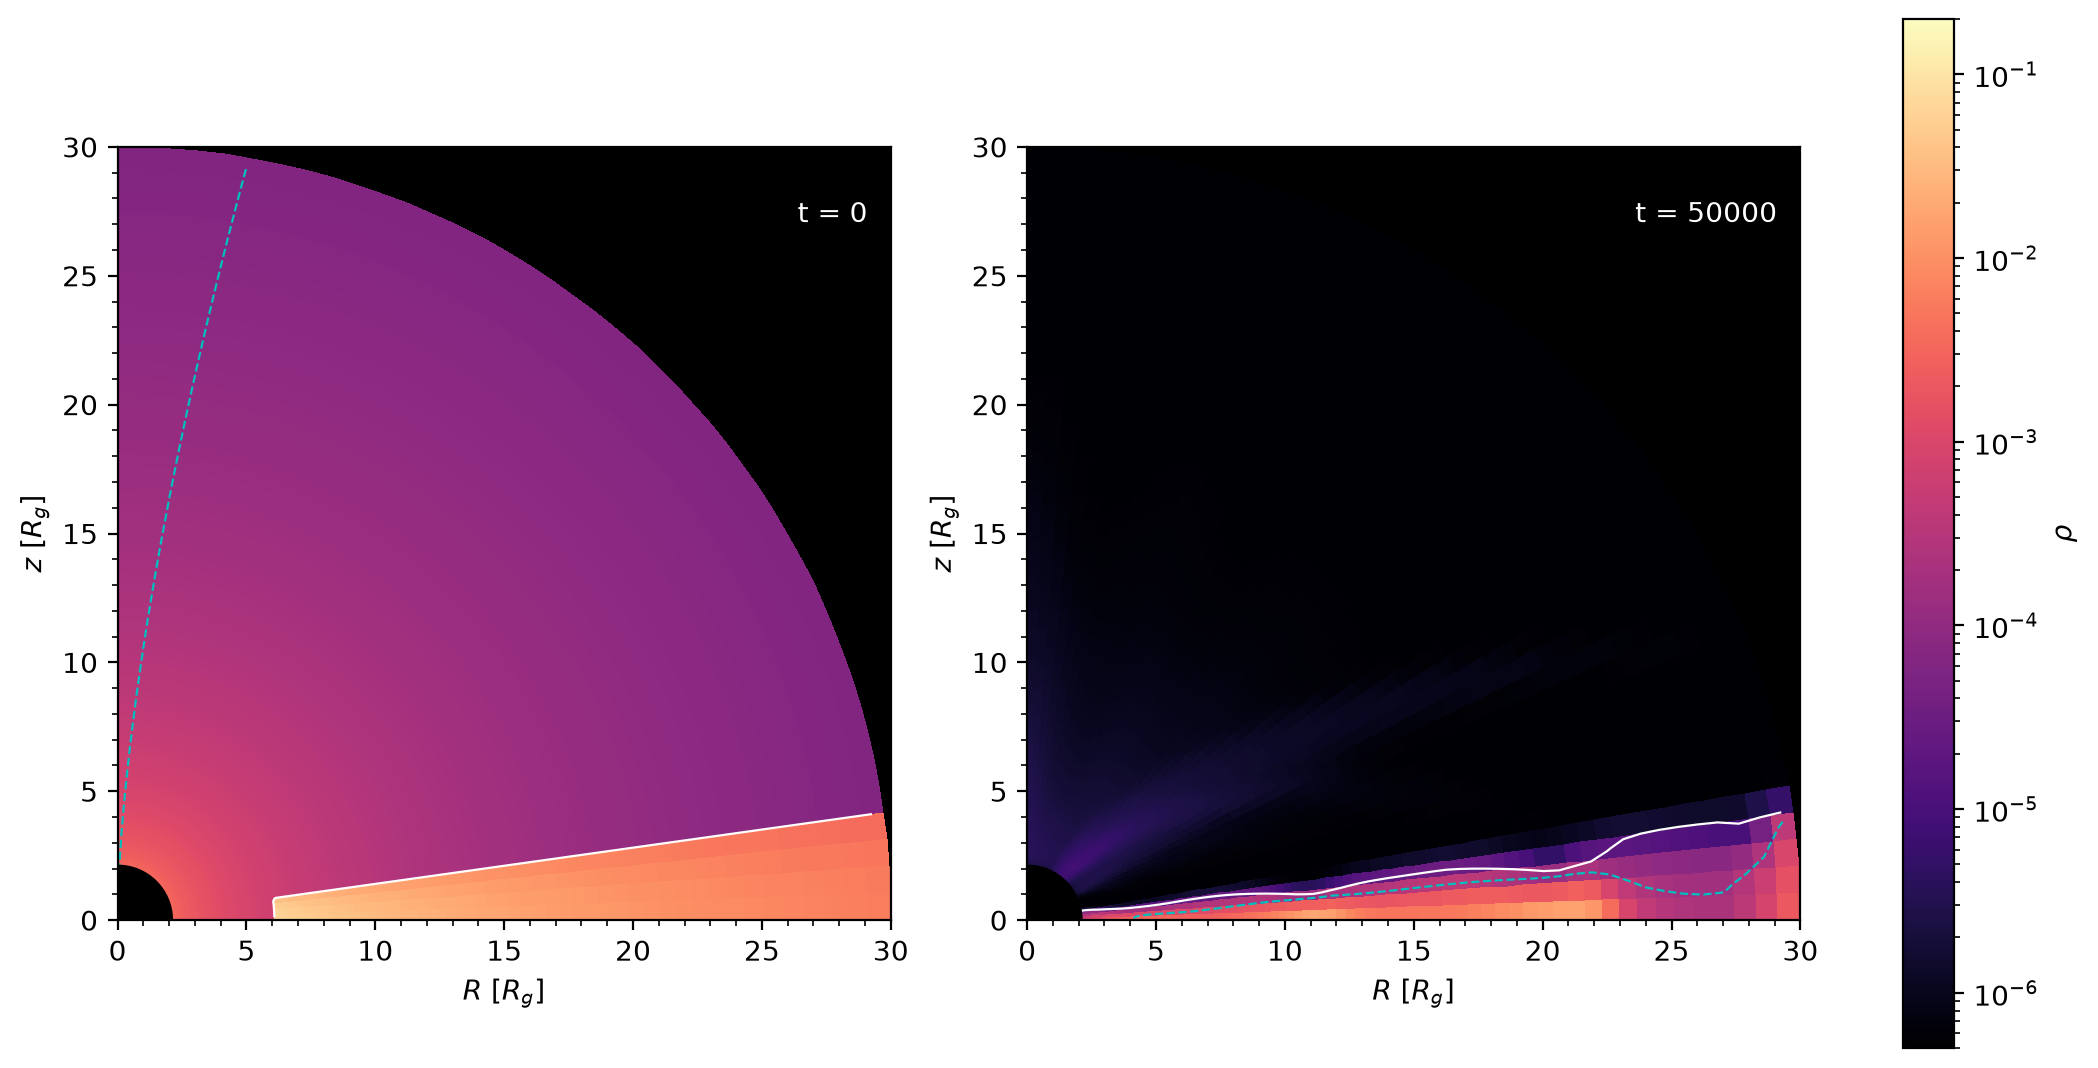

In [9]:
snapshot_row(T_FULL, xlim=(0, 30), ylim=(0, 30), ncol=2)

#### 1.2. Early Instabilities and Surface Layer

The first few hundred $t_g$: the inner edge plunges inside $R_\mathrm{isco}$, the radiation supported interior inflates and the dense
surface layer forms and breaks up. With the output cadence of the run, $50\,t_g$ is the earliest frame after $t = 0$.

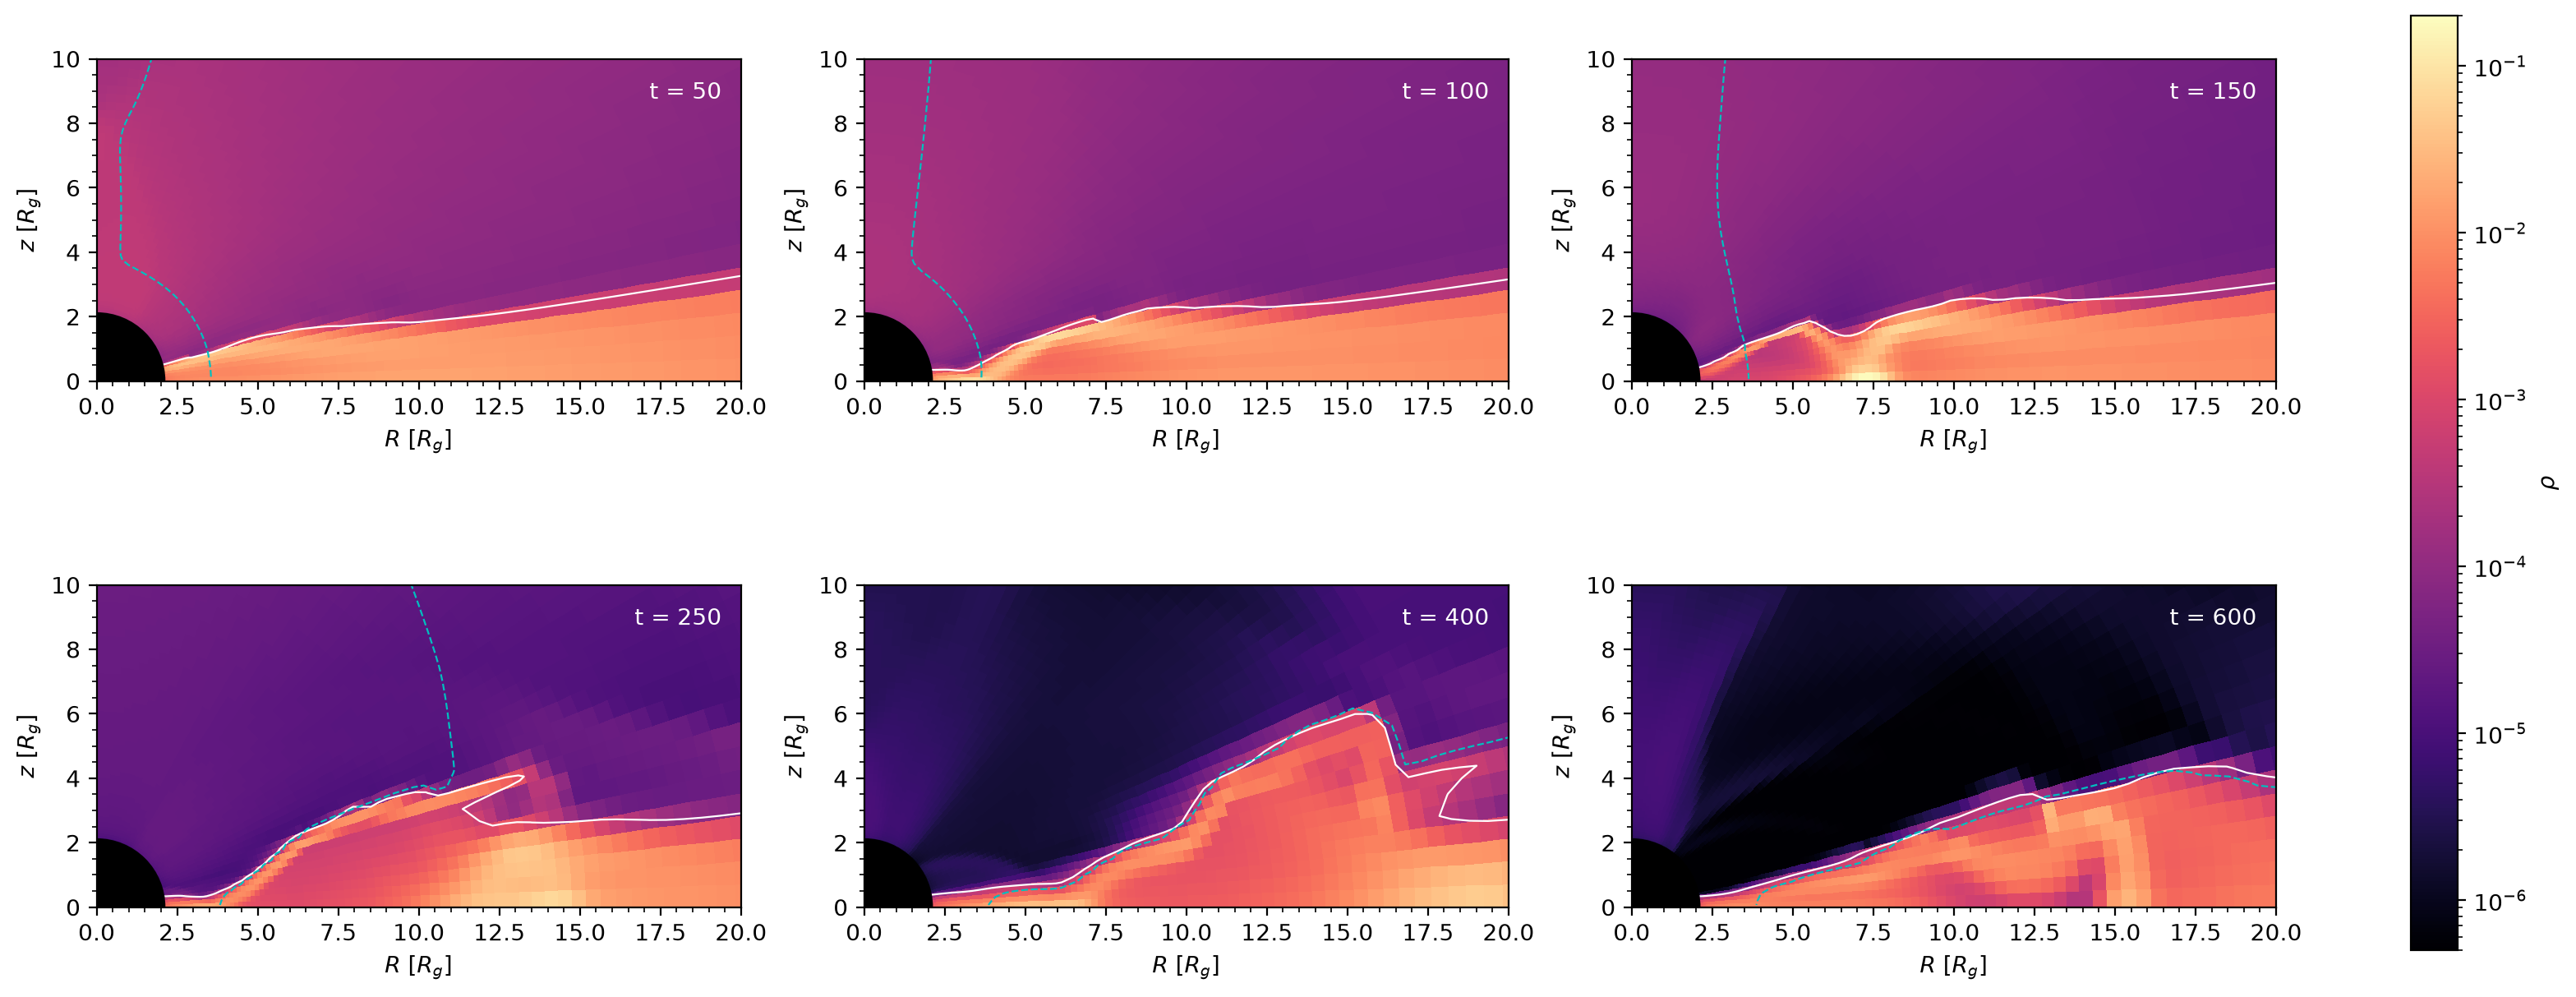

In [10]:
snapshot_row(T_EARLY)

#### 1.3. Evolution Towards the Quasi-Steady State

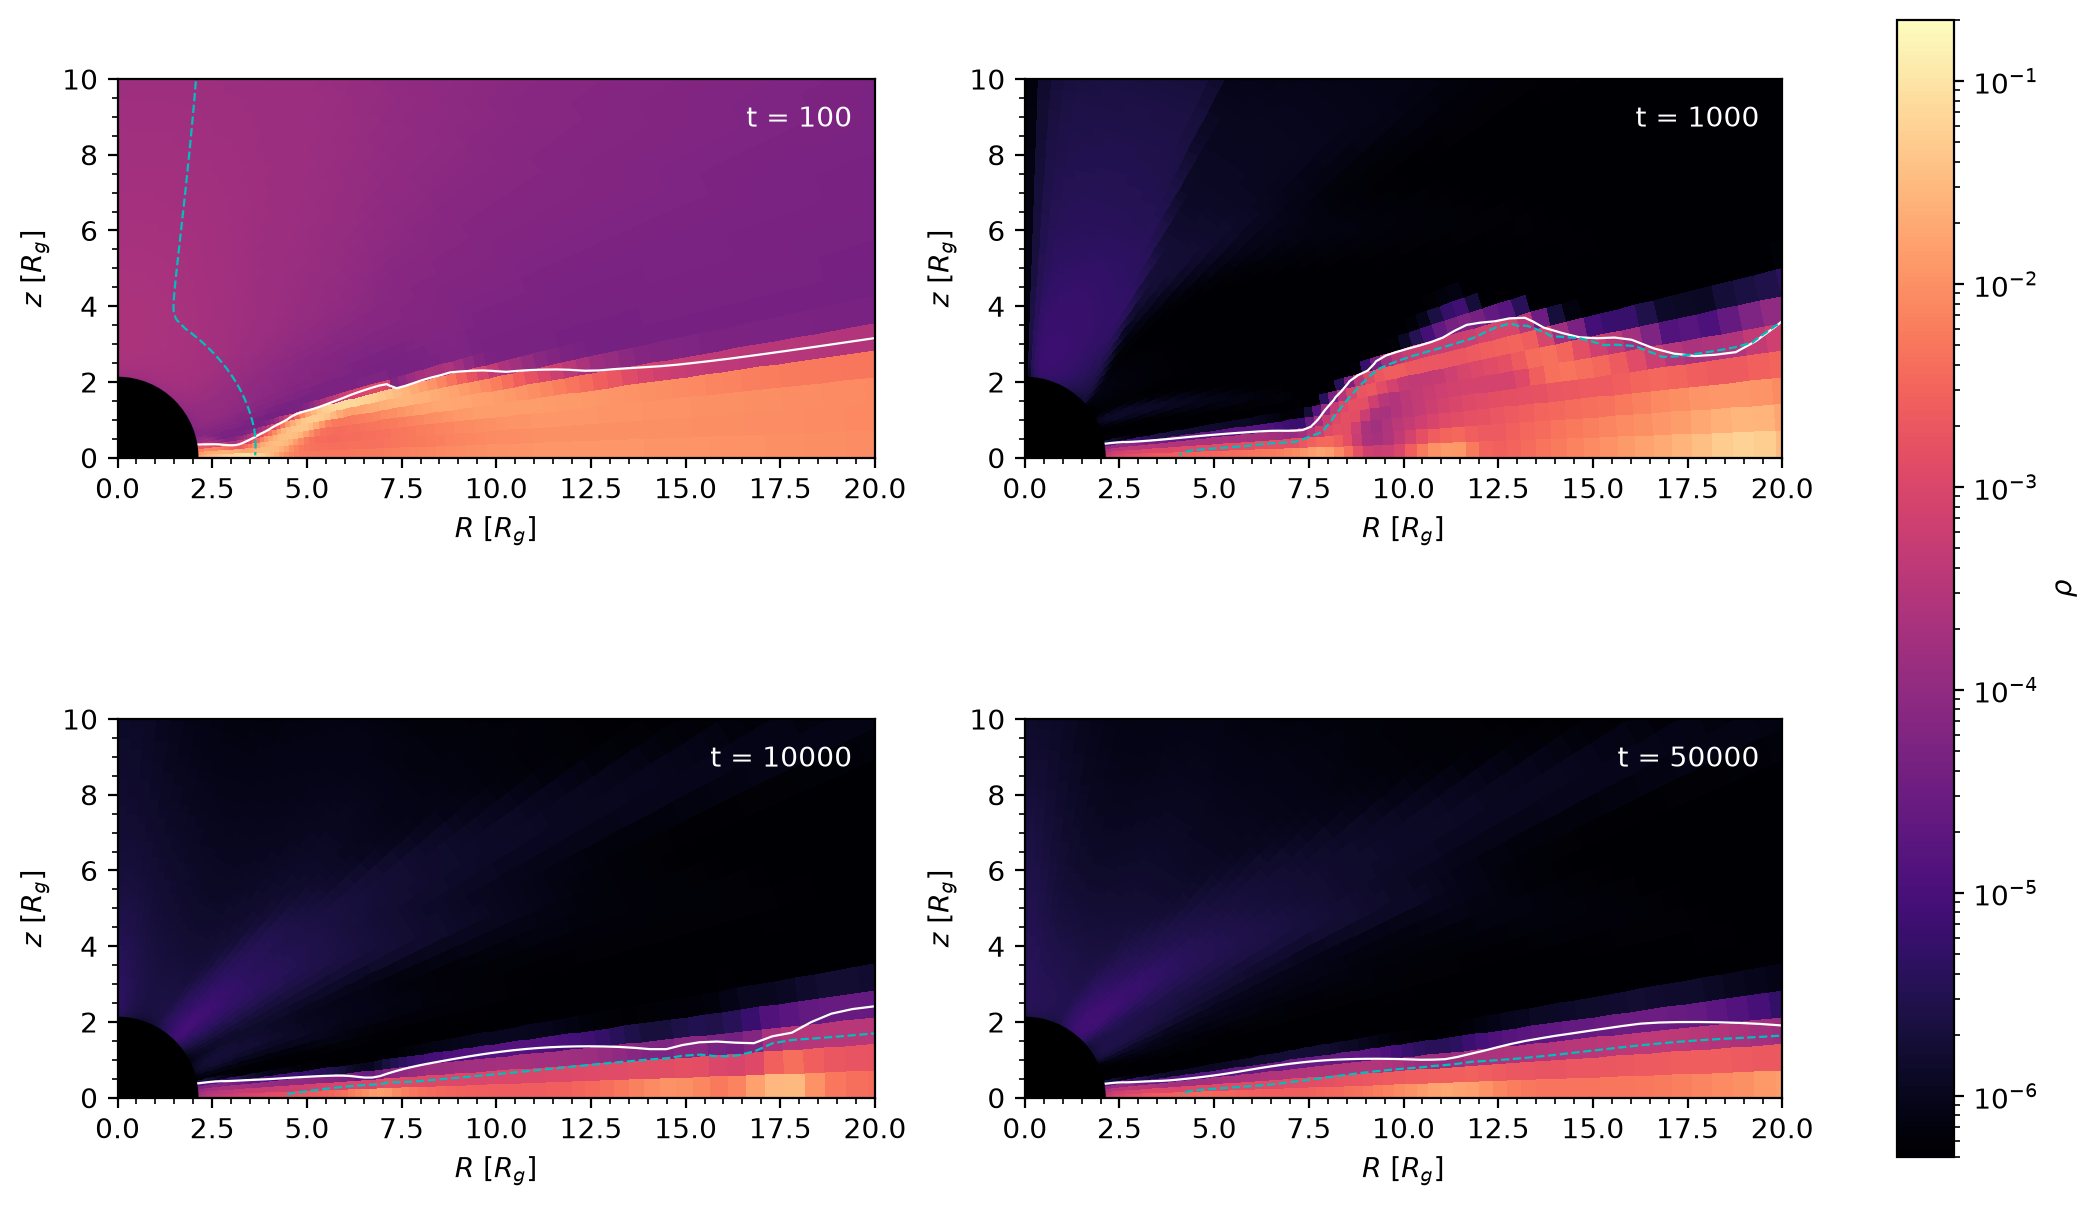

In [11]:
snapshot_row(T_EVOLUTION, ncol=2)

The same times for the gas temperature in Kelvin, and for the ratio $T_g/T_r$, which is close to unity where Compton and absorption
keep gas and radiation coupled.

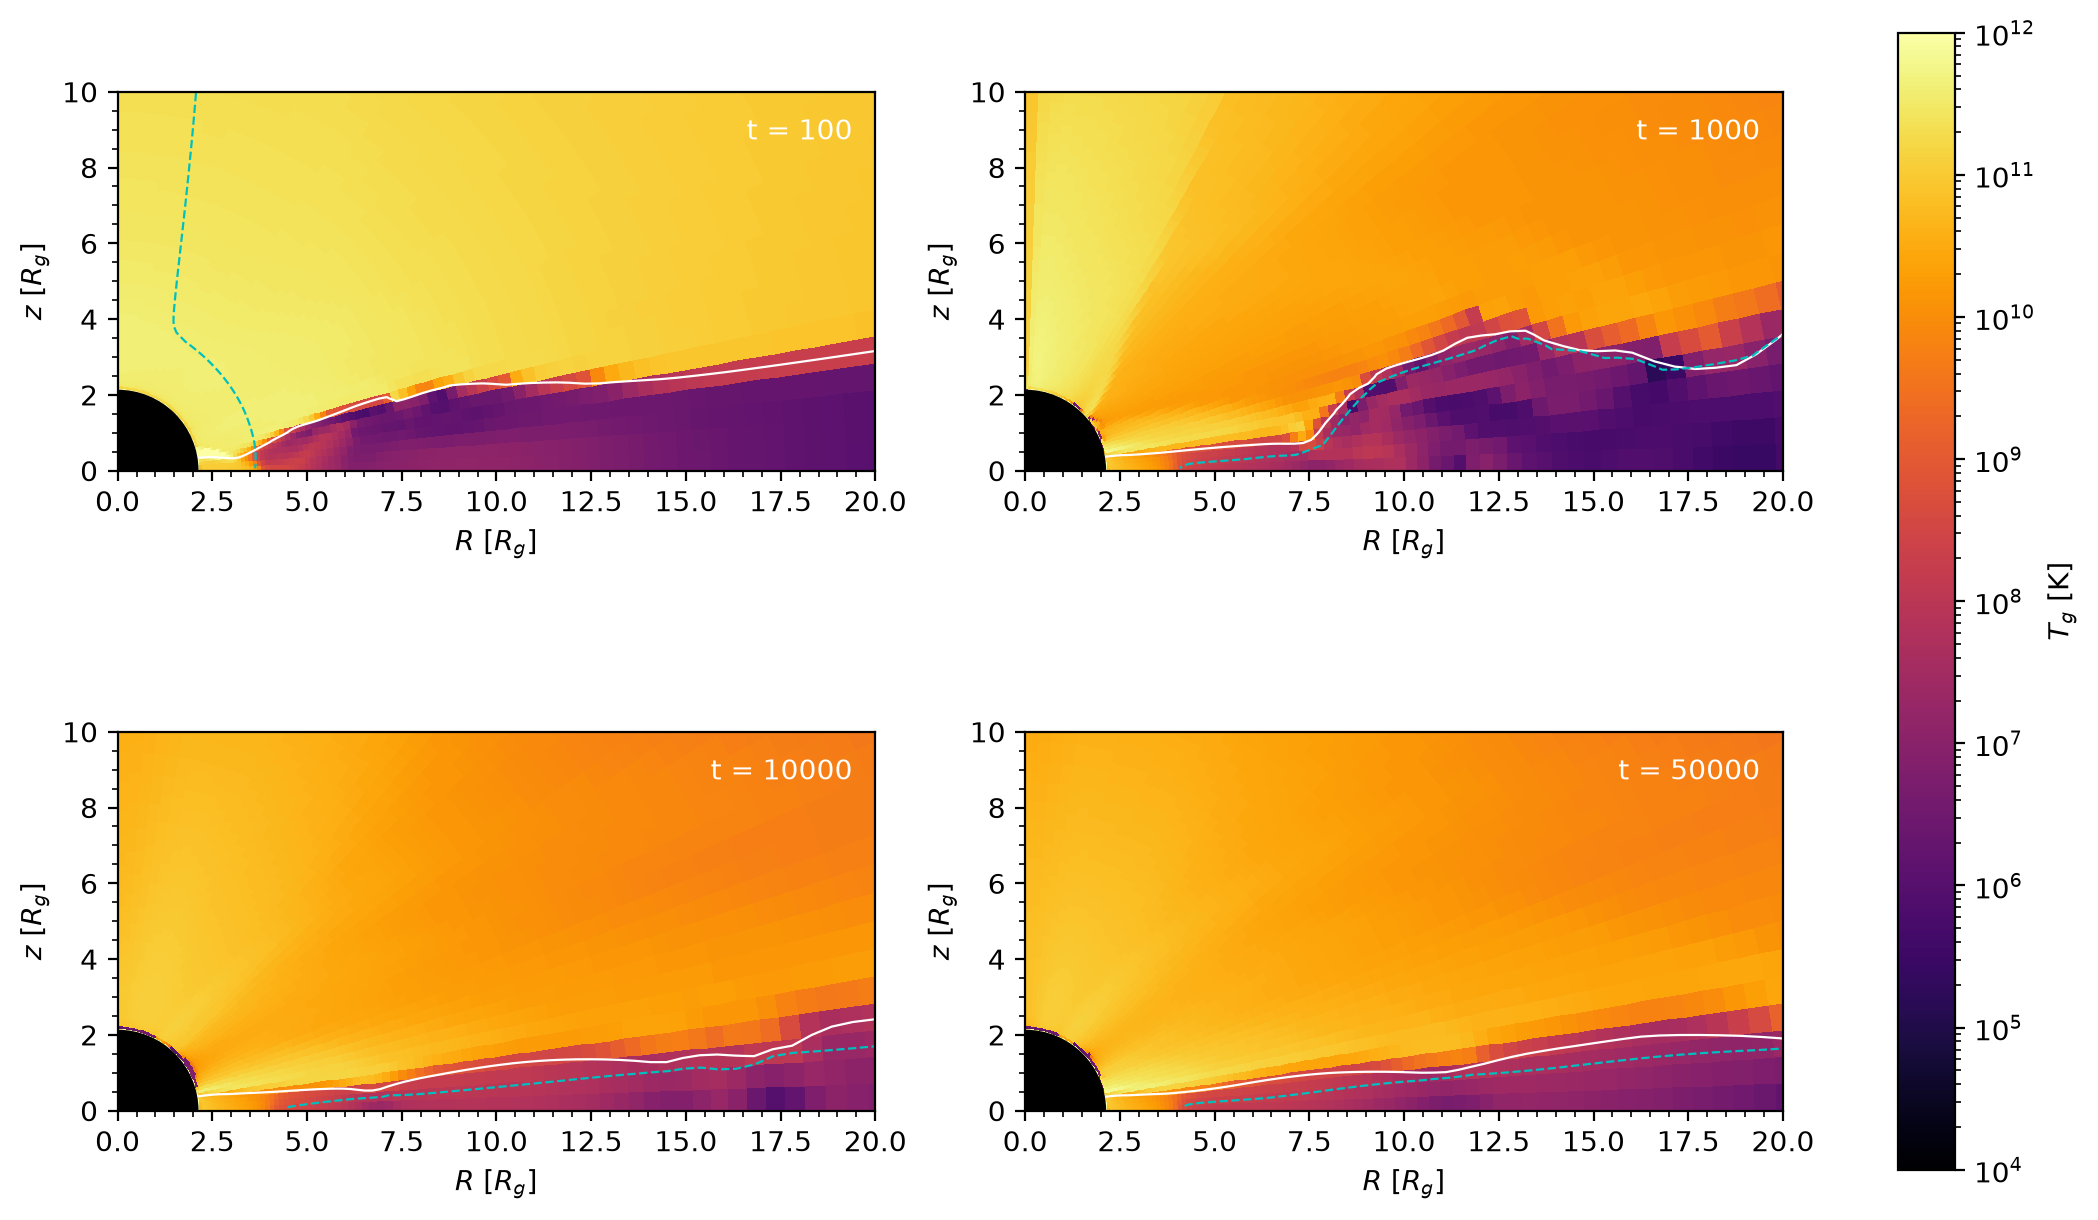

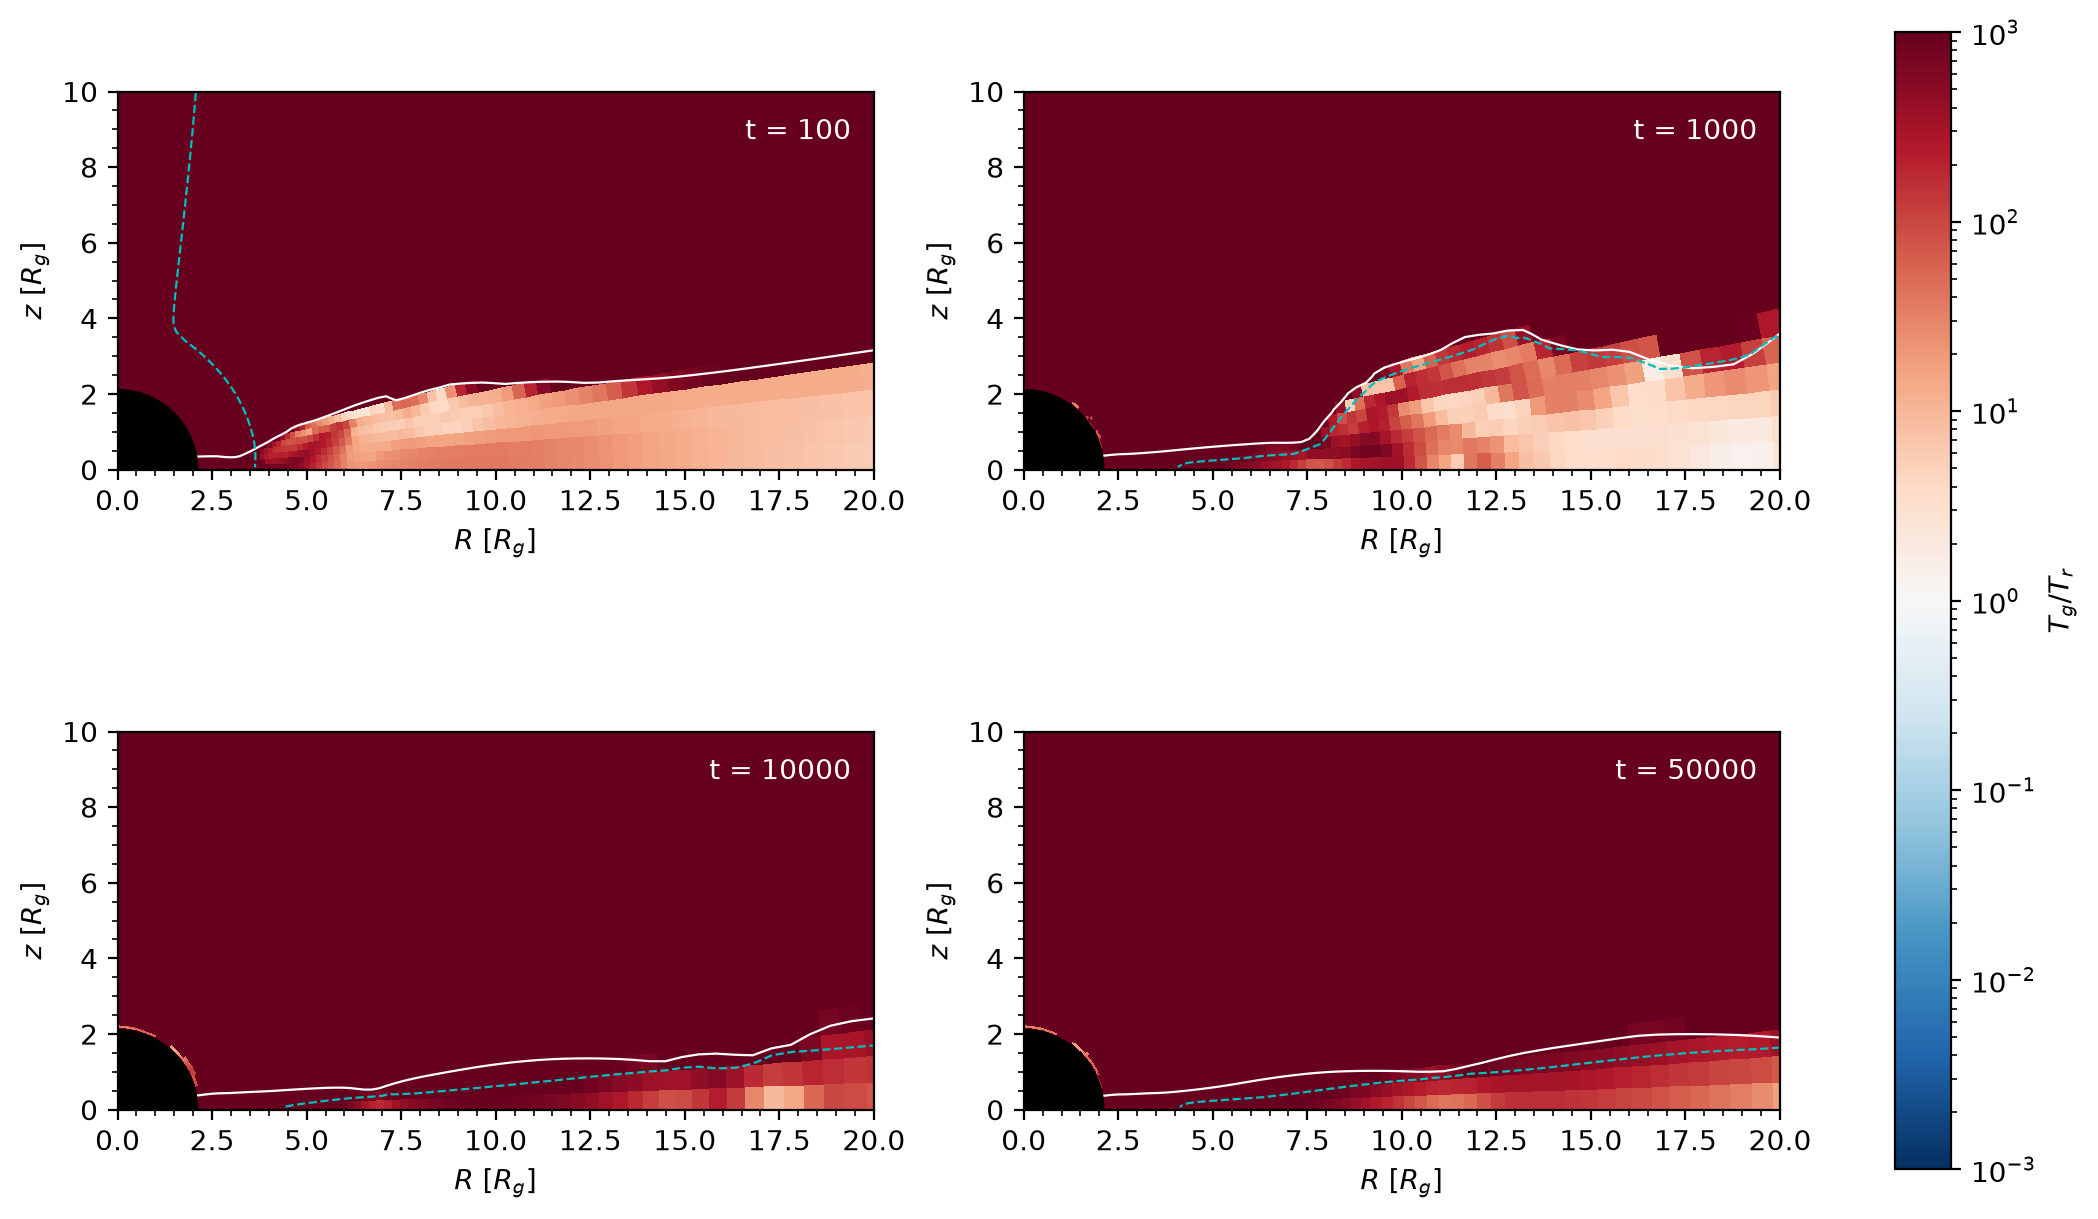

In [12]:
snapshot_row(T_EVOLUTION, field='Tg', norm=LogNorm(vmin=1e4, vmax=1e12), cmap='inferno', label=r'$T_g$ [K]', ncol=2)
snapshot_row(T_EVOLUTION, field='ratio', norm=LogNorm(vmin=1e-3, vmax=1e3), cmap='RdBu_r', label=r'$T_g / T_r$', ncol=2)

### 2. Relaxation Into the Quasi-Steady State

A disk becomes steady from the inside out, on the local viscous time, so relaxation is measured as a function of radius. The
quasi-steady state still contains quasi-periodic density waves, so steadiness means *statistical* stationarity: averages over
windows much longer than the wave period no longer change, within their statistical uncertainty.

#### 2.1. Global Time Series

Total, disk and corona mass, radiation, thermal and kinetic energy, the accretion rate through the inner boundary and the luminosity
leaving the outer boundary.

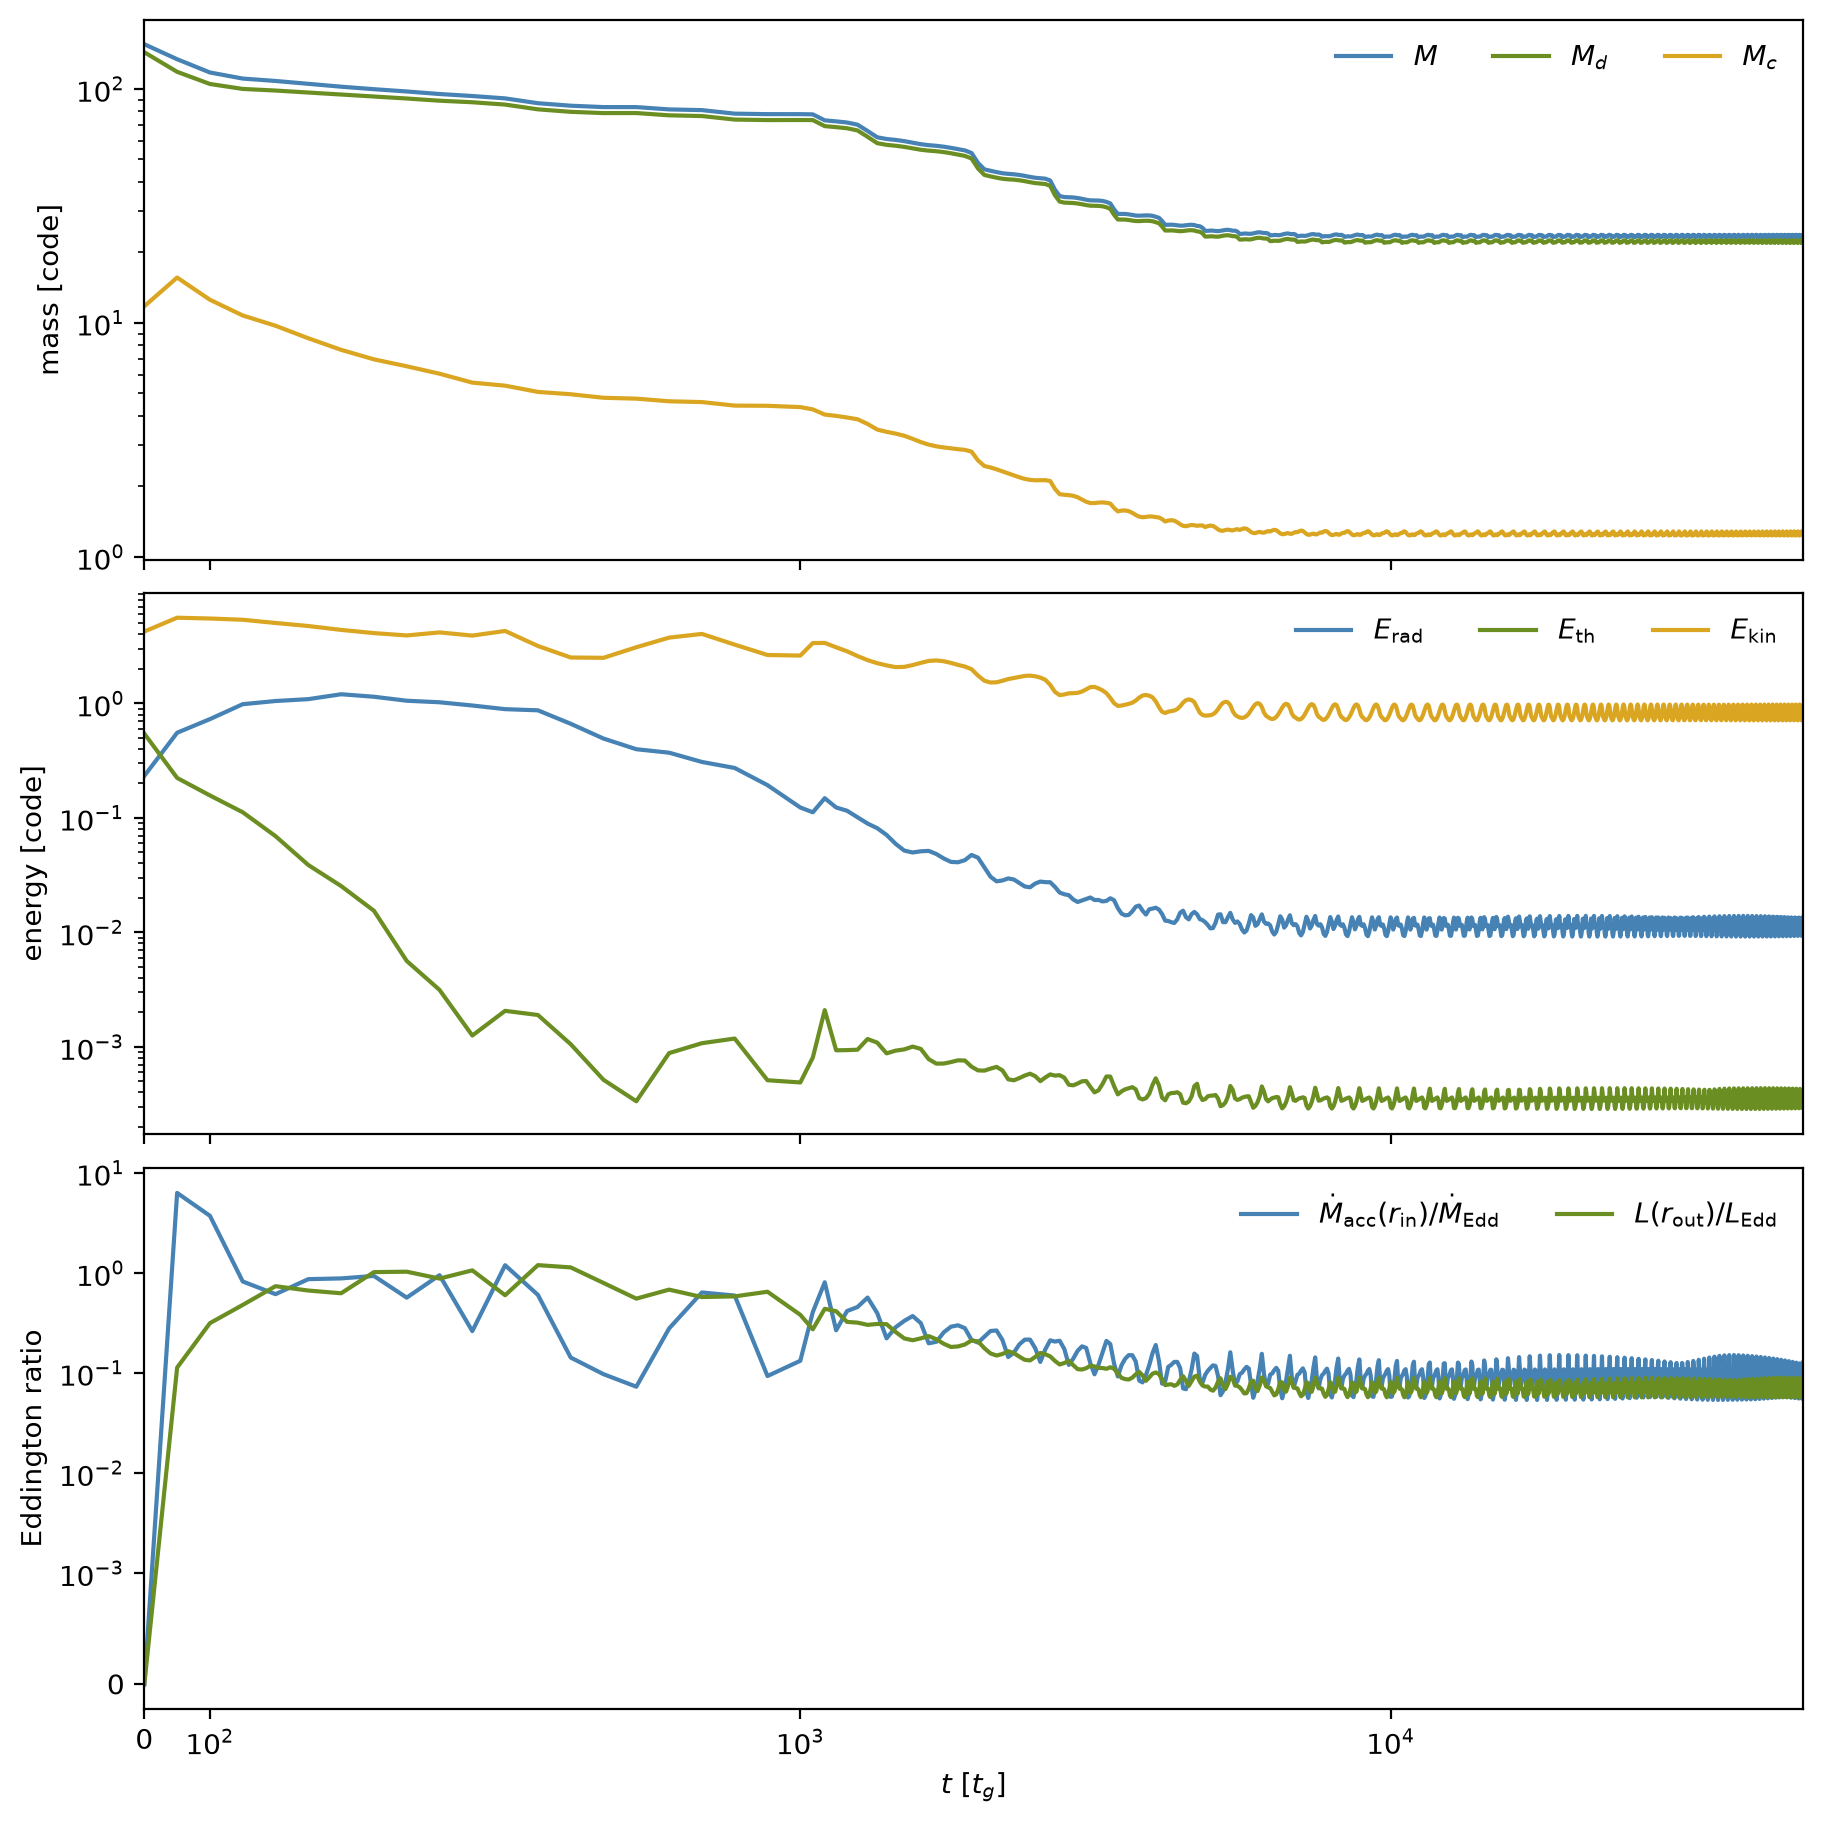

In [13]:
mdot_acc_in = -C['mdot'][:, 0]
L_out = C['L_out']

fig, axs = plt.subplots(3, 1, figsize=[9, 9], sharex=True)
axs[0].plot(T, C['M'], label=r'$M$')
axs[0].plot(T, C['M_d'], label=r'$M_d$')
axs[0].plot(T, C['M_c'], label=r'$M_c$')
axs[0].set_yscale('log'); axs[0].set_ylabel('mass [code]'); axs[0].legend(ncol=3)

axs[1].plot(T, C['E_rad'], label=r'$E_\mathrm{rad}$')
axs[1].plot(T, C['E_th'], label=r'$E_\mathrm{th}$')
axs[1].plot(T, C['E_kin'], label=r'$E_\mathrm{kin}$')
axs[1].set_yscale('log'); axs[1].set_ylabel('energy [code]'); axs[1].legend(ncol=3)

axs[2].plot(T, mdot_acc_in * MDOT0 / MDOT_EDD, label=r'$\dot M_\mathrm{acc}(r_\mathrm{in}) / \dot M_\mathrm{Edd}$')
axs[2].plot(T, L_out * L0 / L_EDD, label=r'$L(r_\mathrm{out}) / L_\mathrm{Edd}$')
axs[2].set_yscale('symlog', linthresh=1e-3); axs[2].set_ylabel('Eddington ratio'); axs[2].legend(ncol=2)
axs[2].set_xlabel(r'$t\ [t_g]$')
for ax in axs:
    ax.set_xscale('symlog', linthresh=1000)
    ax.set_xlim(0, T[-1])
plt.show()

#### 2.2. Window Statistics

For a quantity $X(t)$ sampled at the output cadence $\Delta t$, the sliding window mean over $N_W = W/\Delta t$ frames centred on
$t_c$ is

$$
\langle X \rangle_W(t_c) = \frac{1}{N_W}\sum_{|t_k - t_c| \leq W/2} X(t_k) .
$$

The reference state is the mean over the last fraction `REF_FRAC` of the run, $\langle X\rangle_\mathrm{ref}$. Consecutive frames are
correlated, so its standard error comes from block averaging: the reference interval is split into $N_b$ blocks of length `BLOCK`,
longer than the correlation time, with block means $\bar X_b$, and

$$
\mathrm{SE}_\mathrm{ref} = \frac{\mathrm{std}\left(\bar X_b\right)}{\sqrt{N_b}} .
$$

Assuming the same fluctuation statistics in a window of $N_W$ frames as in the reference interval of $N_\mathrm{ref}$ frames, the
standard error of the difference is $\sigma = \mathrm{SE}_\mathrm{ref}\sqrt{1 + N_\mathrm{ref}/N_W}$, and the normalized distance is

$$
D(t_c) = \frac{\left|\langle X\rangle_W(t_c) - \langle X\rangle_\mathrm{ref}\right|}{\sigma} .
$$

The relaxation time is the first window centre after which the window mean stays consistent with the reference,

$$
t_\mathrm{relax} = \min\left\{ t_c : D(t_c') < Z_\mathrm{crit}\ \ \forall\, t_c' \geq t_c \right\}, \qquad Z_\mathrm{crit} = 2 .
$$

window 50 frames,  block 10 frames,  reference 200 frames (t > 40050)


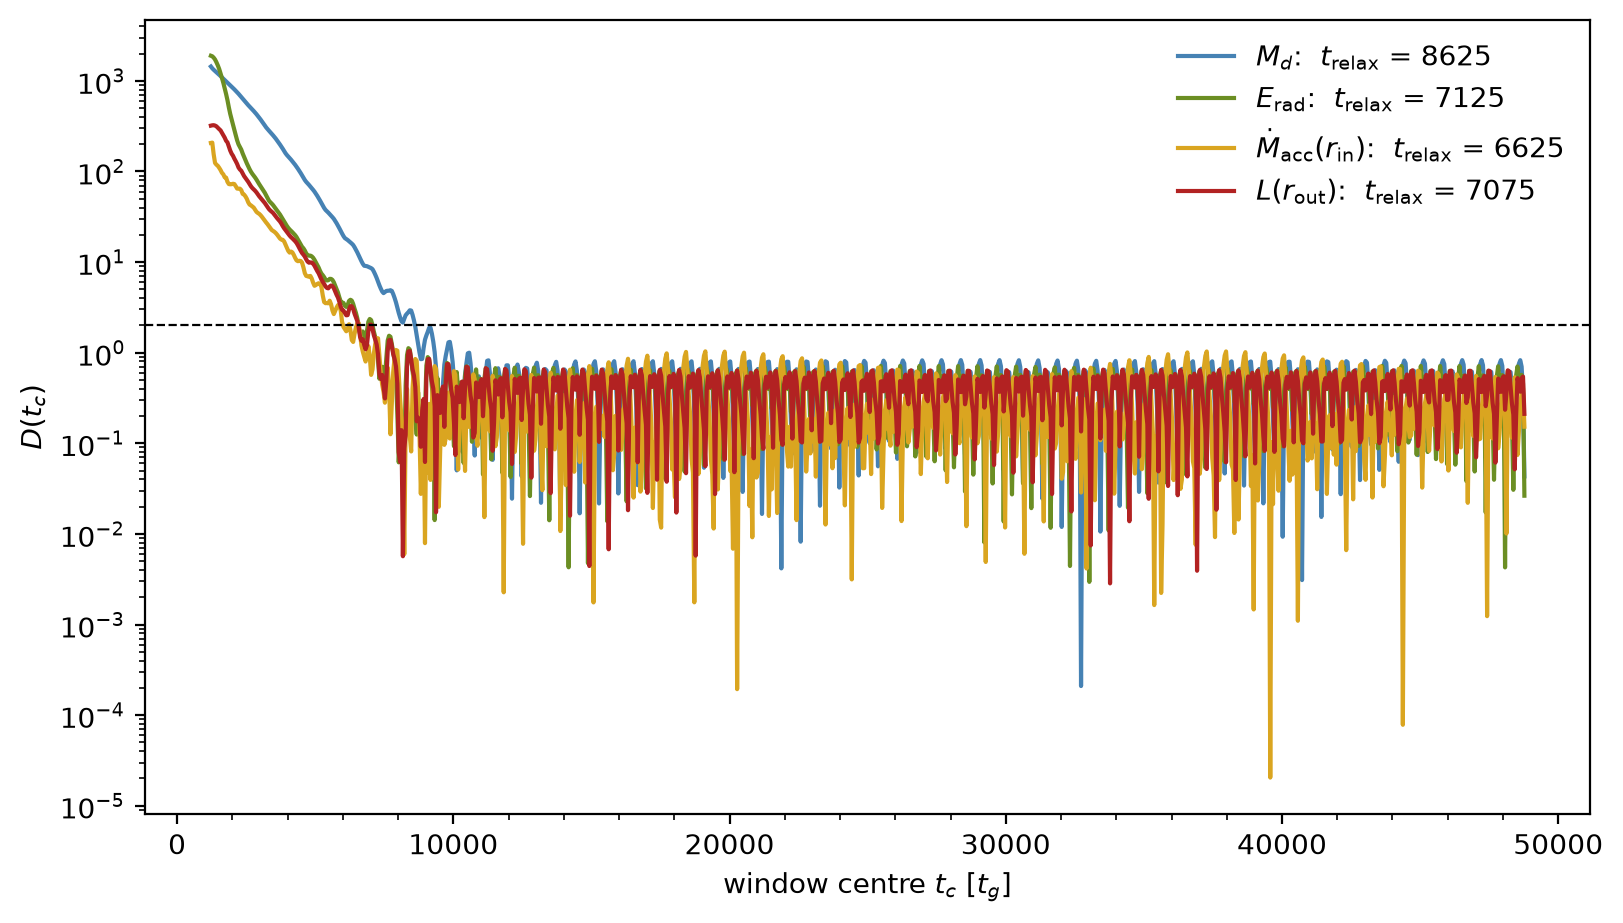

In [14]:
N_W = max(int(round(W_WINDOW / DT_OUT)), 2)
N_B = max(int(round(BLOCK / DT_OUT)), 1)
N_REF = max(int(round(REF_FRAC * T.size)), 2 * N_B)

def window_means(X):
    # sliding means over N_W frames along axis 0, returned with their centre times
    X = np.asarray(X, dtype=float)
    cs = np.cumsum(np.concatenate([np.zeros((1,) + X.shape[1:]), X]), axis=0)
    means = (cs[N_W:] - cs[:-N_W]) / N_W
    centres = 0.5 * (T[N_W - 1:] + T[:T.size - N_W + 1])
    return centres, means

def block_se(X):
    # mean and block standard error over the reference interval
    Xr = np.asarray(X, dtype=float)[-N_REF:]
    nb = Xr.shape[0] // N_B
    blocks = Xr[:nb * N_B].reshape((nb, N_B) + Xr.shape[1:]).mean(axis=1)
    return Xr.mean(axis=0), blocks.std(axis=0, ddof=1) / np.sqrt(nb)

def relaxation(X):
    # relaxation time of X, for a time series or for every column of a (time, radius) array
    tc, m = window_means(X)
    ref, se = block_se(X)
    sigma = np.maximum(se * np.sqrt(1.0 + N_REF / N_W), 1e-300)
    D = np.abs(m - ref) / sigma
    ok = D < Z_CRIT
    # first index after which all later windows are consistent
    tail_ok = np.flip(np.logical_and.accumulate(np.flip(ok, axis=0), axis=0), axis=0)
    first = np.argmax(tail_ok, axis=0)
    t_relax = np.where(tail_ok.any(axis=0), tc[first], np.nan)
    return t_relax, tc, D

print(f"window {N_W} frames,  block {N_B} frames,  reference {N_REF} frames (t > {T[-N_REF]:.0f})")

GLOBAL = {
    r'$M_d$': C['M_d'],
    r'$E_\mathrm{rad}$': C['E_rad'],
    r'$\dot M_\mathrm{acc}(r_\mathrm{in})$': mdot_acc_in,
    r'$L(r_\mathrm{out})$': L_out,
}
T_RELAX_GLOBAL = {}
fig, ax = plt.subplots(figsize=[8, 4.5])
for label, X in GLOBAL.items():
    tr, tc, D = relaxation(X)
    T_RELAX_GLOBAL[label] = float(tr)
    ax.plot(tc, D, label=f"{label}:  $t_\\mathrm{{relax}}$ = {float(tr):.0f}")
ax.axhline(Z_CRIT, color='k', lw=0.8, ls='--')
ax.set_yscale('log'); ax.set_xlabel(r'window centre $t_c\ [t_g]$'); ax.set_ylabel(r'$D(t_c)$')
ax.legend()
plt.show()

#### 2.3. Relaxation as a Function of Radius

The same statistic applied to $\log_{10}\Sigma(r)$ and to $\dot M_\mathrm{acc}(r)$ at every radius gives $t_\mathrm{relax}(r)$, which
is compared with the viscous time $t_\nu(r)$.

The inflow equilibrium radius $R_\mathrm{eq}(t_c)$ is the largest radius out to which the window averaged accretion rate is
constant, i.e. consistent with its value at the inner boundary at every radius in between,

$$
R_\mathrm{eq}(t_c) = \max\left\{ r_k : \frac{\left|\langle\dot M_\mathrm{acc}\rangle_W(r_j) - \langle\dot M_\mathrm{acc}\rangle_W(r_\mathrm{in})\right|}
{\sqrt{\sigma_j^2 + \sigma_\mathrm{in}^2}} < Z_\mathrm{crit}\ \ \forall\, j \leq k \right\},
$$

with $\sigma_j$ the window standard errors built as above. It is compared with $R_\nu(t)$, where $t_\nu(R_\nu) = t$.

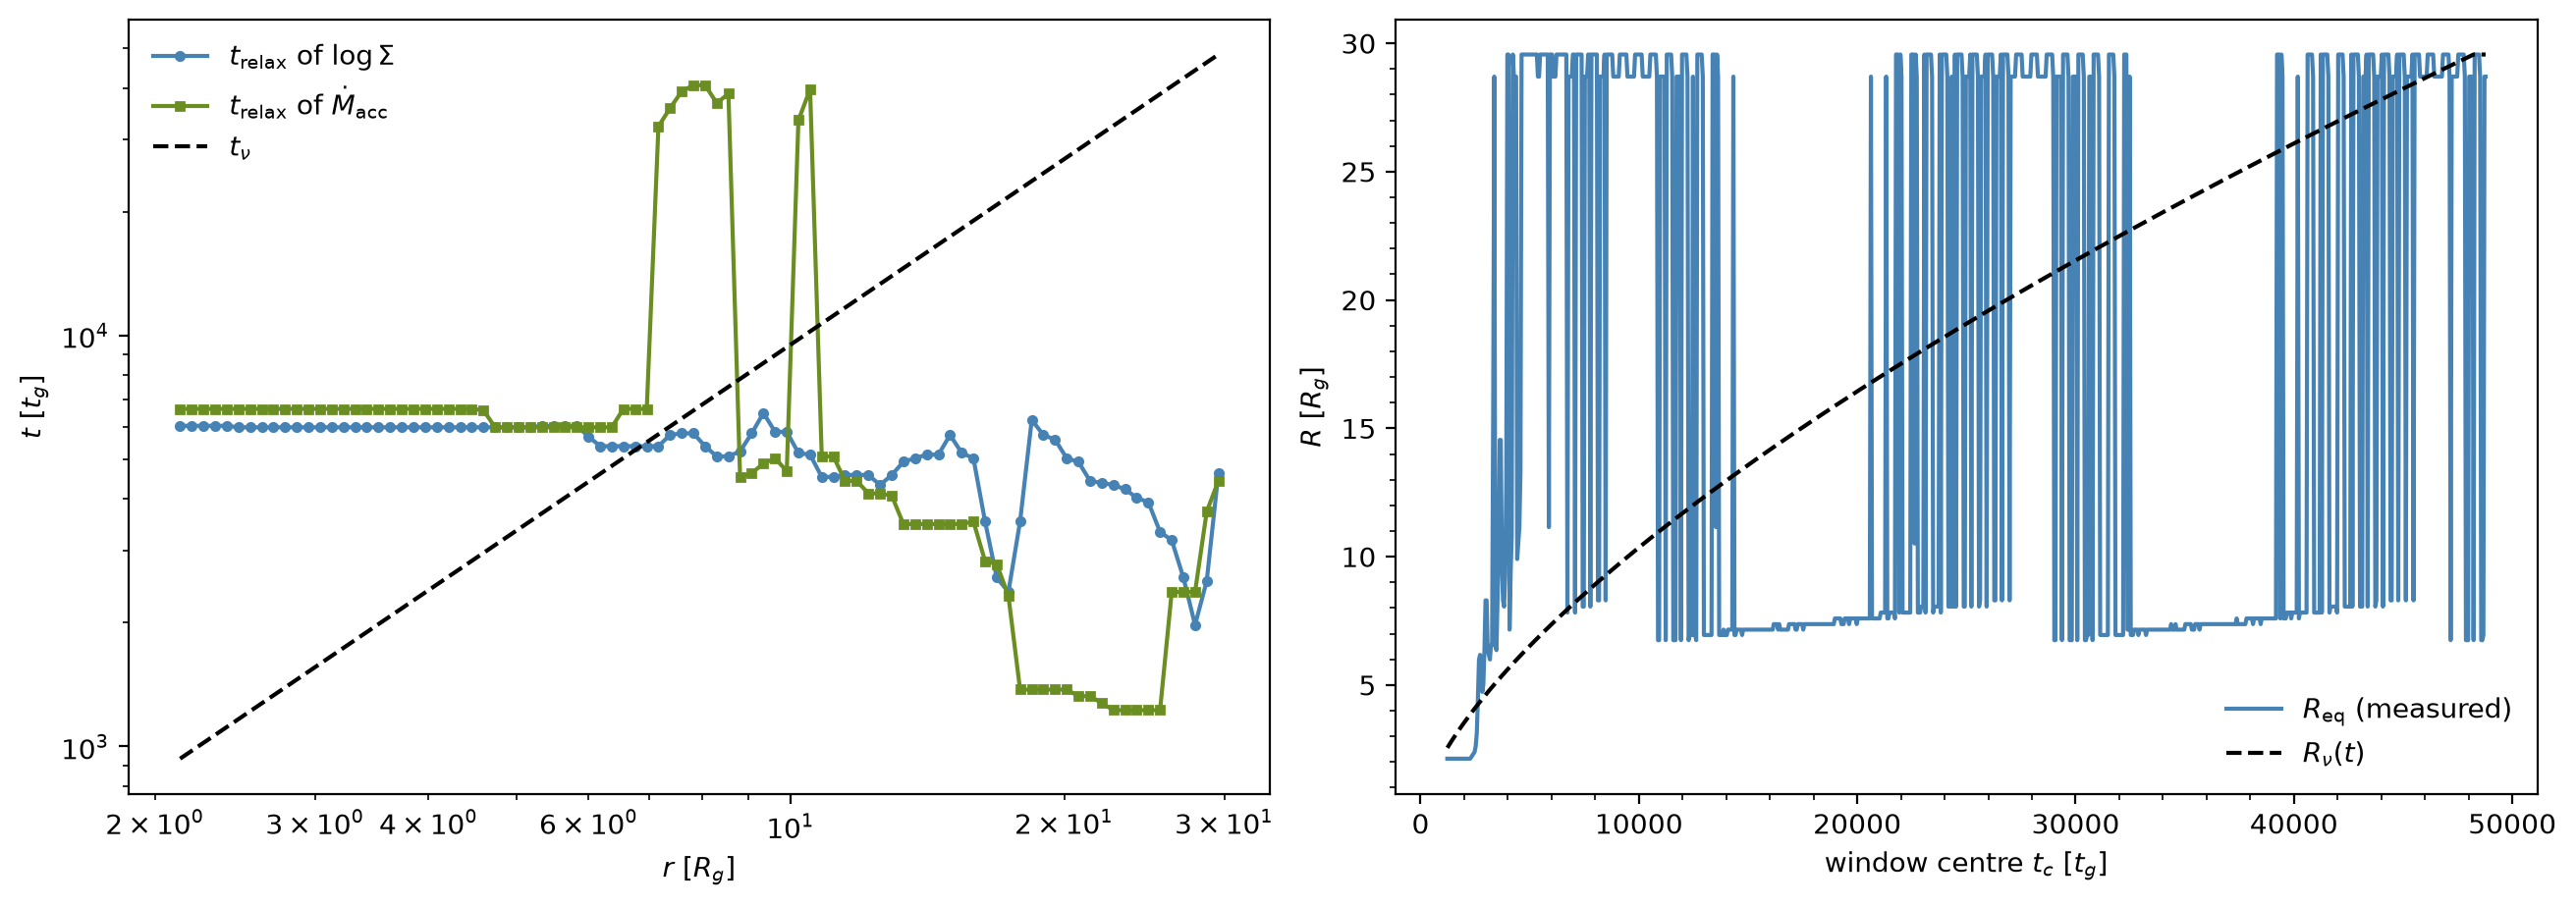

In [15]:
logsig = np.log10(np.maximum(C['sigma'], 1e-300))
mdot_acc = -C['mdot']

t_relax_sigma, _, _ = relaxation(logsig)
t_relax_mdot, _, _ = relaxation(mdot_acc)

tc, m_mdot = window_means(mdot_acc)
_, se_mdot = block_se(mdot_acc)
sig_w = se_mdot * np.sqrt(N_REF / N_W)
diff = np.abs(m_mdot - m_mdot[:, :1]) / np.sqrt(sig_w[None, :]**2 + sig_w[0]**2 + 1e-300)
flat = np.logical_and.accumulate(diff < Z_CRIT, axis=1)
R_EQ = np.array([R_C[np.nonzero(row)[0][-1]] if row.any() else np.nan for row in flat])

fig, axs = plt.subplots(1, 2, figsize=[13, 4.5])
ax = axs[0]
ax.plot(R_C, t_relax_sigma, 'o-', ms=3, label=r'$t_\mathrm{relax}$ of $\log\Sigma$')
ax.plot(R_C, t_relax_mdot, 's-', ms=3, label=r'$t_\mathrm{relax}$ of $\dot M_\mathrm{acc}$')
ax.plot(R_C, t_viscous(R_C), 'k--', label=r'$t_\nu$')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$r\ [R_g]$'); ax.set_ylabel(r'$t\ [t_g]$'); ax.legend()

ax = axs[1]
ax.plot(tc, R_EQ, label=r'$R_\mathrm{eq}$ (measured)')
ax.plot(tc, np.clip(r_viscous(tc), R_C[0], R_C[-1]), 'k--', label=r'$R_\nu(t)$')
ax.set_xlabel(r'window centre $t_c\ [t_g]$'); ax.set_ylabel(r'$R\ [R_g]$'); ax.legend()
plt.show()

#### 2.4. Stationarity Tests

As an independent check, two standard tests are applied to block averaged global series, which removes most of the autocorrelation
on scales shorter than `BLOCK`:

- KPSS, with the null hypothesis that the series is stationary around a constant. Stationarity is accepted for $p > 0.05$.
- Augmented Dickey–Fuller, with the null hypothesis of a unit root, i.e. non-stationary. Stationarity is supported for $p < 0.05$.

Both are evaluated on the series starting at successively later times $t_s$. The earliest $t_s$ for which both indicate
stationarity, with at least $12$ blocks remaining, is $t_\mathrm{stat}$.

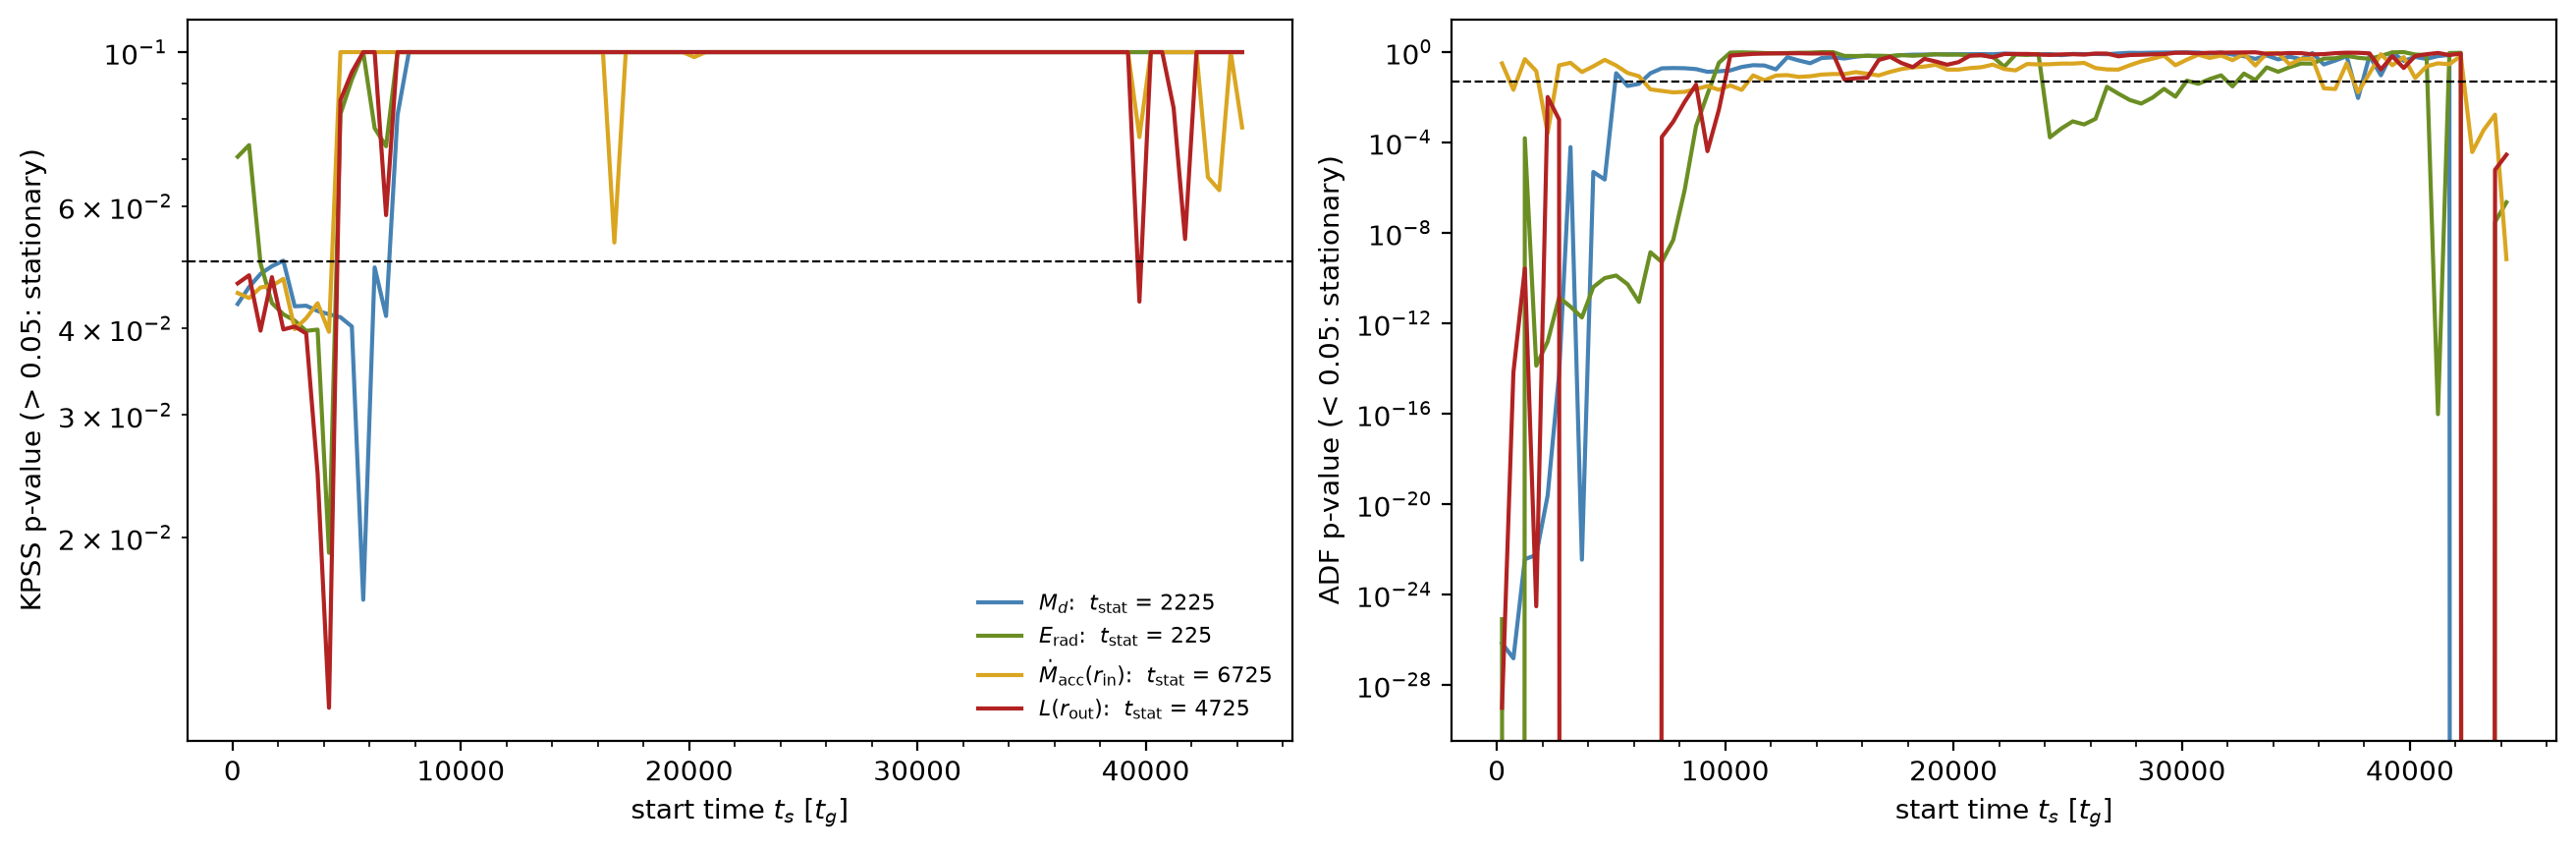

In [16]:
def block_series(X):
    nb = X.size // N_B
    tb = T[:nb * N_B].reshape(nb, N_B).mean(axis=1)
    return tb, X[:nb * N_B].reshape(nb, N_B).mean(axis=1)

def stationarity_start(X, min_blocks=12):
    tb, xb = block_series(np.asarray(X, dtype=float))
    rows = []
    for s in range(0, xb.size - min_blocks + 1):
        seg = xb[s:]
        p_kpss = kpss(seg, regression='c', nlags='auto')[1]
        p_adf = adfuller(seg, autolag='AIC')[1]
        rows.append((tb[s], p_kpss, p_adf))
    rows = np.array(rows)
    good = (rows[:, 1] > 0.05) & (rows[:, 2] < 0.05)
    t_stat = rows[np.argmax(good), 0] if good.any() else np.nan
    return t_stat, rows

T_STAT = {}
fig, axs = plt.subplots(1, 2, figsize=[13, 4.2], sharex=True)
for label, X in GLOBAL.items():
    t_stat, rows = stationarity_start(X)
    T_STAT[label] = float(t_stat)
    axs[0].plot(rows[:, 0], rows[:, 1], label=f"{label}:  $t_\\mathrm{{stat}}$ = {t_stat:.0f}")
    axs[1].plot(rows[:, 0], rows[:, 2], label=label)
axs[0].axhline(0.05, color='k', lw=0.8, ls='--'); axs[1].axhline(0.05, color='k', lw=0.8, ls='--')
axs[0].set_ylabel('KPSS p-value (> 0.05: stationary)'); axs[1].set_ylabel('ADF p-value (< 0.05: stationary)')
for ax in axs:
    ax.set_xlabel(r'start time $t_s\ [t_g]$'); ax.set_yscale('log')
axs[0].legend(fontsize=8)
plt.show()

#### 2.5. Start of the Steady Window

The steady window used by all following sections starts at the latest of the global relaxation and stationarity times, unless it
is set by hand with `T_STEADY_OVERRIDE`.

In [17]:
candidates = [v for v in list(T_RELAX_GLOBAL.values()) + list(T_STAT.values()) if np.isfinite(v)]
T_STEADY = T_STEADY_OVERRIDE if T_STEADY_OVERRIDE is not None else (max(candidates) if candidates else T[T.size // 2])
SEL = T >= T_STEADY
TS = T[SEL]
print("global relaxation times:", {k: round(v) if np.isfinite(v) else None for k, v in T_RELAX_GLOBAL.items()})
print("stationarity times:     ", {k: round(v) if np.isfinite(v) else None for k, v in T_STAT.items()})
print(f"steady window: t in [{TS[0]:.0f}, {TS[-1]:.0f}],  {TS.size} frames")
print(f"inflow equilibrium radius at the end of the run: R_eq = {R_EQ[-1]:.1f},  viscous estimate R_nu = {r_viscous(T[-1]):.1f}")

global relaxation times: {'$M_d$': 8625, '$E_\\mathrm{rad}$': 7125, '$\\dot M_\\mathrm{acc}(r_\\mathrm{in})$': 6625, '$L(r_\\mathrm{out})$': 7075}
stationarity times:      {'$M_d$': 2225, '$E_\\mathrm{rad}$': 225, '$\\dot M_\\mathrm{acc}(r_\\mathrm{in})$': 6725, '$L(r_\\mathrm{out})$': 4725}
steady window: t in [8650, 50000],  828 frames
inflow equilibrium radius at the end of the run: R_eq = 28.7,  viscous estimate R_nu = 30.3


### 3. Accretion

#### 3.1. Space–Time Diagram of the Mass Flux

$\dot M_\mathrm{acc}(r, t) = -\dot M(r,t)$ in units of $\dot M_\mathrm{Edd}$, positive for inflow. Disk and corona are separated
with the DiskFraction weights.

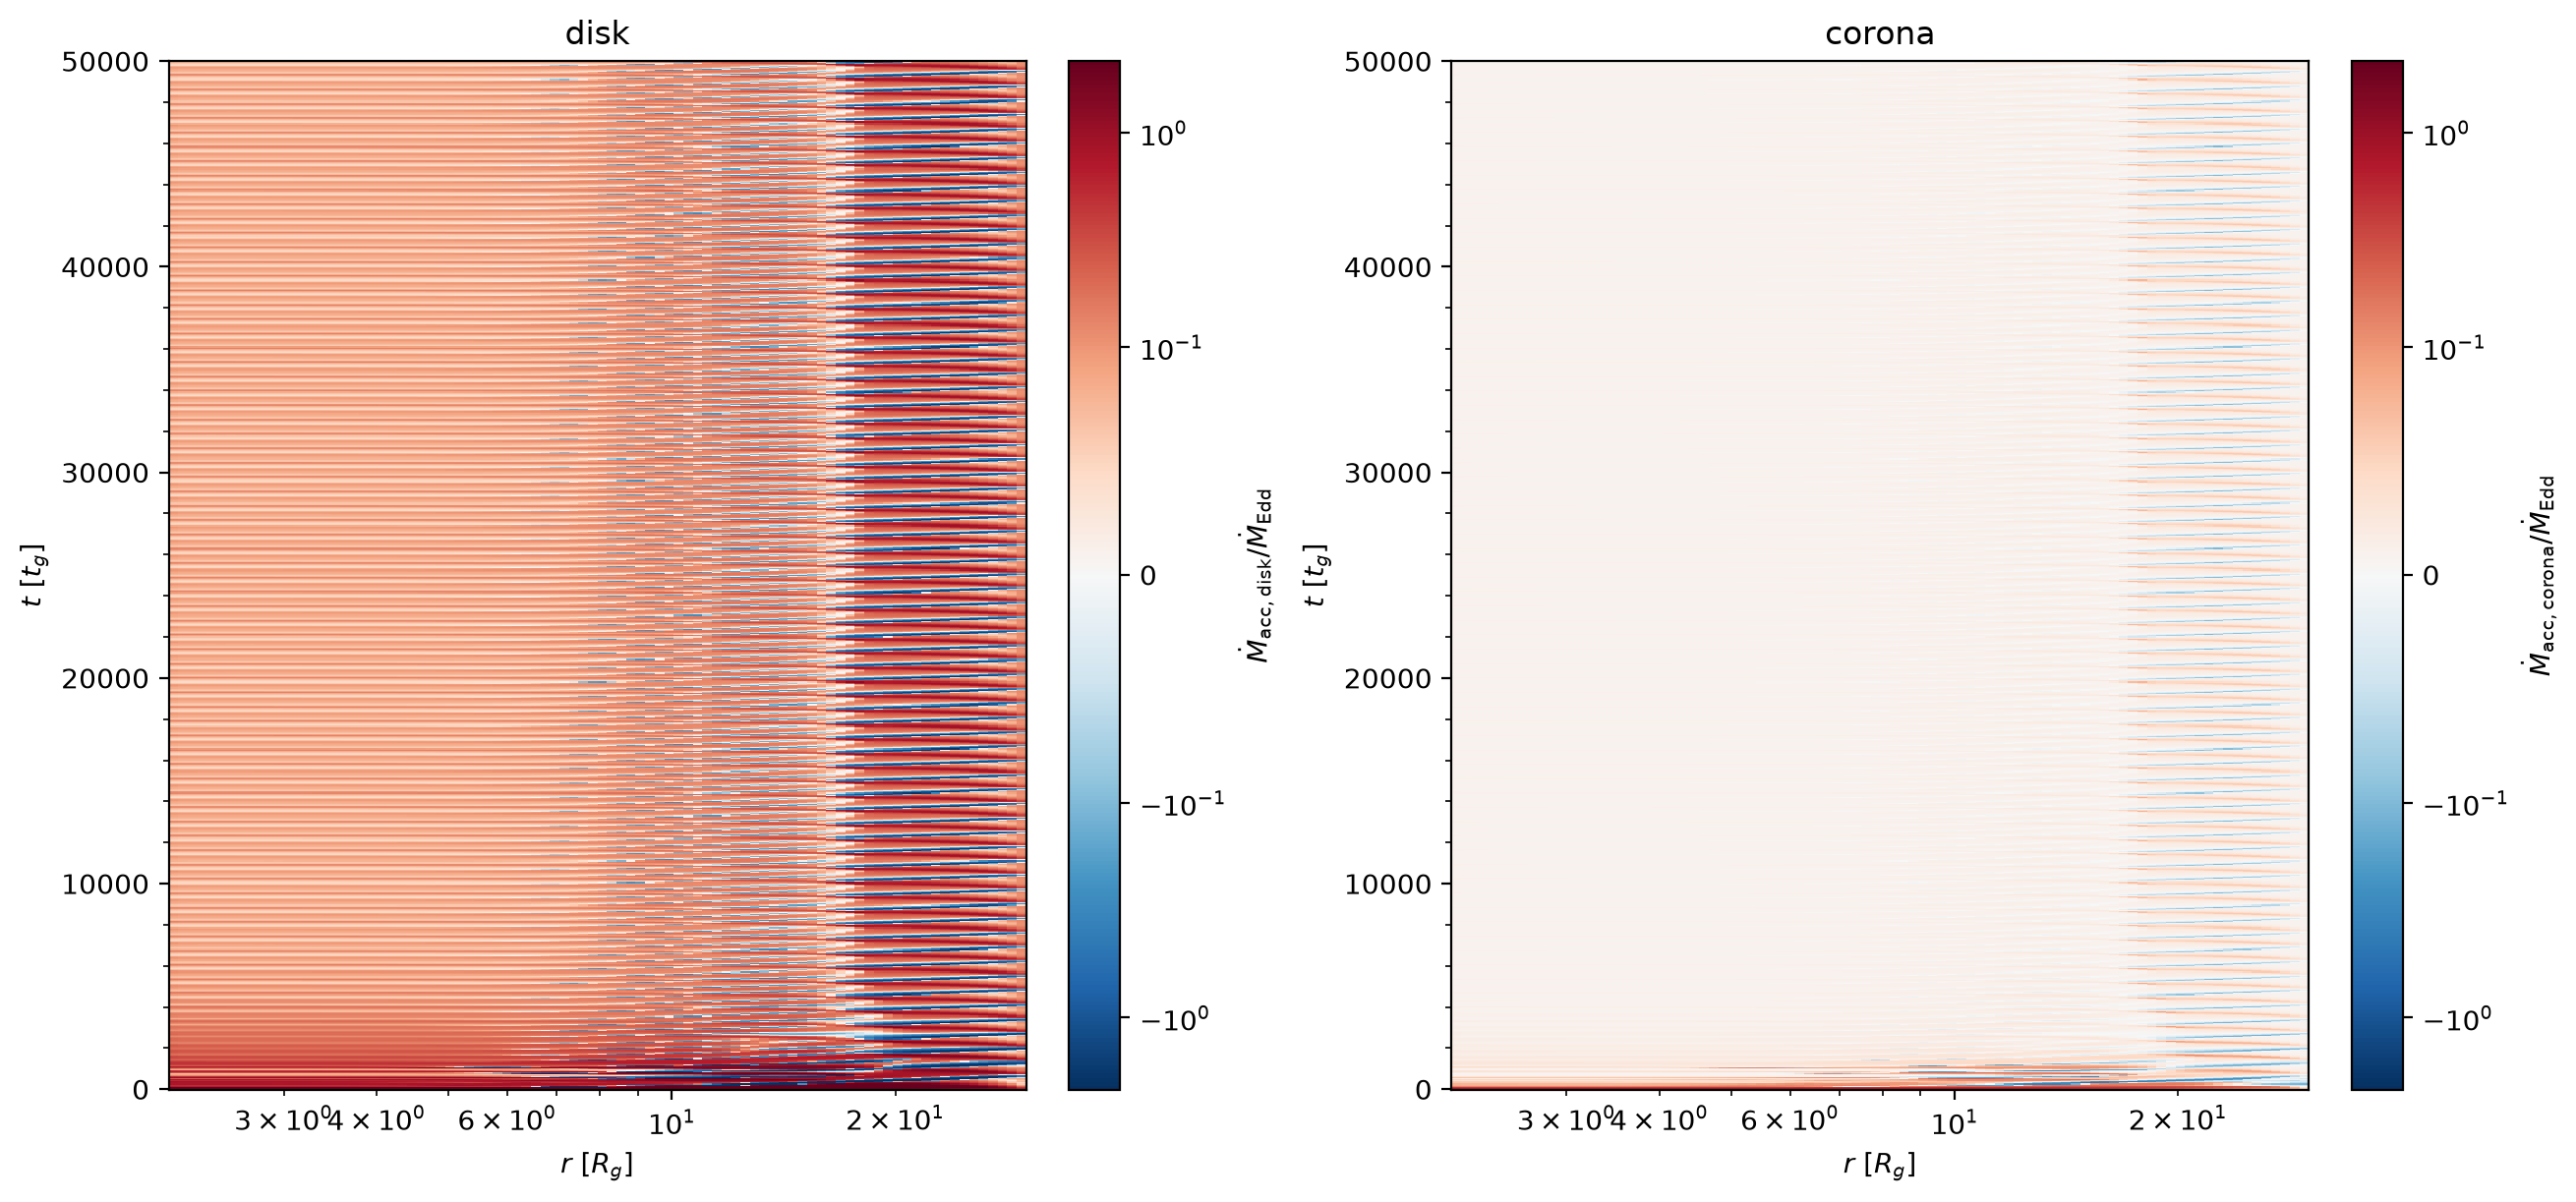

In [18]:
def spacetime(ax, data, norm, cmap, label, tlim=None):
    im = ax.pcolormesh(R_C, T, data, norm=norm, cmap=cmap, shading='nearest', rasterized=True)
    ax.set_xscale('log'); ax.set_xlabel(r'$r\ [R_g]$'); ax.set_ylabel(r'$t\ [t_g]$')
    if tlim is not None:
        ax.set_ylim(*tlim)
    plt.colorbar(im, ax=ax, label=label)

scale = MDOT0 / MDOT_EDD
lin = np.nanpercentile(np.abs(mdot_acc[SEL]) * scale, 50)
norm = SymLogNorm(linthresh=max(lin, 1e-6), vmin=-np.nanpercentile(np.abs(mdot_acc) * scale, 99.5),
                  vmax=np.nanpercentile(np.abs(mdot_acc) * scale, 99.5))
fig, axs = plt.subplots(1, 2, figsize=[13, 6])
spacetime(axs[0], -C['mdot_d'] * scale, norm, 'RdBu_r', r'$\dot M_\mathrm{acc,disk} / \dot M_\mathrm{Edd}$')
spacetime(axs[1], -C['mdot_c'] * scale, norm, 'RdBu_r', r'$\dot M_\mathrm{acc,corona} / \dot M_\mathrm{Edd}$')
axs[0].set_title('disk'); axs[1].set_title('corona')
plt.show()

#### 3.2. Mean Accretion Profile and the Steady Disk

Over the steady window the time averaged accretion rate with its block standard error should be independent of radius inside
$R_\mathrm{eq}$. A steady $\alpha$-disk with zero torque at $R_\mathrm{isco}$ then has the surface density

$$
\Sigma_\mathrm{ss}(R) = \frac{\langle\dot M_\mathrm{acc}\rangle}{3\pi\,\nu(R)}\left(1 - \sqrt{\frac{R_\mathrm{isco}}{R}}\right), \qquad R > R_\mathrm{isco},
$$

evaluated with the measured mean accretion rate at the inner boundary and the kinematic viscosity $\nu(R)$ of the model.

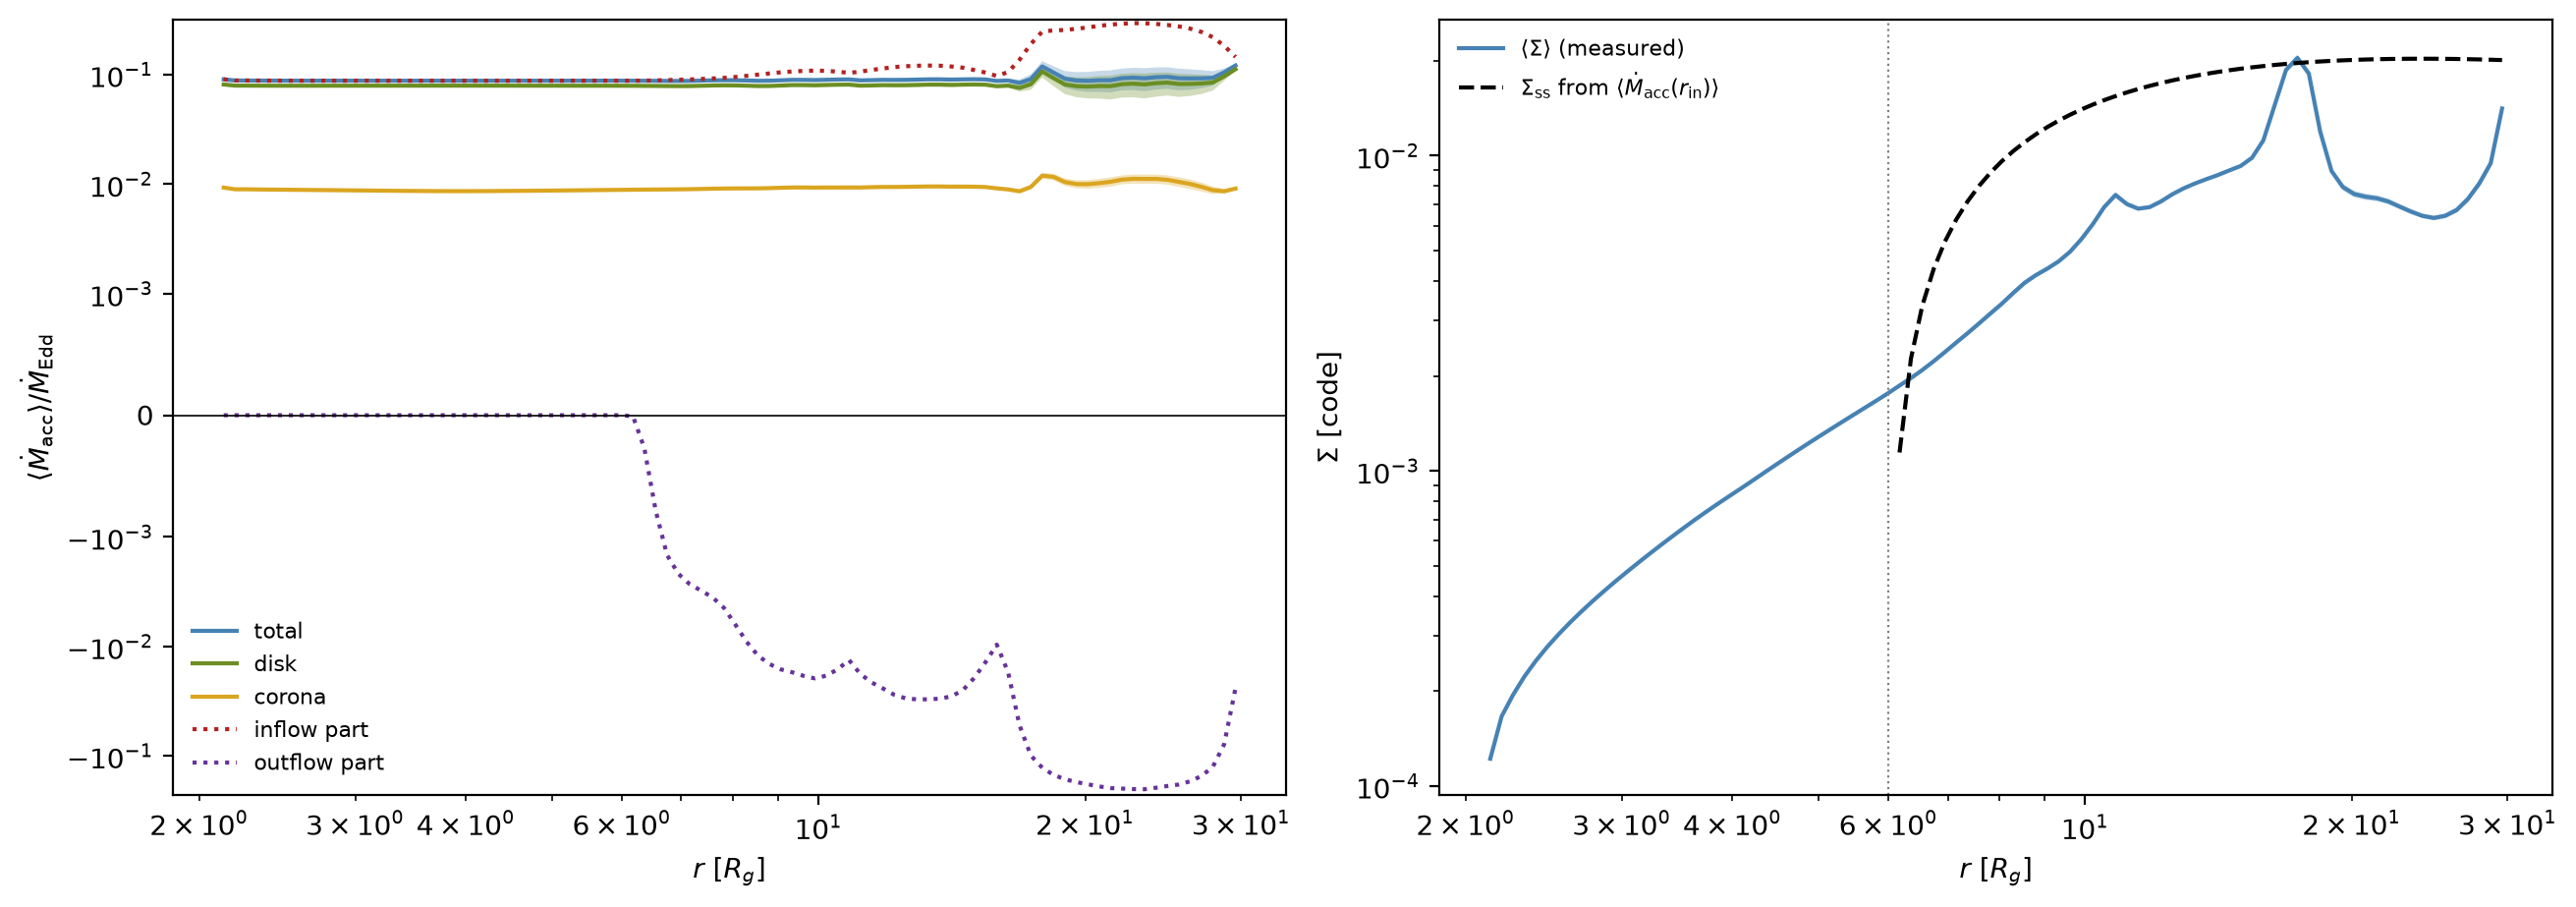

<Mdot_acc(r_in)> = 6.2503e-03 +- 3.6e-05 code = 3.7601e-01 Msun/yr = 9.0525e-02 Mdot_Edd


In [19]:
def steady_mean(X):
    # mean and block standard error over the steady window
    Xs = np.asarray(X, dtype=float)[SEL]
    nb = max(Xs.shape[0] // N_B, 2)
    nb = min(nb, Xs.shape[0])
    size = Xs.shape[0] // nb
    blocks = Xs[:nb * size].reshape((nb, size) + Xs.shape[1:]).mean(axis=1)
    return Xs.mean(axis=0), blocks.std(axis=0, ddof=1) / np.sqrt(nb)

fig, axs = plt.subplots(1, 2, figsize=[13, 4.5])
ax = axs[0]
for key, lab in [('mdot', 'total'), ('mdot_d', 'disk'), ('mdot_c', 'corona')]:
    m, e = steady_mean(-C[key] * scale)
    ax.plot(R_C, m, label=lab)
    ax.fill_between(R_C, m - e, m + e, alpha=0.3)
for key, lab in [('mdot_in', 'inflow part'), ('mdot_out', 'outflow part')]:
    m, _ = steady_mean(-C[key] * scale)
    ax.plot(R_C, m, ls=':', label=lab)
ax.axhline(0, color='k', lw=0.6)
ax.set_xscale('log'); ax.set_yscale('symlog', linthresh=1e-3)
ax.set_xlabel(r'$r\ [R_g]$'); ax.set_ylabel(r'$\langle\dot M_\mathrm{acc}\rangle / \dot M_\mathrm{Edd}$'); ax.legend(fontsize=8)

ax = axs[1]
mdot_in_mean, mdot_in_se = steady_mean(mdot_acc_in)
sig_mean, sig_se = steady_mean(C['sigma'])
R_ss = R_C[R_C > 6.0]
sigma_ss = mdot_in_mean / (3.0 * np.pi * nu_kin(R_ss)) * (1.0 - np.sqrt(6.0 / R_ss))
ax.plot(R_C, sig_mean, label=r'$\langle\Sigma\rangle$ (measured)')
ax.fill_between(R_C, sig_mean - sig_se, sig_mean + sig_se, alpha=0.3)
if mdot_in_mean > 0:
    ax.plot(R_ss, sigma_ss, 'k--', label=r'$\Sigma_\mathrm{ss}$ from $\langle\dot M_\mathrm{acc}(r_\mathrm{in})\rangle$')
ax.axvline(6.0, color='gray', lw=0.8, ls=':')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$r\ [R_g]$'); ax.set_ylabel(r'$\Sigma$ [code]'); ax.legend(fontsize=8)
plt.show()

print(f"<Mdot_acc(r_in)> = {mdot_in_mean:.4e} +- {mdot_in_se:.1e} code"
      f" = {mdot_in_mean * MDOT0 * YEAR / CONST_Msun:.4e} Msun/yr = {mdot_in_mean * scale:.4e} Mdot_Edd")

#### 3.3. Variability at the Inner Boundary

The power spectral density of the accretion rate through the inner boundary over the steady window, estimated with Welch's method
(Hann window, $50\%$ overlap, linear trend removed per segment),

$$
P(\nu_f) = \frac{2\,\Delta t}{N_\mathrm{seg}\, U}\sum_{s}\left|\sum_{k} w_k\, x_{s,k}\, e^{-2\pi i \nu_f t_k}\right|^2, \qquad U = \sum_k w_k^2 ,
$$

with frequencies in $t_g^{-1}$ and in $\mathrm{day}^{-1}$, $1\,t_g^{-1} = 86400/t_g$ per day. The Nyquist frequency of the output
cadence is $\nu_\mathrm{Ny} = 1/(2\Delta t)$.

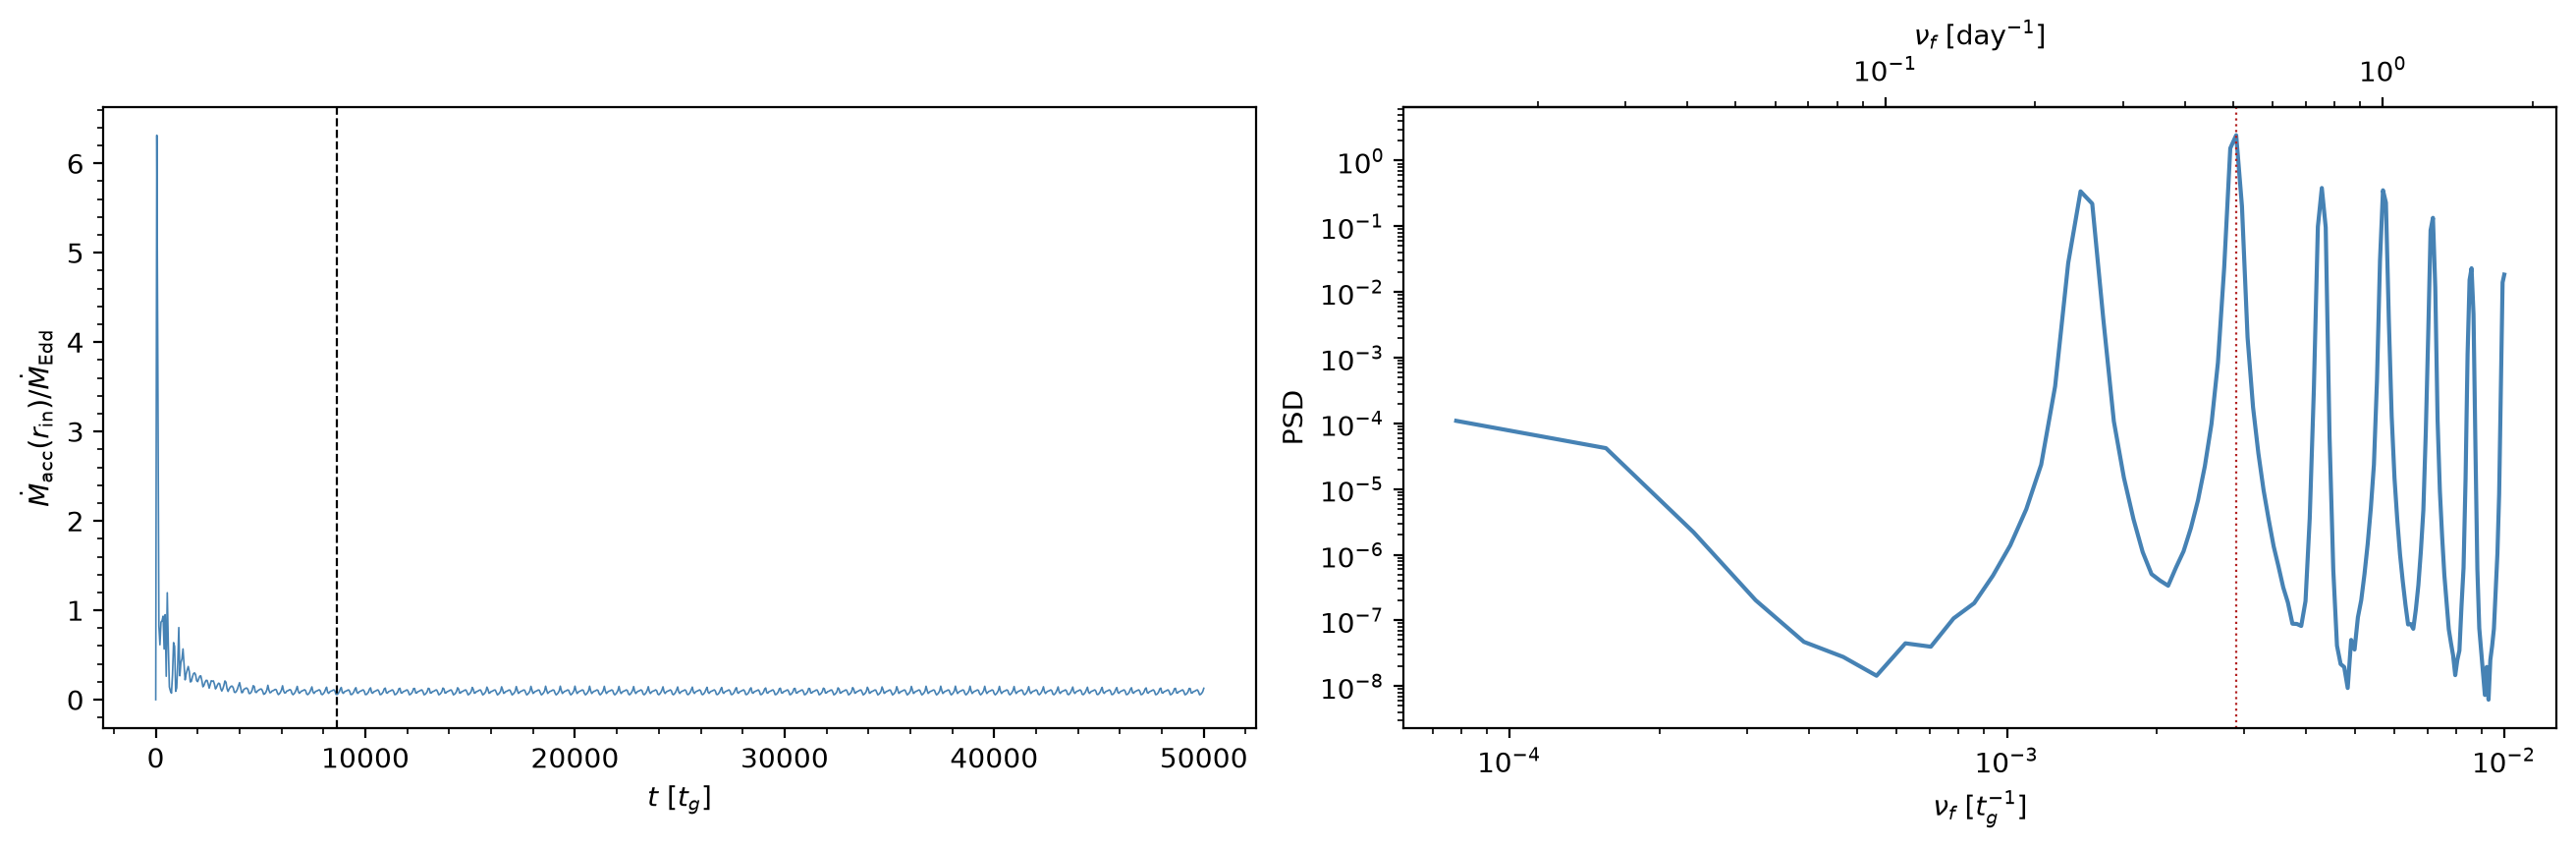

peak frequency 2.891e-03 / t_g,  period 346 t_g = 1.97 days  (Nyquist 1.000e-02 / t_g)


In [20]:
FS = 1.0 / DT_OUT
NYQ = 0.5 * FS

def welch(x, nperseg=None):
    nperseg = nperseg or min(256, x.size)
    return signal.welch(x, fs=FS, window='hann', nperseg=nperseg, detrend='linear', axis=0)

f_in, P_in = welch(mdot_acc_in[SEL] * scale)
k_peak = np.argmax(P_in[1:]) + 1

fig, axs = plt.subplots(1, 2, figsize=[13, 4.2])
axs[0].plot(T, mdot_acc_in * scale, lw=0.6)
axs[0].axvline(T_STEADY, color='k', ls='--', lw=0.8)
axs[0].set_xlabel(r'$t\ [t_g]$'); axs[0].set_ylabel(r'$\dot M_\mathrm{acc}(r_\mathrm{in}) / \dot M_\mathrm{Edd}$')

axs[1].loglog(f_in[1:], P_in[1:])
axs[1].axvline(f_in[k_peak], color='firebrick', ls=':', lw=0.8)
axs[1].set_xlabel(r'$\nu_f\ [t_g^{-1}]$'); axs[1].set_ylabel('PSD')
sec = axs[1].secondary_xaxis('top', functions=(lambda x: x * DAY / T_G, lambda x: x * T_G / DAY))
sec.set_xlabel(r'$\nu_f$ [day$^{-1}$]')
plt.show()
print(f"peak frequency {f_in[k_peak]:.3e} / t_g,  period {1 / f_in[k_peak]:.0f} t_g = {T_G / f_in[k_peak] / DAY:.2f} days  (Nyquist {NYQ:.3e} / t_g)")

#### 3.4. Mass Budget

For the mass $M_\mathrm{mid}$ between the first and the last cell centre, the same spheres on which $\dot M$ is measured,
continuity gives

$$
\frac{\mathrm{d}M_\mathrm{mid}}{\mathrm{d}t} = \dot M(r_\mathrm{in}) - \dot M(r_\mathrm{out}) + \dot M_\mathrm{floor},
$$

with $\dot M$ positive outward. Integrated in time from $t_0$,

$$
\Delta M_\mathrm{floor}(t) = \left[M_\mathrm{mid}(t) - M_\mathrm{mid}(t_0)\right] - \int_{t_0}^t \left[\dot M(r_\mathrm{in}) - \dot M(r_\mathrm{out})\right]\mathrm{d}t' .
$$

The fluxes are only sampled at the output cadence, so the integral is uncertain where they vary faster than $\Delta t$. This sampling
error is estimated as the difference between the trapezoidal and the left Riemann sum. Since the floors can only add mass, a
negative residual, or one within the sampling error, means the floor contribution is not detectable. The budget is evaluated over
the whole run and over the steady window.

whole run: Delta M_mid = -1.2844e+02,  floor residual = -1.1352e+02 +- 9.2e-02  (-75.01 % of M_mid at t0)
steady window: Delta M_mid = 8.3460e-02,  floor residual = -8.7342e+01 +- 1.2e-01  (-382.74 % of M_mid at t0)


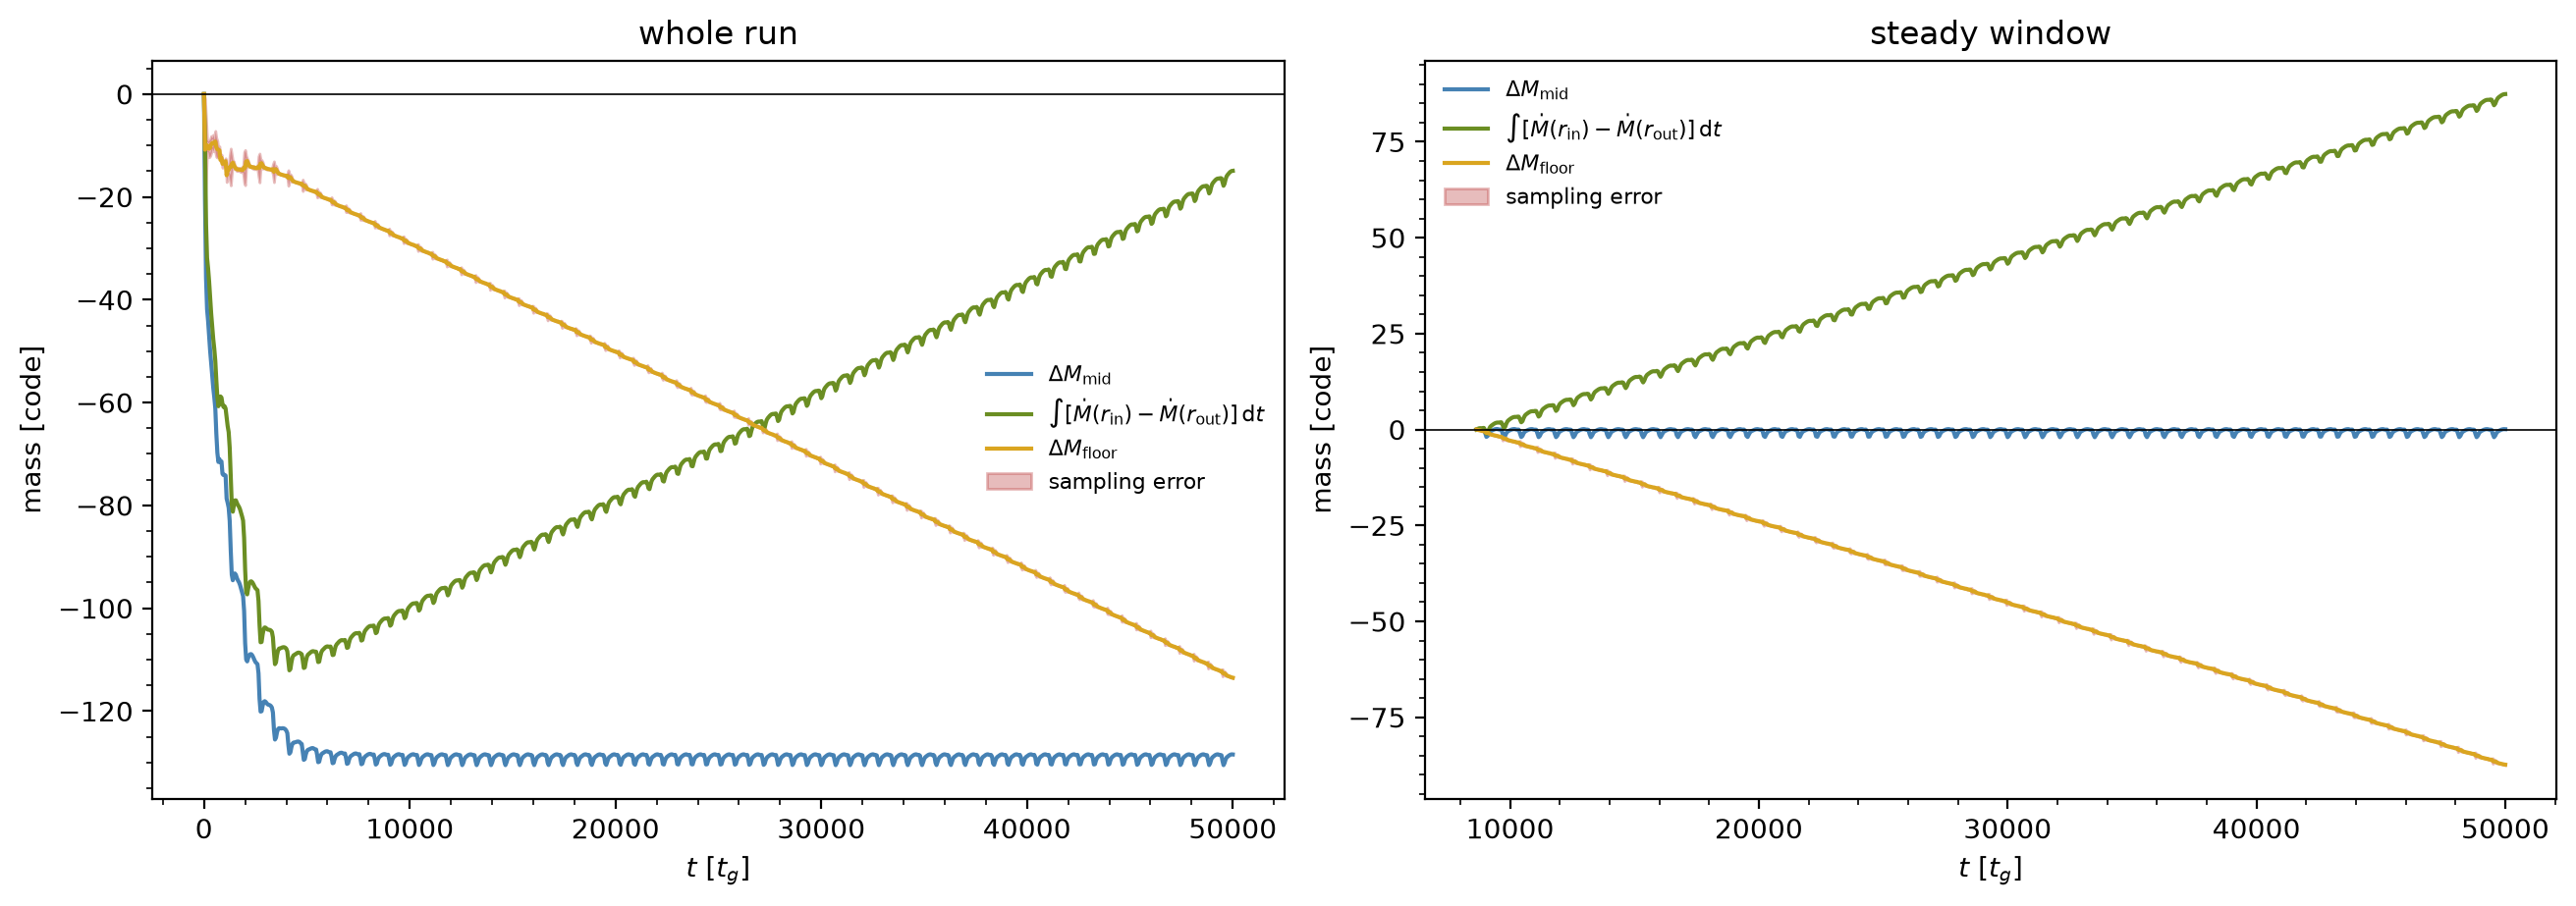

mean inflow through r_out in the steady window: 8.3643e-03 code,  through r_in: 6.2503e-03 code


In [21]:
def mass_budget(t0):
    s = T >= t0
    t = T[s]
    net = C['mdot'][s, 0] - C['mdot'][s, -1]
    trap = np.concatenate([[0.0], np.cumsum(0.5 * (net[1:] + net[:-1]) * np.diff(t))])
    left = np.concatenate([[0.0], np.cumsum(net[:-1] * np.diff(t))])
    dM = C['M_mid'][s] - C['M_mid'][s][0]
    return t, dM, trap, dM - trap, np.abs(trap - left)

fig, axs = plt.subplots(1, 2, figsize=[13, 4.5])
for ax, t0, title in [(axs[0], T[0], 'whole run'), (axs[1], T_STEADY, 'steady window')]:
    t, dM, trap, floor, err = mass_budget(t0)
    ax.plot(t, dM, label=r'$\Delta M_\mathrm{mid}$')
    ax.plot(t, trap, label=r'$\int [\dot M(r_\mathrm{in}) - \dot M(r_\mathrm{out})]\,\mathrm{d}t$')
    ax.plot(t, floor, label=r'$\Delta M_\mathrm{floor}$')
    ax.fill_between(t, floor - err, floor + err, alpha=0.3, color='firebrick', label='sampling error')
    ax.axhline(0, color='k', lw=0.6)
    ax.set_title(title); ax.set_xlabel(r'$t\ [t_g]$'); ax.set_ylabel('mass [code]'); ax.legend(fontsize=8)
    print(f"{title}: Delta M_mid = {dM[-1]:.4e},  floor residual = {floor[-1]:.4e} +- {err[-1]:.1e}  "
          f"({floor[-1] / C['M_mid'][T >= t0][0] * 100:.2f} % of M_mid at t0)")
plt.show()

FLOOR_FRAC = mass_budget(T_STEADY)[3][-1] / C['M_mid'][SEL][0]
inj = -C['mdot'][:, -1]
print(f"mean inflow through r_out in the steady window: {steady_mean(inj)[0]:.4e} code,  through r_in: {mdot_in_mean:.4e} code")

### 4. Density Waves

The quasi-steady disk carries quasi-periodic density enhancements that travel outward. All wave diagnostics use the relative
perturbation of the surface density over the steady window,

$$
\delta(r, t) = \frac{\Sigma(r,t)}{\langle\Sigma\rangle_t(r)} - 1 .
$$

The output cadence of $50\,t_g$ resolves periods above $100\,t_g$. A shorter, densely sampled restart from the steady state will
sharpen the phase speeds below.

#### 4.1. Space–Time Diagram

Outward travelling waves appear as ridges tilted towards larger $r$ with time. The right panel zooms into the last $3000\,t_g$.

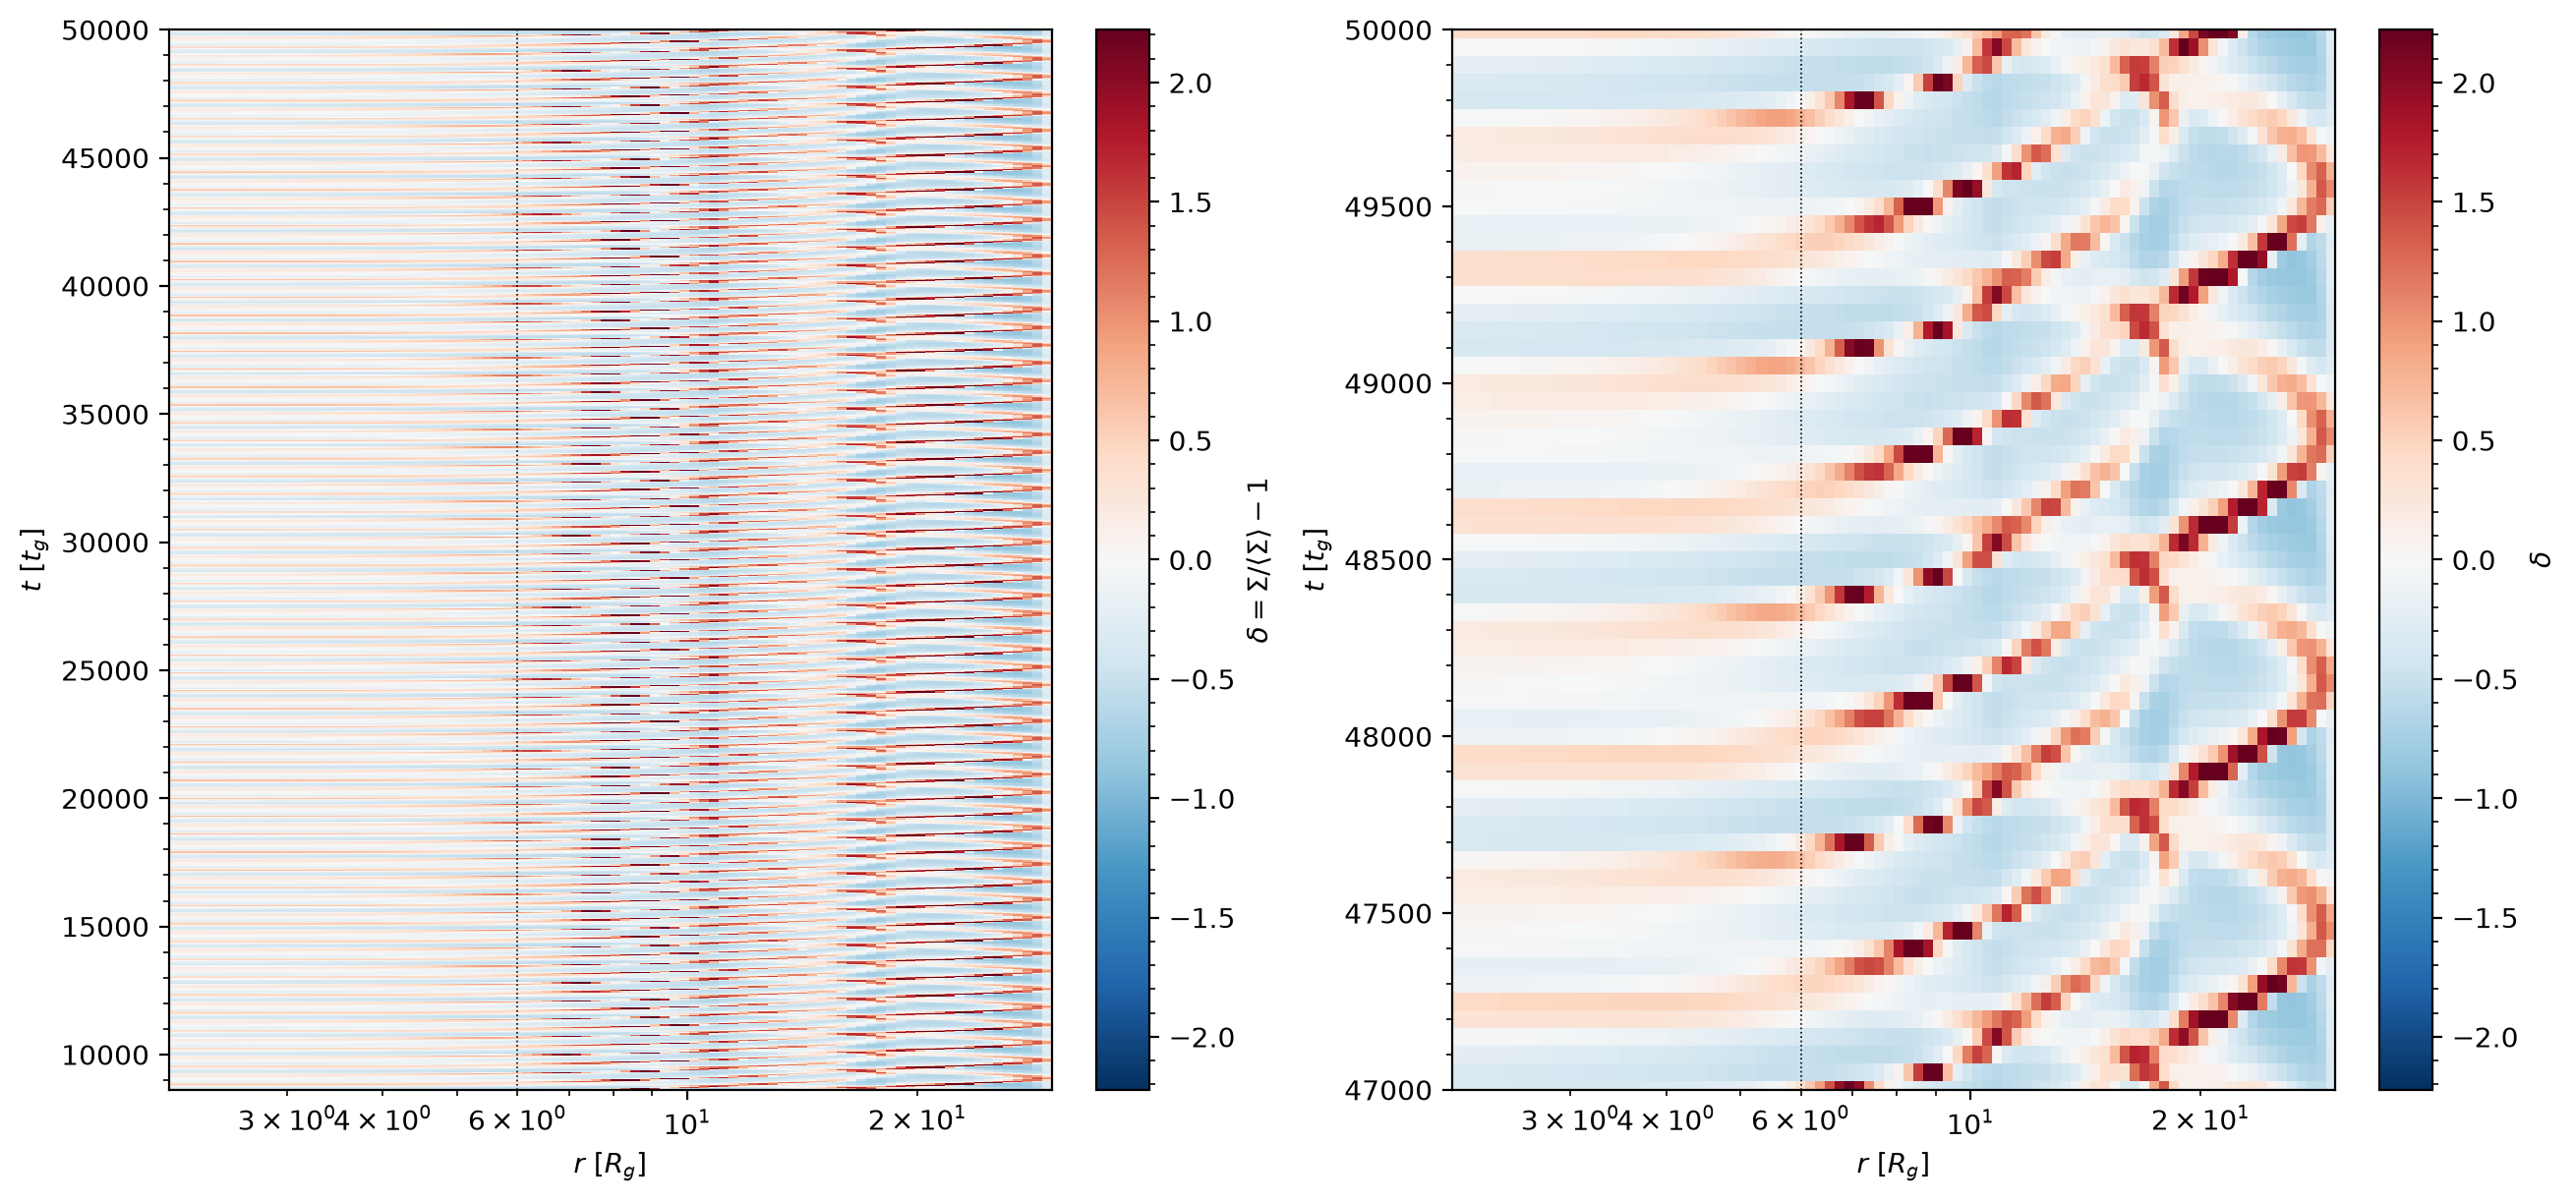

In [22]:
sig_mean_t = C['sigma'][SEL].mean(axis=0)
DELTA = C['sigma'] / sig_mean_t[None, :] - 1.0
amp = np.nanpercentile(np.abs(DELTA[SEL]), 99)
dnorm = TwoSlopeNorm(vmin=-amp, vcenter=0.0, vmax=amp)

fig, axs = plt.subplots(1, 2, figsize=[13, 6])
spacetime(axs[0], DELTA, dnorm, 'RdBu_r', r'$\delta = \Sigma / \langle\Sigma\rangle - 1$', tlim=(T_STEADY, T[-1]))
spacetime(axs[1], DELTA, dnorm, 'RdBu_r', r'$\delta$', tlim=(max(T_STEADY, T[-1] - 3000), T[-1]))
for ax in axs:
    ax.axvline(6.0, color='k', lw=0.6, ls=':')
plt.show()

#### 4.2. Frequency–Radius Diagram

The power spectrum $P(r, \nu_f)$ of $\delta(r,t)$ at every radius, with the characteristic local frequencies of the disk overlaid:
orbital $\Omega/2\pi$, epicyclic $\kappa/2\pi$, thermal $\alpha\Omega_N/2\pi$ and viscous $1/t_\nu$. A mode launched at one radius
and travelling through the disk appears at the same frequency at all radii, while locally excited oscillations follow one of the
local frequencies.

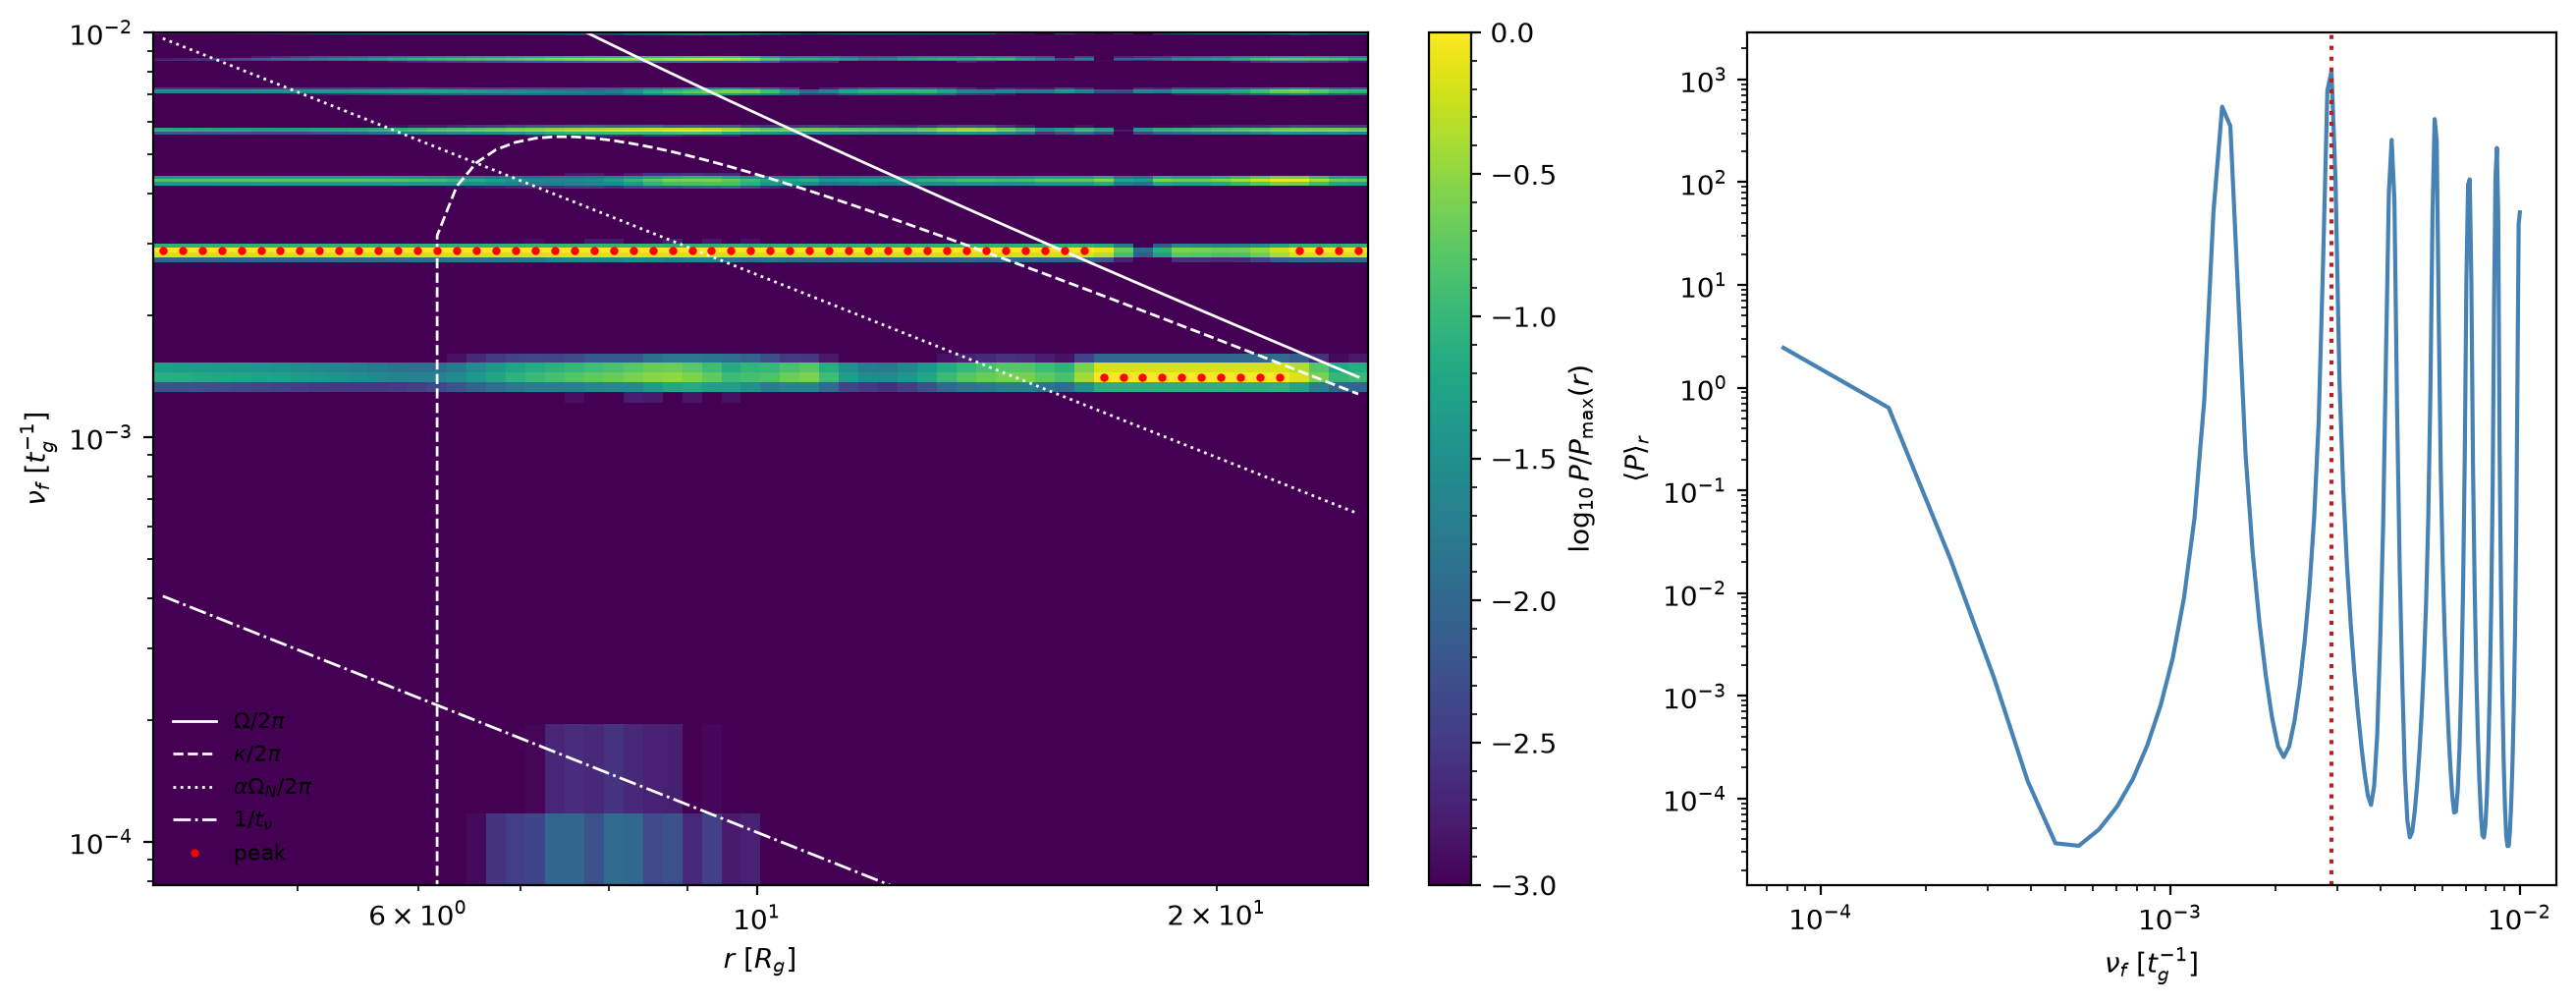

dominant frequency 2.891e-03 / t_g,  period 346 t_g = 1.97 days


In [23]:
WAVE = (R_C >= R_WAVE[0]) & (R_C <= R_WAVE[1])
f_w, P_w = welch(DELTA[SEL][:, WAVE])
P_glob = P_w[1:].mean(axis=1)
k_glob = np.argmax(P_glob) + 1
F_PEAK = f_w[k_glob]
f_peak_r = f_w[1:][np.argmax(P_w[1:], axis=0)]

fig, axs = plt.subplots(1, 2, figsize=[13, 5], gridspec_kw={'width_ratios': [3, 2]})
ax = axs[0]
im = ax.pcolormesh(R_C[WAVE], f_w[1:], np.log10(P_w[1:] / P_w[1:].max(axis=0, keepdims=True)), cmap='viridis',
                   vmin=-3, vmax=0, shading='nearest', rasterized=True)
plt.colorbar(im, ax=ax, label=r'$\log_{10} P / P_\max(r)$')
Rw = R_C[WAVE]
ax.plot(Rw, omega_pw(Rw) / (2 * np.pi), 'w-', lw=1, label=r'$\Omega/2\pi$')
ax.plot(Rw, kappa_epi(Rw) / (2 * np.pi), 'w--', lw=1, label=r'$\kappa/2\pi$')
ax.plot(Rw, ALPHA * omega_newton(Rw) / (2 * np.pi), 'w:', lw=1, label=r'$\alpha\Omega_N/2\pi$')
ax.plot(Rw, 1 / t_viscous(Rw), 'w-.', lw=1, label=r'$1/t_\nu$')
ax.plot(Rw, f_peak_r, 'r.', ms=4, label='peak')
ax.set_xscale('log'); ax.set_yscale('log'); ax.set_ylim(f_w[1], NYQ)
ax.set_xlabel(r'$r\ [R_g]$'); ax.set_ylabel(r'$\nu_f\ [t_g^{-1}]$'); ax.legend(fontsize=8, loc='lower left')

ax = axs[1]
ax.loglog(f_w[1:], P_glob)
ax.axvline(F_PEAK, color='firebrick', ls=':')
ax.set_xlabel(r'$\nu_f\ [t_g^{-1}]$'); ax.set_ylabel(r'$\langle P\rangle_r$')
plt.show()
print(f"dominant frequency {F_PEAK:.3e} / t_g,  period {1 / F_PEAK:.0f} t_g = {T_G / F_PEAK / DAY:.2f} days")

#### 4.3. Phase Speed

The phase speed follows from the cross spectral density of $\delta$ at two radii $r_1 < r_2$ at the dominant frequency
$\nu_\mathrm{peak}$. For a wave travelling outward, $\delta(r_2, t) = \delta(r_1, t - \Delta t)$, so the cross spectrum
$P_{12} = \langle \hat\delta_1^*\, \hat\delta_2 \rangle$ has the phase $\varphi_{12} = -2\pi\nu\,\Delta t$, and

$$
v_p = \frac{r_2 - r_1}{\Delta t} = -\frac{2\pi\,\nu_\mathrm{peak}\,(r_2 - r_1)}{\varphi_{12}} .
$$

Only radii with magnitude squared coherence $\gamma^2_{12} = |P_{12}|^2/(P_{11} P_{22}) \geq$ `COH_MIN` are trusted. The radial step is
small enough that $|\varphi_{12}| < \pi$. The phase speed is compared with the sound speeds of the gas–radiation mixture in the
midplane,

$$
c_\mathrm{ad}^2 = \frac{\gamma\, p + \tfrac{4}{3}\, p_r}{\rho}, \qquad c_\mathrm{iso}^2 = \frac{p + p_r}{\rho}, \qquad p_r = \frac{E_r}{3},
$$

the adiabatic one for waves faster than radiative diffusion and the isothermal one for slower waves, and with the mean radial
velocity $\langle v_r\rangle$ and the viscous speed $\nu/R$.

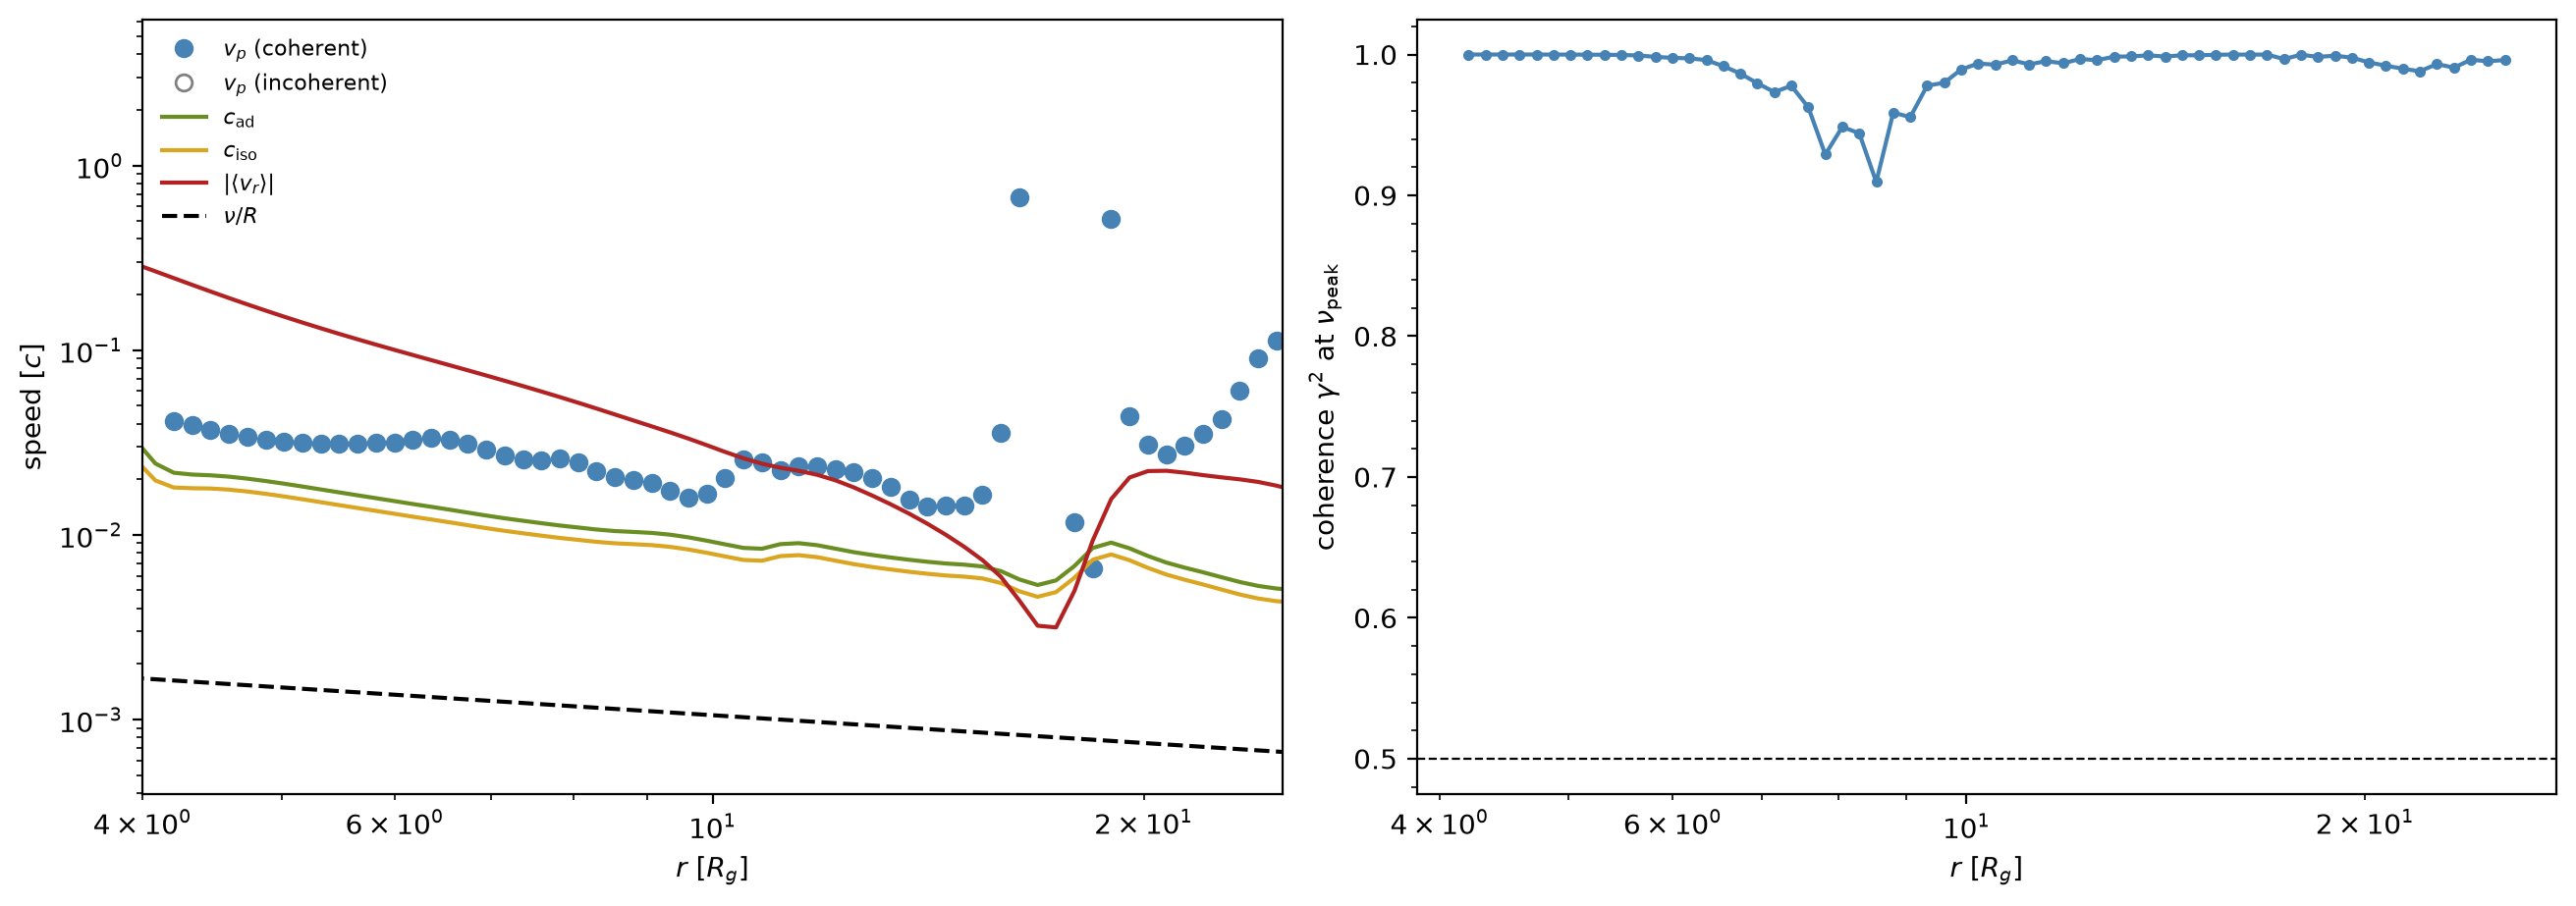

median coherent phase speed 0.0272 c,  median c_ad 0.0090 c,  median c_iso 0.0078 c


In [24]:
idx = np.nonzero(WAVE)[0]
pairs = [(i, i + WAVE_STEP) for i in idx if i + WAVE_STEP < NR]
r_mid, v_phase, coh = [], [], []
for i, j in pairs:
    x, y = DELTA[SEL][:, i], DELTA[SEL][:, j]
    nper = min(256, x.size)
    f_c, P12 = signal.csd(x, y, fs=FS, window='hann', nperseg=nper, detrend='linear')
    _, g2 = signal.coherence(x, y, fs=FS, window='hann', nperseg=nper, detrend='linear')
    k = int(np.argmin(np.abs(f_c - F_PEAK)))
    phi = np.angle(P12[k])
    r_mid.append(np.sqrt(R_C[i] * R_C[j]))
    v_phase.append(-2 * np.pi * f_c[k] * (R_C[j] - R_C[i]) / phi if phi != 0 else np.nan)
    coh.append(g2[k])
r_mid, v_phase, coh = np.array(r_mid), np.array(v_phase), np.array(coh)
good = coh >= COH_MIN

rho_m = C['rho_mid'][SEL].mean(axis=0)
prs_m = C['prs_mid'][SEL].mean(axis=0)
pr_m = C['enr_mid'][SEL].mean(axis=0) / 3.0
c_ad = np.sqrt((GAMMA * prs_m + 4.0 / 3.0 * pr_m) / rho_m)
c_iso = np.sqrt((prs_m + pr_m) / rho_m)
vr_m = C['vr_mid'][SEL].mean(axis=0)

fig, axs = plt.subplots(1, 2, figsize=[13, 4.5])
ax = axs[0]
ax.plot(r_mid[good], v_phase[good], 'o', label=r'$v_p$ (coherent)')
ax.plot(r_mid[~good], v_phase[~good], 'o', mfc='none', color='gray', label=r'$v_p$ (incoherent)')
ax.plot(R_C, c_ad, label=r'$c_\mathrm{ad}$')
ax.plot(R_C, c_iso, label=r'$c_\mathrm{iso}$')
ax.plot(R_C, np.abs(vr_m), label=r'$|\langle v_r\rangle|$')
ax.plot(R_C, nu_kin(R_C) / R_C, 'k--', label=r'$\nu/R$')
ax.set_xscale('log'); ax.set_yscale('log'); ax.set_xlim(*R_WAVE)
ax.set_xlabel(r'$r\ [R_g]$'); ax.set_ylabel(r'speed $[c]$'); ax.legend(fontsize=8)

ax = axs[1]
ax.plot(r_mid, coh, 'o-', ms=3)
ax.axhline(COH_MIN, color='k', ls='--', lw=0.8)
ax.set_xscale('log'); ax.set_xlabel(r'$r\ [R_g]$'); ax.set_ylabel(r'coherence $\gamma^2$ at $\nu_\mathrm{peak}$')
plt.show()
if good.any():
    print(f"median coherent phase speed {np.nanmedian(v_phase[good]):.4f} c,"
          f"  median c_ad {np.median(np.interp(r_mid[good], R_C, c_ad)):.4f} c,"
          f"  median c_iso {np.median(np.interp(r_mid[good], R_C, c_iso)):.4f} c")

#### 4.4. Amplitude and Wave Character

The rms amplitude $\delta_\mathrm{rms}(r) = \langle\delta^2\rangle_t^{1/2}$ shows where the waves are launched and whether they grow
or decay on the way out.

The phase between the midplane density and radial velocity perturbations at $\nu_\mathrm{peak}$ characterizes the wave. For an
outward travelling sound wave $\delta v_r / c_s = \delta\rho / \rho$, so density and velocity are in phase, $\varphi = 0$. A standing
wave or an evanescent oscillation shows $\varphi \approx \pm\pi/2$. The same is done for the radiation energy density, which for an
adiabatic, radiation dominated wave varies in phase with the density as $\delta E_r / E_r = \tfrac{4}{3}\,\delta\rho/\rho$.

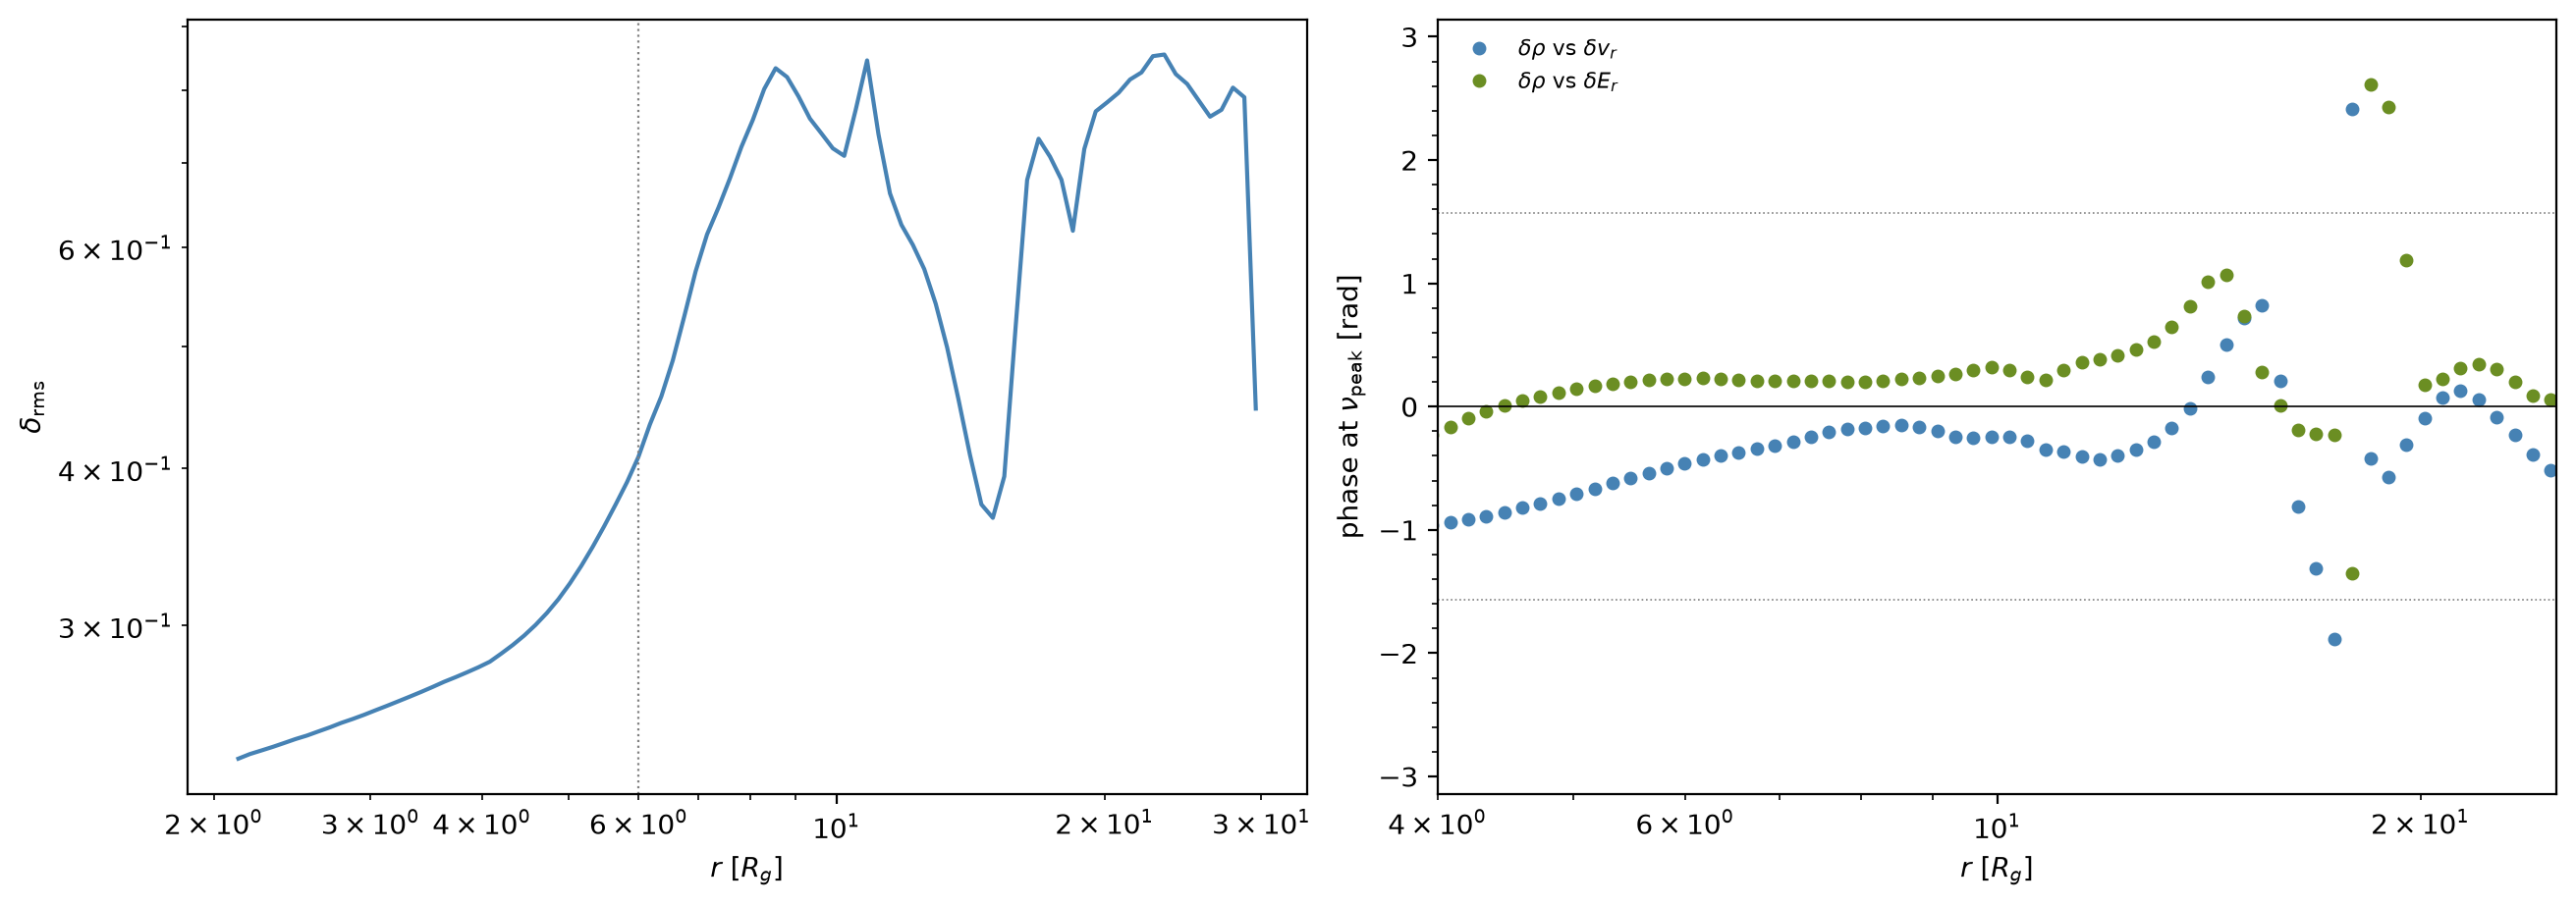

In [25]:
d_rms = np.sqrt(np.mean(DELTA[SEL]**2, axis=0))

def cross_phase(a, b):
    nper = min(256, a.shape[0])
    f_c, P = signal.csd(a, b, fs=FS, window='hann', nperseg=nper, detrend='linear', axis=0)
    _, g2 = signal.coherence(a, b, fs=FS, window='hann', nperseg=nper, detrend='linear', axis=0)
    k = int(np.argmin(np.abs(f_c - F_PEAK)))
    return np.angle(P[k]), g2[k]

drho = C['rho_mid'][SEL] / rho_m[None, :] - 1.0
dvr = C['vr_mid'][SEL] - vr_m[None, :]
dE = C['enr_mid'][SEL] / (3.0 * pr_m[None, :]) - 1.0
ph_v, g_v = cross_phase(drho, dvr)
ph_E, g_E = cross_phase(drho, dE)

fig, axs = plt.subplots(1, 2, figsize=[13, 4.5])
axs[0].plot(R_C, d_rms)
axs[0].axvline(6.0, color='gray', lw=0.8, ls=':')
axs[0].set_xscale('log'); axs[0].set_yscale('log')
axs[0].set_xlabel(r'$r\ [R_g]$'); axs[0].set_ylabel(r'$\delta_\mathrm{rms}$')

for ph, g2, lab in [(ph_v, g_v, r'$\delta\rho$ vs $\delta v_r$'), (ph_E, g_E, r'$\delta\rho$ vs $\delta E_r$')]:
    m = g2 >= COH_MIN
    axs[1].plot(R_C[m], ph[m], 'o', ms=4, label=lab)
axs[1].axhline(0, color='k', lw=0.6)
for y in [-np.pi / 2, np.pi / 2]:
    axs[1].axhline(y, color='gray', lw=0.6, ls=':')
axs[1].set_xscale('log'); axs[1].set_ylim(-np.pi, np.pi); axs[1].set_xlim(*R_WAVE)
axs[1].set_xlabel(r'$r\ [R_g]$'); axs[1].set_ylabel(r'phase at $\nu_\mathrm{peak}$ [rad]'); axs[1].legend(fontsize=8)
plt.show()

### 5. Steady State Structure

#### 5.1. Luminosity and Radiative Efficiency

The radiative luminosity through a sphere of radius $r$, with the flux in code units, $L(r) = 2\,r^2\sum_j F_{r,j}\,\Delta\Omega_j$,
is evaluated at the outer boundary and at $r = 20$. The radiative efficiency compares the mean luminosity with the mean rest mass
accretion rate through the inner boundary,

$$
\eta_\mathrm{rad} = \frac{\langle L\rangle}{\langle\dot M_\mathrm{acc}(r_\mathrm{in})\rangle\, c^2},
$$

to be compared with $\eta = 1/16$ for a disk radiating its full binding energy down to $R_\mathrm{isco}$. Radiation that is advected
into the hole or still stored in the disk lowers $\eta_\mathrm{rad}$.

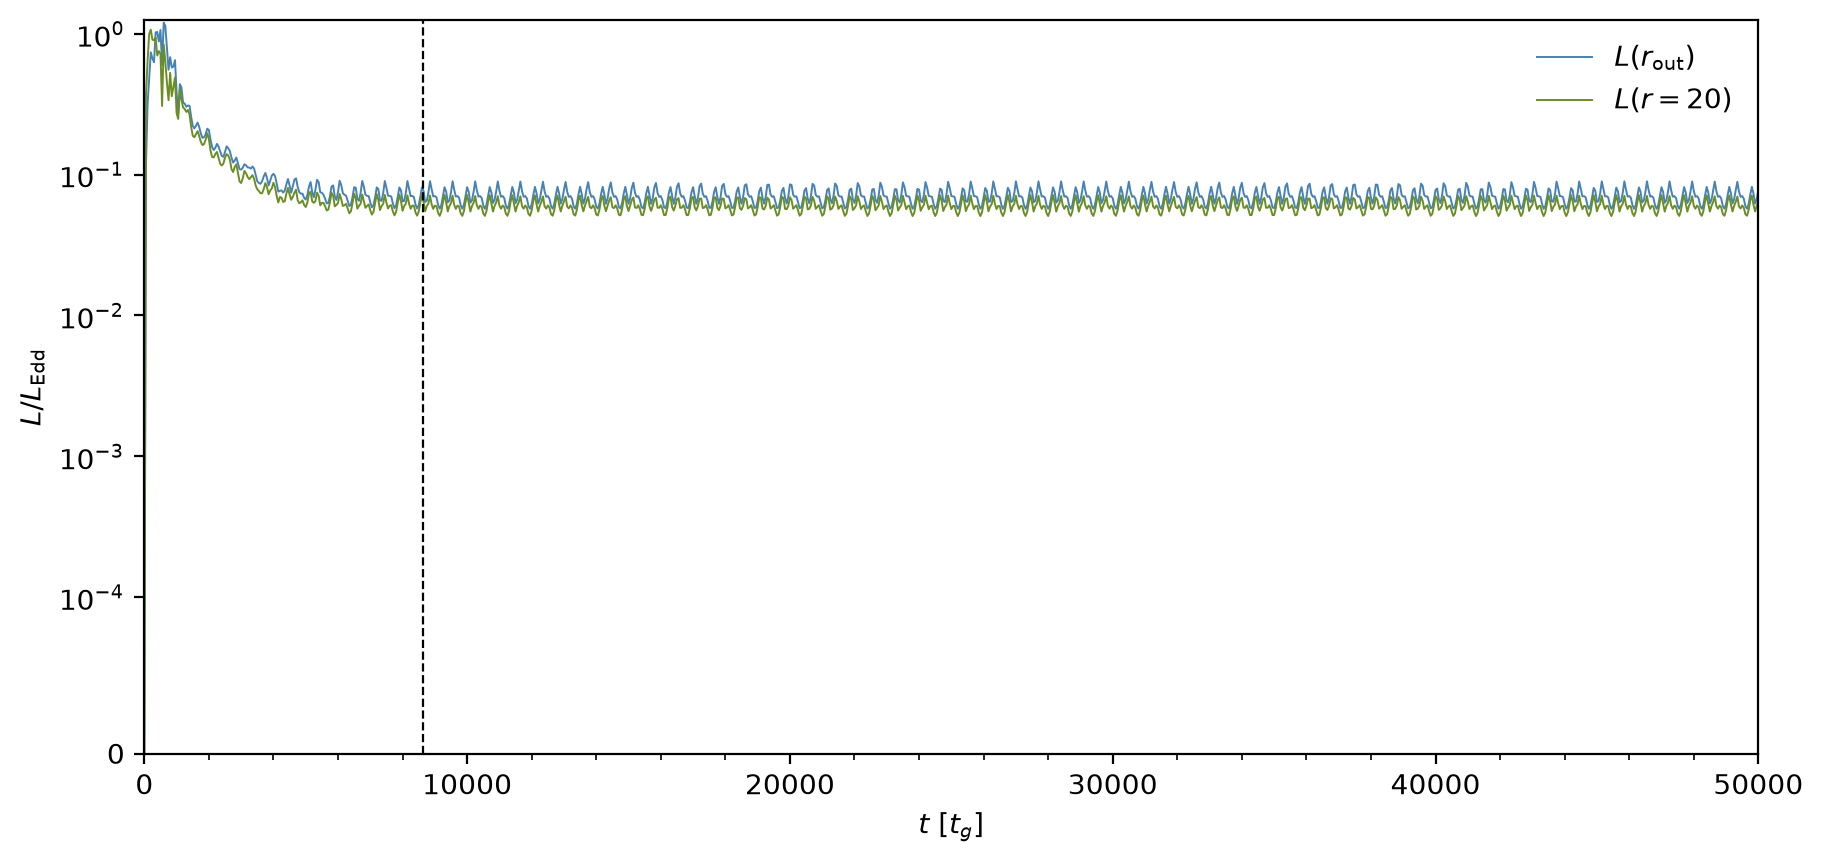

<L(r_out)> = 1.034e+45 +- 3.3e+42 erg/s = 7.030e-02 L_Edd
<L(r=20)>  = 8.836e+44 erg/s = 6.008e-02 L_Edd
radiative efficiency eta_rad = 0.0485   (eta_isco = 0.0625)


In [26]:
L_out_mean, L_out_se = steady_mean(C['L_out'])
L_20_mean, _ = steady_mean(C['L_20'])
eta_rad = L_out_mean / mdot_in_mean if mdot_in_mean > 0 else np.nan

fig, ax = plt.subplots(figsize=[9, 4.2])
ax.plot(T, C['L_out'] * L0 / L_EDD, lw=0.7, label=r'$L(r_\mathrm{out})$')
ax.plot(T, C['L_20'] * L0 / L_EDD, lw=0.7, label=r'$L(r = 20)$')
ax.axvline(T_STEADY, color='k', ls='--', lw=0.8)
ax.set_yscale('symlog', linthresh=1e-4)
ax.set_ylim(bottom=min(0.0, np.nanmin(np.r_[C['L_out'], C['L_20']]) * L0 / L_EDD))
ax.set_xlim(0, T[-1])
ax.set_xlabel(r'$t\ [t_g]$'); ax.set_ylabel(r'$L / L_\mathrm{Edd}$'); ax.legend()
plt.show()

print(f"<L(r_out)> = {L_out_mean * L0:.3e} +- {L_out_se * L0:.1e} erg/s = {L_out_mean * L0 / L_EDD:.3e} L_Edd")
print(f"<L(r=20)>  = {L_20_mean * L0:.3e} erg/s = {L_20_mean * L0 / L_EDD:.3e} L_Edd")
print(f"radiative efficiency eta_rad = {eta_rad:.4f}   (eta_isco = {ETA:.4f})")

#### 5.2. Time Averaged Fields Over the Steady Window

A second pass reloads every `PROFILE_STRIDE`-th frame of the steady window and accumulates time averages of the 2D fields, of
vertical profiles at fixed cylindrical radii, and of the column heating and cooling rates.

**Vertical force balance.** The radiation force per unit mass $\kappa F$, with $\kappa = \kappa_a + \kappa_s$ in code units, is
compared with the vertical component of gravity in the Paczyński–Wiita potential,

$$
F_z = F_r\cos\theta - F_\theta\sin\theta, \qquad g_z = \frac{\cos\theta}{(r - 2)^2}, \qquad \Gamma_z = \frac{\kappa\,F_z}{g_z},
$$

so $\Gamma_z = 1$ marks local vertical radiative support, $\Gamma_z > 1$ net upward and $\Gamma_z < 1$ net downward acceleration
when gas pressure is negligible. Profiles at fixed $R$ are interpolated linearly in $\log r$ along each ray $\theta_j$, at
$r = R/\sin\theta_j$.

**Thermal balance.** Per unit area of one disk face, the viscous heating integrated over the column and the radiative cooling through
the photosphere are

$$
Q^+(r) = \sum_j \nu_1\left(r\,\frac{\partial\Omega}{\partial r}\right)^2 r\,\Delta\theta_j, \qquad \Omega = \frac{v_\phi}{r\sin\theta}, \qquad
Q^-(r) = F_z\big|_{\tau = 1},
$$

where $r\,\partial/\partial r$ at fixed $\theta$ equals $R\,\partial/\partial R$. In thermal equilibrium $Q^+ = Q^-$. Since Thomson
scattering acts in the corona as well, the photosphere can lie above the disk surface where the corona is optically thick, and $Q^-$
is then the flux leaving the corona. The radiative
diffusion time through the disk is estimated from the mean surface density and aspect ratio,

$$
t_\mathrm{diff} = \frac{\tau_\mathrm{mid}\, H}{c}, \qquad \tau_\mathrm{mid} = \frac{\kappa_\mathrm{es}\,\langle\Sigma\rangle}{2}, \qquad H = \left\langle\frac{H}{R}\right\rangle R .
$$

In [27]:
def vertical_profile(field, R0):
    # field (NR, NTH) along the vertical line at cylindrical radius R0, as a function of z/R = cot(theta)
    r_line = R0 / np.sin(TH_C)
    inside = (r_line >= R_C[0]) & (r_line <= R_C[-1])
    out = np.full(NTH, np.nan)
    lr = np.log(R_C)
    for j in np.nonzero(inside)[0]:
        out[j] = np.interp(np.log(r_line[j]), lr, field[:, j])
    return out

def structure_fields(F):
    Tg, Tr = gas_temperature(F), rad_temperature(F)
    st, ct = np.sin(TH_C)[None, :], np.cos(TH_C)[None, :]
    Fz = F['fr1'] * ct - F['fr2'] * st
    gz = ct / (R_C[:, None] - 2.0)**2
    kap = F['kappa_abs'] + F['kappa_scat']
    gamma_z = np.where(gz > 0, kap * Fz / np.maximum(gz, 1e-300), np.nan)
    vz = F['vx1'] * ct - F['vx2'] * st
    return dict(rho=F['rho'], p_gas=F['prs'], p_rad=F['enr'] / 3.0, T_g=Tg, T_r=Tr, Gamma_z=gamma_z, f=F['diskfrac'], v_z=vz), Fz

def thermal_balance(F, Fz):
    Om = F['vx3'] / (R_C[:, None] * np.sin(TH_C)[None, :])
    shear = R_C[:, None] * np.gradient(Om, R_C, axis=0)
    q_plus = np.sum(F['nu'] * shear**2 * R_C[:, None] * DTH[None, :], axis=1)
    tau = optical_depth_from_pole(F)
    q_minus = np.full(NR, np.nan)
    for i in range(NR):
        j = np.argmax(tau[i] >= 1.0)
        if tau[i, j] >= 1.0:
            q_minus[i] = Fz[i, j]
    return q_plus, q_minus

steady_outs = OUTS[SEL][::PROFILE_STRIDE]
MEAN2D = {k: np.zeros((NR, NTH)) for k in ['rho', 'T_g', 'T_r', 'f', 'tau']}
PROF = {R0: {} for R0 in R_PROFILES}
QP, QM, NQM = np.zeros(NR), np.zeros(NR), np.zeros(NR)
n_used = 0
for n in steady_outs:
    F = load(n)
    S, Fz = structure_fields(F)
    MEAN2D['rho'] += F['rho']; MEAN2D['T_g'] += S['T_g']; MEAN2D['T_r'] += S['T_r']
    MEAN2D['f'] += F['diskfrac']; MEAN2D['tau'] += optical_depth_from_pole(F)
    for R0 in R_PROFILES:
        for key, field in S.items():
            PROF[R0][key] = PROF[R0].get(key, 0.0) + vertical_profile(field, R0)
    qp, qm = thermal_balance(F, Fz)
    QP += qp
    good_q = np.isfinite(qm)
    QM[good_q] += qm[good_q]; NQM[good_q] += 1
    n_used += 1
for key in MEAN2D:
    MEAN2D[key] /= n_used
for R0 in R_PROFILES:
    for key in PROF[R0]:
        PROF[R0][key] = PROF[R0][key] / n_used
QP /= n_used
QM = np.where(NQM > 0, QM / np.maximum(NQM, 1), np.nan)
print(f"averaged {n_used} frames between t = {T[SEL][0]:.0f} and {T[SEL][-1]:.0f}")

averaged 207 frames between t = 8650 and 50000


#### 5.3. Mean State

Time averaged density, gas temperature and $T_g/T_r$ over the steady window, with the mean disk surface $\langle f\rangle = 0.5$ in
white and the mean photosphere $\langle\tau\rangle = 1$ in dashed cyan.

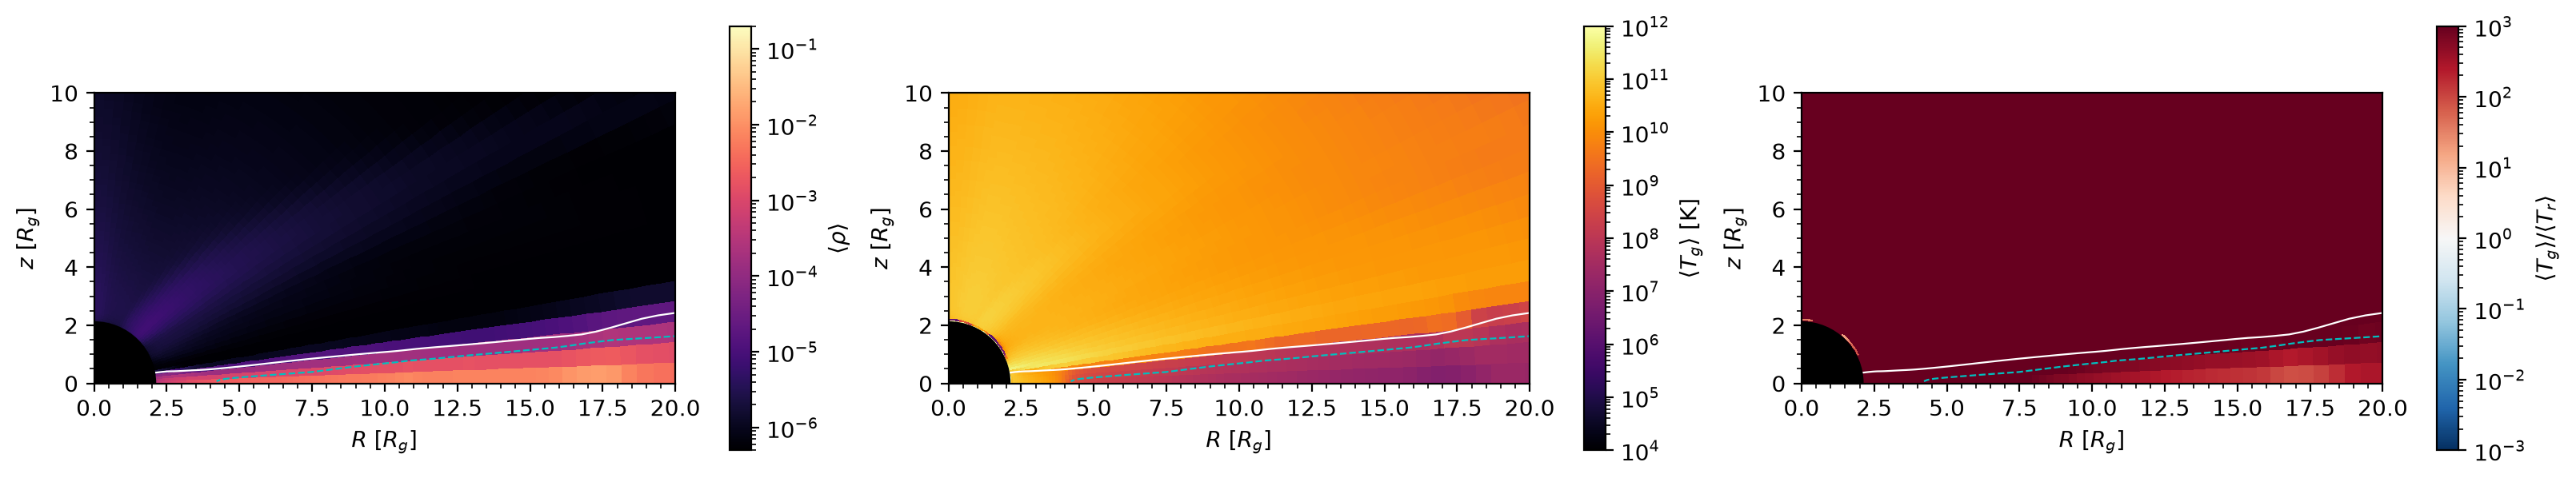

In [28]:
mean_F = dict(diskfrac=MEAN2D['f'], rho=MEAN2D['rho'], kappa_abs=np.zeros((NR, NTH)), kappa_scat=np.zeros((NR, NTH)))
Xc, Zc = centers_mesh()
fig, axs = plt.subplots(1, 3, figsize=[16, 3.4])
panels = [(MEAN2D['rho'], SNAP_NORM, 'magma', r'$\langle\rho\rangle$'),
          (MEAN2D['T_g'], LogNorm(vmin=1e4, vmax=1e12), 'inferno', r'$\langle T_g\rangle$ [K]'),
          (MEAN2D['T_g'] / np.maximum(MEAN2D['T_r'], 1.0), LogNorm(vmin=1e-3, vmax=1e3), 'RdBu_r', r'$\langle T_g\rangle / \langle T_r\rangle$')]
for ax, (data, norm, cmap, lab) in zip(axs, panels):
    im = draw_map(ax, mean_F, data, norm, cmap=cmap, contours=False)
    ax.contour(Xc, Zc, MEAN2D['f'], levels=[0.5], colors='w', linewidths=0.8)
    ax.contour(Xc, Zc, MEAN2D['tau'], levels=[1.0], colors='c', linewidths=0.8, linestyles='--')
    plt.colorbar(im, ax=ax, label=lab, shrink=0.8)
plt.show()

#### 5.4. Vertical Structure

Mean vertical profiles at the radii `R_PROFILES` against $z/R$: density, gas and radiation pressure, gas and radiation temperature,
the radiative support $\Gamma_z$ and the vertical velocity $v_z$. The dotted line marks the mean disk surface $\langle f\rangle = 0.5$.

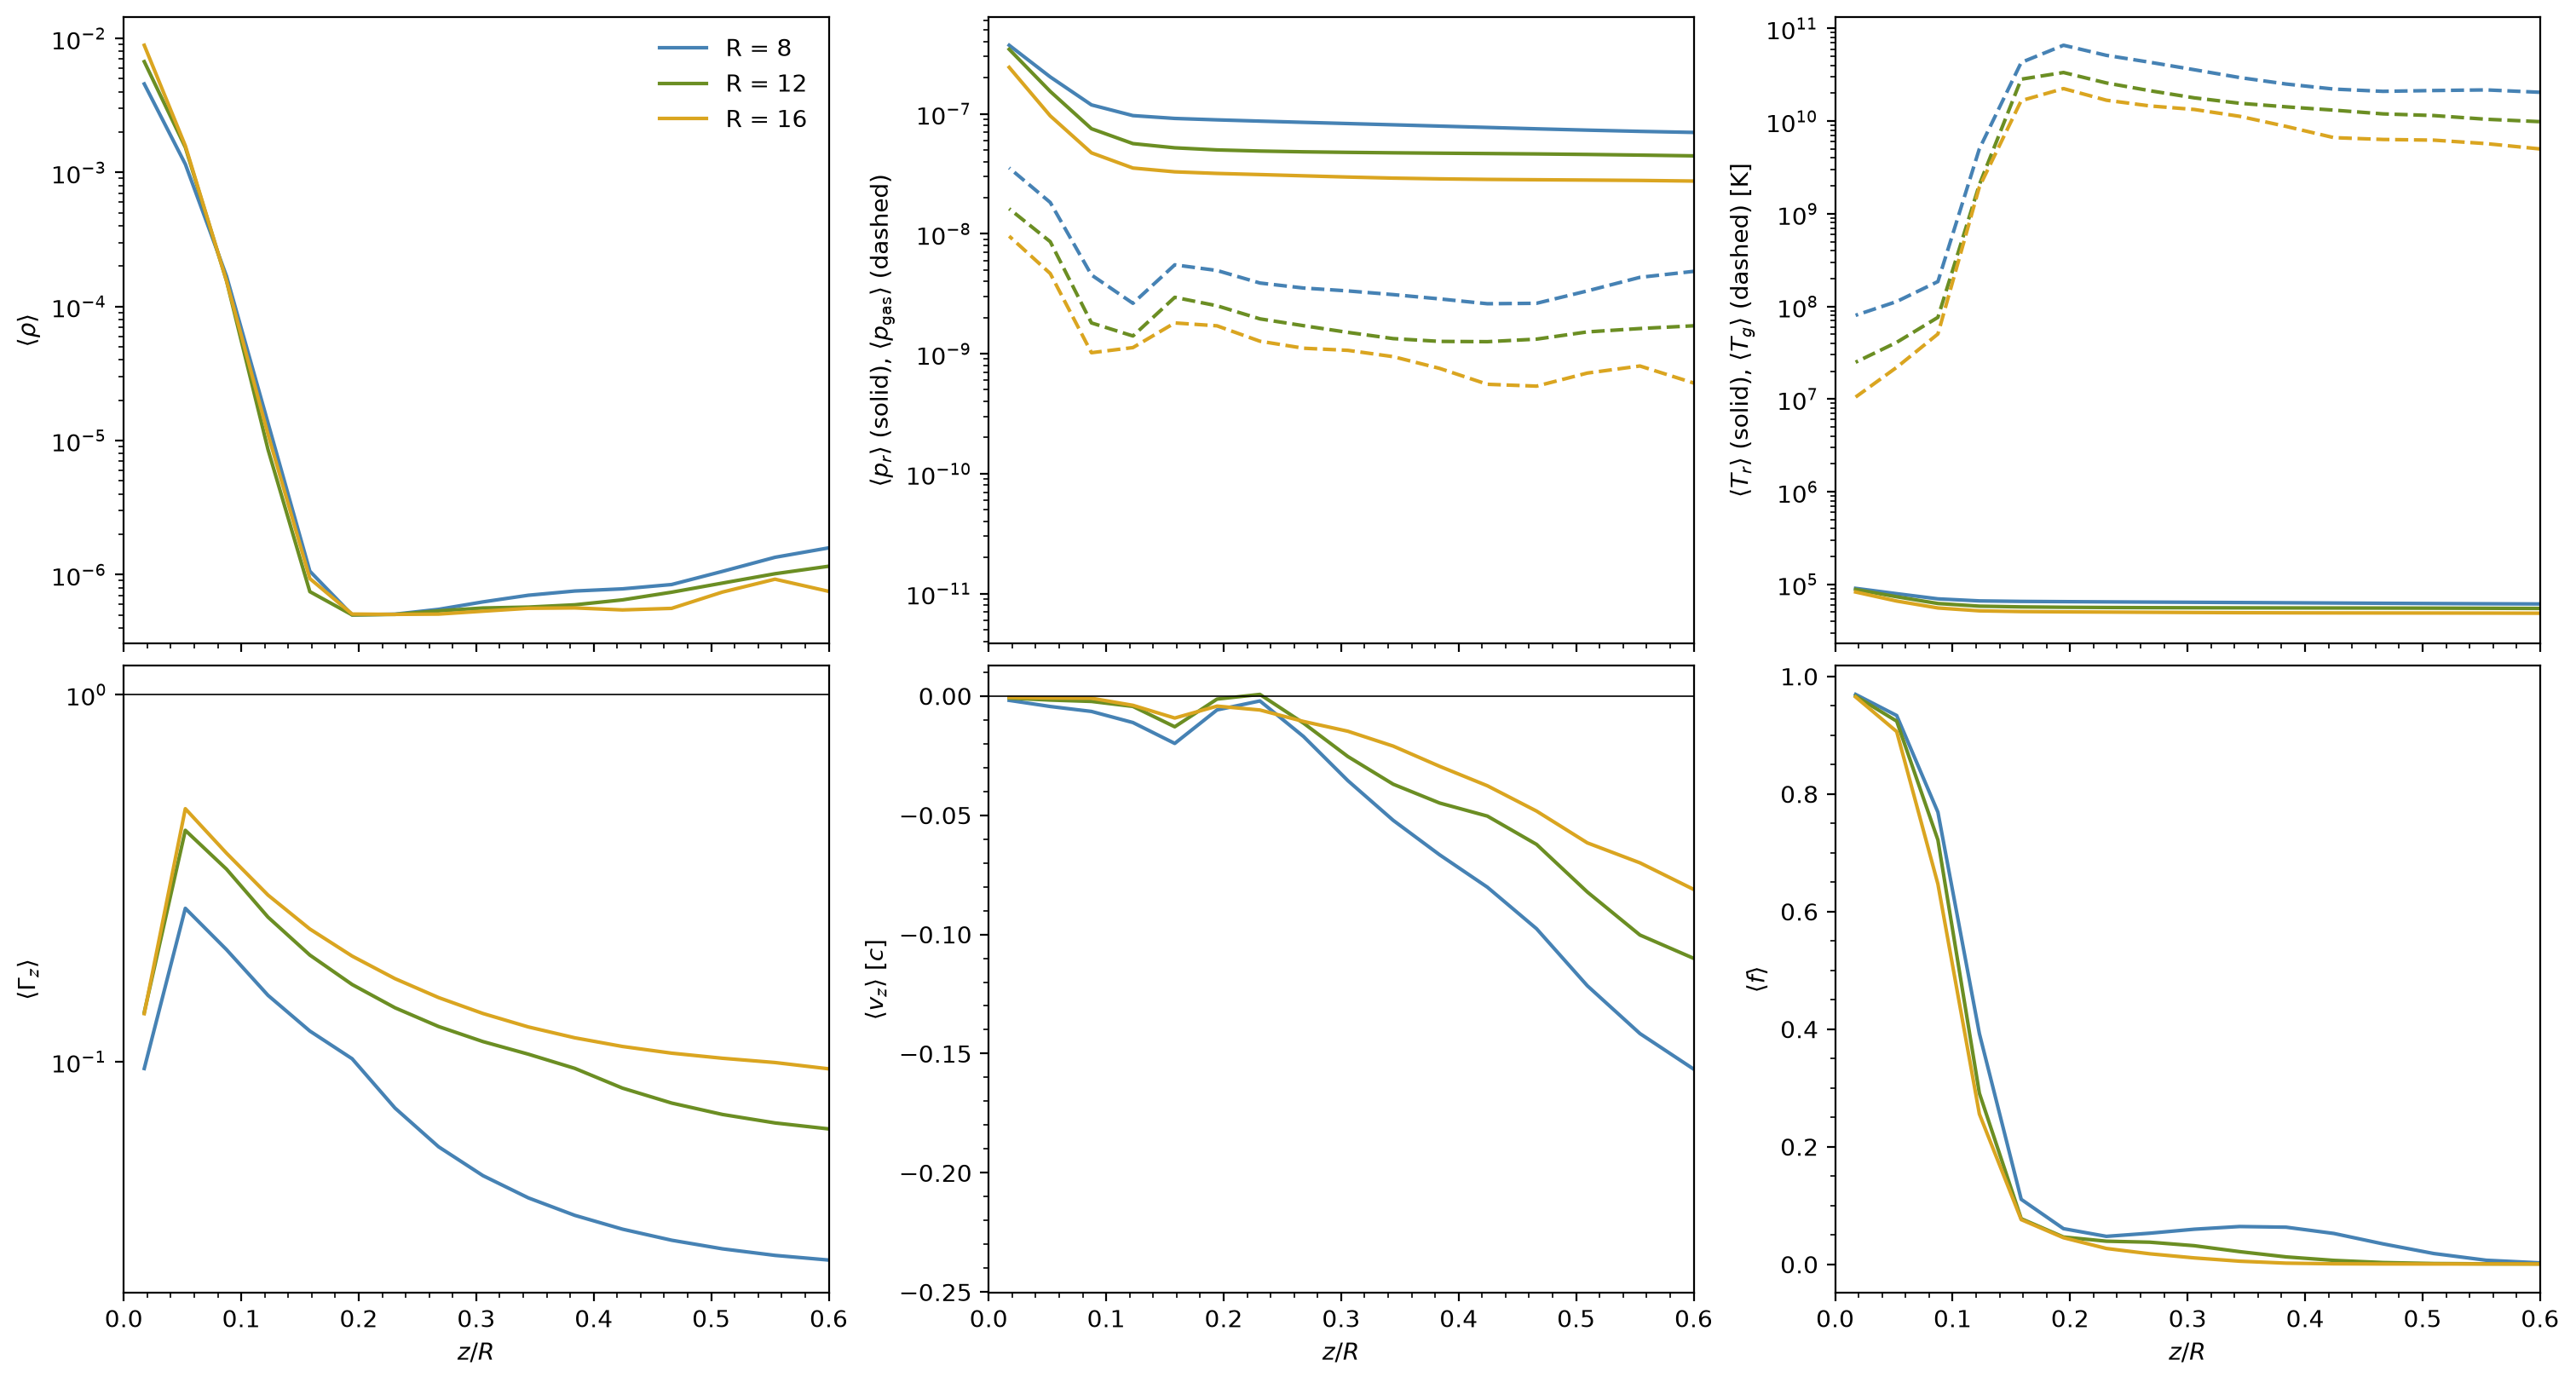

In [29]:
zr = COT
fig, axs = plt.subplots(2, 3, figsize=[15, 8], sharex=True)
for R0 in R_PROFILES:
    P = PROF[R0]
    line, = axs[0, 0].semilogy(zr, P['rho'], label=f"R = {R0:g}")
    c = line.get_color()
    axs[0, 1].semilogy(zr, P['p_rad'], color=c)
    axs[0, 1].semilogy(zr, P['p_gas'], color=c, ls='--')
    axs[0, 2].semilogy(zr, P['T_r'], color=c)
    axs[0, 2].semilogy(zr, P['T_g'], color=c, ls='--')
    axs[1, 0].plot(zr, P['Gamma_z'], color=c)
    axs[1, 1].plot(zr, P['v_z'], color=c)
    axs[1, 2].plot(zr, P['f'], color=c)
    surface = zr[np.argmin(np.abs(P['f'] - 0.5))]
    for ax in axs.flat:
        ax.axvline(surface, color=c, lw=0.6, ls=':')
axs[0, 0].set_ylabel(r'$\langle\rho\rangle$'); axs[0, 0].legend()
axs[0, 1].set_ylabel(r'$\langle p_r\rangle$ (solid), $\langle p_\mathrm{gas}\rangle$ (dashed)')
axs[0, 2].set_ylabel(r'$\langle T_r\rangle$ (solid), $\langle T_g\rangle$ (dashed) [K]')
axs[1, 0].set_ylabel(r'$\langle\Gamma_z\rangle$'); axs[1, 0].axhline(1, color='k', lw=0.6)
axs[1, 0].set_yscale('symlog', linthresh=1e-1)
axs[1, 1].set_ylabel(r'$\langle v_z\rangle\ [c]$'); axs[1, 1].axhline(0, color='k', lw=0.6)
axs[1, 2].set_ylabel(r'$\langle f\rangle$')
for ax in axs[1]:
    ax.set_xlabel(r'$z/R$')
axs[0, 0].set_xlim(0, 0.6)
plt.show()

#### 5.5. Thermal Balance, Aspect Ratio and Diffusion Time

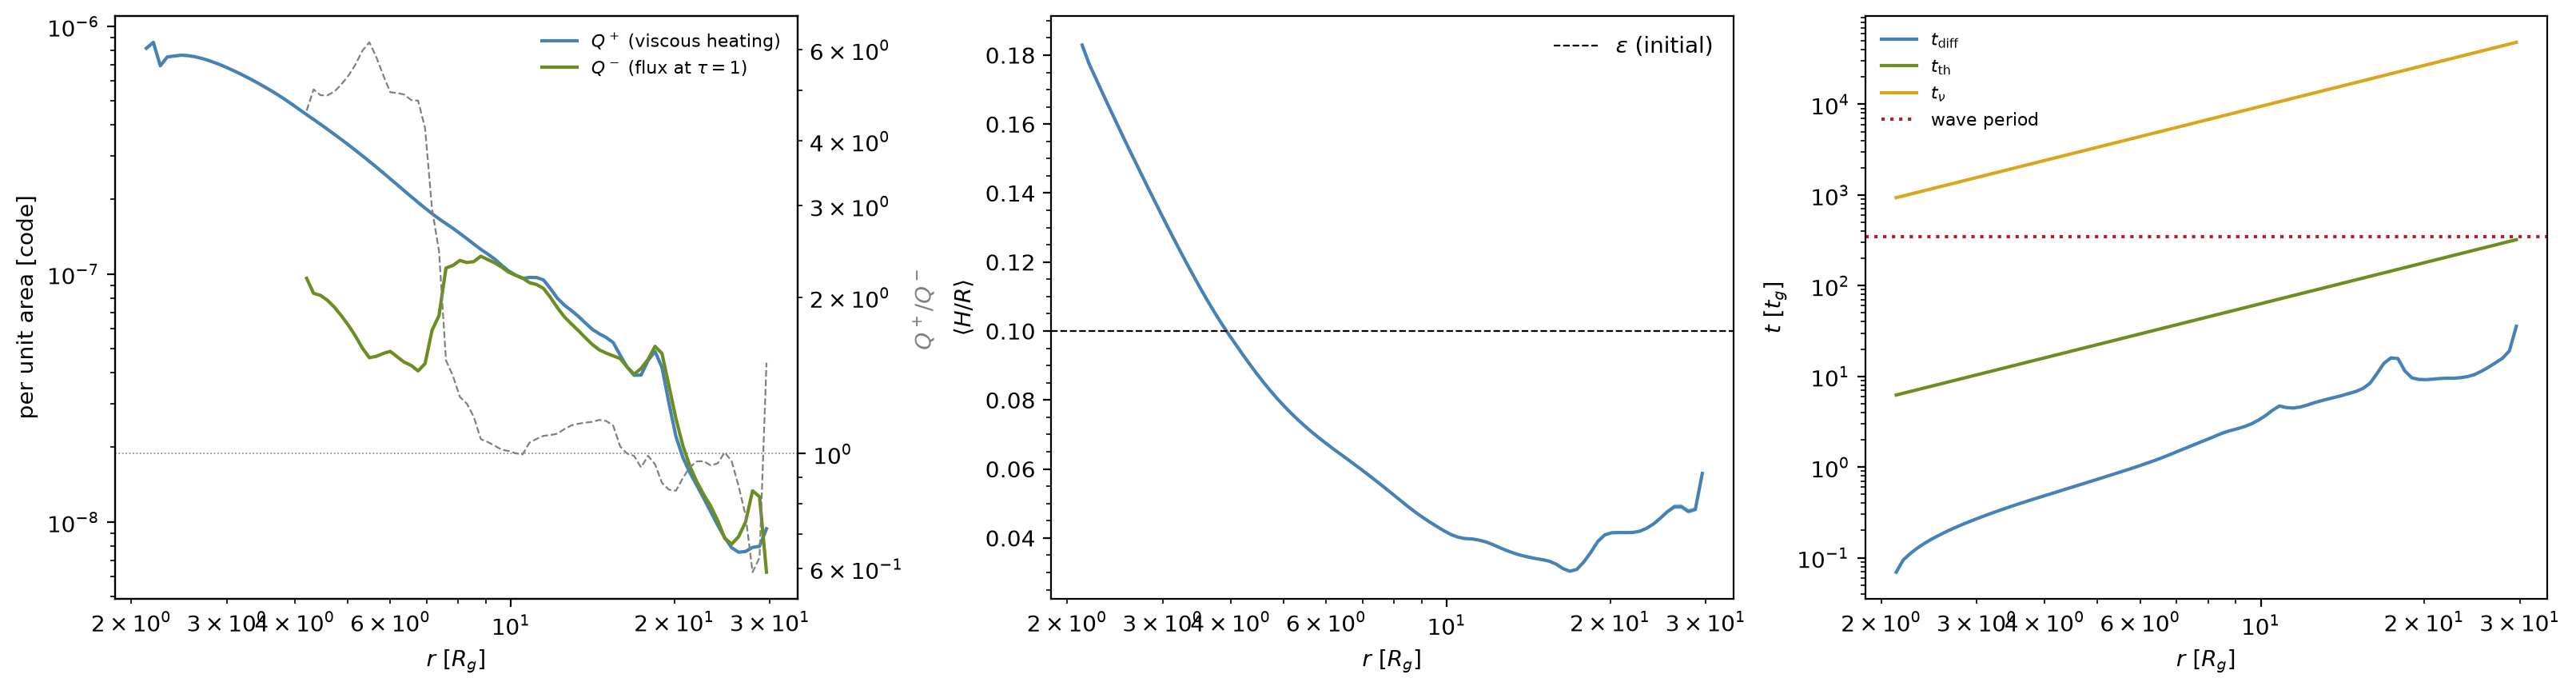

In [30]:
hr_mean, hr_se = steady_mean(C['hr'])
tau_mid = KAPPA_ES * RHO0 * R_G * sig_mean / 2.0
t_diff = tau_mid * hr_mean * R_C

fig, axs = plt.subplots(1, 3, figsize=[16, 4.2])
ax = axs[0]
ax.loglog(R_C, QP, label=r'$Q^+$ (viscous heating)')
ax.loglog(R_C, np.where(QM > 0, QM, np.nan), label=r'$Q^-$ (flux at $\tau = 1$)')
ax.set_xlabel(r'$r\ [R_g]$'); ax.set_ylabel('per unit area [code]'); ax.legend(fontsize=8)
ax2 = ax.twinx()
ax2.semilogx(R_C, QP / QM, color='gray', lw=0.8, ls='--')
ax2.axhline(1, color='gray', lw=0.6, ls=':'); ax2.set_ylabel(r'$Q^+/Q^-$', color='gray')
ax2.set_yscale('log')

ax = axs[1]
ax.plot(R_C, hr_mean)
ax.fill_between(R_C, hr_mean - hr_se, hr_mean + hr_se, alpha=0.3)
ax.axhline(EPS, color='k', ls='--', lw=0.8, label=r'$\epsilon$ (initial)')
ax.set_xscale('log'); ax.set_xlabel(r'$r\ [R_g]$'); ax.set_ylabel(r'$\langle H/R\rangle$'); ax.legend()

ax = axs[2]
ax.loglog(R_C, t_diff, label=r'$t_\mathrm{diff}$')
ax.loglog(R_C, t_thermal(R_C), label=r'$t_\mathrm{th}$')
ax.loglog(R_C, t_viscous(R_C), label=r'$t_\nu$')
if np.isfinite(F_PEAK):
    ax.axhline(1 / F_PEAK, color='firebrick', ls=':', label='wave period')
ax.set_xlabel(r'$r\ [R_g]$'); ax.set_ylabel(r'$t\ [t_g]$'); ax.legend(fontsize=8)
plt.show()

### 6. Resolution Comparison

Prepared for comparing this run with a second one, e.g. the $120 \times 90$ run. Each run first needs its own cache, created by running
this notebook once with `PATH` pointing to that run. The comparison uses the steady window $t \geq$ `t_min` of each cache and shows the
mean surface density, the mean accretion rate, the aspect ratio and the radius averaged wave spectrum.

In [31]:
def compare_runs(paths, labels, t_min, r_range=R_WAVE):
    fig, axs = plt.subplots(1, 4, figsize=[18, 4])
    for path, lab in zip(paths, labels):
        with np.load(os.path.join(path, 'Analysis_cache.npz')) as Z:
            t, r = Z['t'], Z['r']
            s = t >= t_min
            sig = Z['sigma'][s]
            axs[0].loglog(r, sig.mean(axis=0), label=lab)
            axs[1].semilogx(r, (-Z['mdot'][s]).mean(axis=0) * MDOT0 / MDOT_EDD, label=lab)
            axs[2].semilogx(r, Z['hr'][s].mean(axis=0), label=lab)
            d = sig / sig.mean(axis=0) - 1.0
            w = (r >= r_range[0]) & (r <= r_range[1])
            fs = 1.0 / np.median(np.diff(t))
            f, P = signal.welch(d[:, w], fs=fs, window='hann', nperseg=min(256, d.shape[0]), detrend='linear', axis=0)
            axs[3].loglog(f[1:], P[1:].mean(axis=1), label=lab)
    axs[0].set_ylabel(r'$\langle\Sigma\rangle$'); axs[1].set_ylabel(r'$\langle\dot M_\mathrm{acc}\rangle / \dot M_\mathrm{Edd}$')
    axs[2].set_ylabel(r'$\langle H/R\rangle$'); axs[3].set_ylabel(r'$\langle P\rangle_r$')
    for ax in axs[:3]:
        ax.set_xlabel(r'$r\ [R_g]$')
    axs[3].set_xlabel(r'$\nu_f\ [t_g^{-1}]$')
    axs[0].legend()
    plt.show()

# compare_runs(['BH_VISC_RAD_HD_TRC_COMP/', 'BH_VISC_RAD_HD_TRC_COMP_HR/'], ['90 x 45', '120 x 90'], t_min=T_STEADY)

### 7. Summary

In [32]:
period = 1.0 / F_PEAK
rows = [
    ("start of the steady window", f"{T_STEADY:.0f} t_g = {T_STEADY * T_G / DAY:.1f} days"),
    ("inflow equilibrium radius at the end", f"{R_EQ[-1]:.1f} R_g   (viscous estimate {r_viscous(T[-1]):.1f} R_g)"),
    ("mean accretion rate through r_in", f"{mdot_in_mean * MDOT0 * YEAR / CONST_Msun:.3e} Msun/yr = {mdot_in_mean * scale:.3e} Mdot_Edd"),
    ("mean luminosity through r_out", f"{L_out_mean * L0:.3e} erg/s = {L_out_mean * L0 / L_EDD:.3e} L_Edd"),
    ("radiative efficiency", f"{eta_rad:.4f}   (eta_isco = {ETA:.4f})"),
    ("dominant wave period", f"{period:.0f} t_g = {period * T_G / DAY:.2f} days"),
    ("median coherent phase speed", f"{np.nanmedian(v_phase[good]):.4f} c" if good.any() else "no coherent pairs"),
    ("floor residual in the steady window", f"{FLOOR_FRAC * 100:.2f} % of the mass between r_in and r_out"),
]
width = max(len(k) for k, _ in rows)
for k, v in rows:
    print(f"{k:<{width}}  {v}")

start of the steady window            8625 t_g = 49.2 days
inflow equilibrium radius at the end  28.7 R_g   (viscous estimate 30.3 R_g)
mean accretion rate through r_in      3.760e-01 Msun/yr = 9.052e-02 Mdot_Edd
mean luminosity through r_out         1.034e+45 erg/s = 7.030e-02 L_Edd
radiative efficiency                  0.0485   (eta_isco = 0.0625)
dominant wave period                  346 t_g = 1.97 days
median coherent phase speed           0.0272 c
floor residual in the steady window   -382.74 % of the mass between r_in and r_out
